<a href="https://colab.research.google.com/github/na00camargom/IA_Bootcamp/blob/main/Sales_Colombia_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install seaborn


[notice] A new release of pip is available: 23.3.2 -> 24.3.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
plt.style.use("dark_background")
%matplotlib inline

# from google.colab import drive
import os
import math
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

In [ ]:
# drive.mount('/content/drive')
# os.chdir('/content/drive/MyDrive/Colab Notebooks/Bootcamp - IA/Modulo 1/Competencias/Sales-Colombia-Regression/sales-colombia-regression/')
# print(os.listdir())

# 1. Data Loading

In [ ]:
# df_tr = pd.read_csv(os.path.join('sales-colombia-regression','train.csv'))
# df_tst = pd.read_csv(os.path.join('sales-colombia-regression','test.csv'))
# df_tstt = df_tst.copy()
# df_ex = pd.read_csv(os.path.join('sales-colombia-regression','example_submission.csv'))

In [ ]:
df_tr = pd.read_csv('train.csv')
df_tst = pd.read_csv('test.csv')
df_tstt = df_tst.copy()
df_ex = pd.read_csv('example_submission.csv')

In [ ]:
display(df_tr.shape)
display(df_tst.shape)
display(df_ex.shape)

(7488, 65)

(2496, 65)

(2496, 2)

In [ ]:
display(df_tr.sort_values(by='index',ascending=True).head(5))
display(df_tr.head(5))
display(df_tst.head(5))
display(df_ex.head(5))

,index,V1,CORRELA_16,CORRE_9,IDOJ1,IDAIO,CIMREP,BRUTA,CONSUI,GAS,...,INVINI,INVFIN,ROTACION,INVPRO,CTO,CTOINS,VENTASNOP,GASTOS,GASTOSNOP,GASTOPNOP
5400,0,987664,4711-472,471-472,11.0,1986.0,0.0,603028.0,112214.5,0.0,...,2409090.0,2499584.0,4837343.0,2454337.0,4837343.0,4837343.0,0,4980000.0,1110.0,5145586.0
5293,1,987666,462,462-463,14.0,1996.0,0.0,1083695.0,77336.0,780.0,...,3193.0,476400.0,4820346.0,239796.5,4820346.0,4820346.0,0,4928292.0,1255.0,5288743.0
653,2,987667,4771-4751,476 - 477,4.0,1991.0,0.0,190661.0,26863.0,0.0,...,431759.0,422759.0,515488.0,427259.0,515488.0,515488.0,0,548094.0,16772.0,701070.0
3523,5,987670,464,464-465,4.0,2005.0,0.0,2253742.0,253963.5,0.0,...,657808.0,1516713.0,7465915.0,1087260.5,7465915.0,7465915.0,0,7815028.0,548028.0,9429764.0
1920,8,987675,4759-4761,476 - 477,11.0,1991.0,0.0,1335593.0,298285.5,12323.0,...,1353480.0,1592000.0,9292366.0,1472740.0,9292366.0,9292366.0,0,9691628.0,18927.0,10117308.0


,index,V1,CORRELA_16,CORRE_9,IDOJ1,IDAIO,CIMREP,BRUTA,CONSUI,GAS,...,INVINI,INVFIN,ROTACION,INVPRO,CTO,CTOINS,VENTASNOP,GASTOS,GASTOSNOP,GASTOPNOP
0,7627,1660771,464,464-465,11.0,1981.0,0.0,2238145.0,125841.0,0.0,...,1110417.0,1155317.0,25466077.0,1132867.0,25466077.0,25466077.0,0,25721984.0,82021.0,27468490.0
1,7937,1661445,473,473,14.0,2014.0,0.0,1905867.0,634274.0,0.0,...,251053.0,170247.0,9809655.0,210650.0,9809655.0,9809655.0,0,10456929.0,6667.0,11182951.0
2,4357,1222540,465,464-465,14.0,1981.0,0.0,22093125.0,6352377.5,714.0,...,13067906.0,10850543.0,9988335.0,11959224.5,9988335.0,9988335.0,0,17001301.0,1417890.0,26369223.0
3,6336,1229296,464,464-465,4.0,2004.0,0.0,1365034.0,514460.5,0.0,...,1912369.0,2331970.0,1941959.0,2122169.5,1941959.0,1941959.0,0,2452772.0,242273.0,3143151.0
4,2350,994677,4711-472,471-472,14.0,2010.0,0.0,5403923.0,2911758.0,0.0,...,848774.0,2482444.0,23583502.0,1665609.0,23583502.0,23583502.0,0,26796715.0,447269.0,29546092.0


,Unnamed: 0,index,V1,CORRELA_16,CORRE_9,IDOJ1,IDAIO,CIMREP,BRUTA,CONSUI,...,INVINI,INVFIN,ROTACION,INVPRO,CTO,CTOINS,VENTASNOP,GASTOS,GASTOSNOP,GASTOPNOP
0,0,1333,991812,473,473,14.0,1990.0,0.0,489910.0,246745.5,...,66072.0,63424.0,3694524.0,64748.0,3694524.0,3694524.0,0,3956892.0,12836.0,4142446.0
1,1,1377,991942,466,466-469,14.0,2002.0,0.0,8440461.0,2358301.0,...,336859.0,1004246.0,10886884.0,670552.5,10886884.0,10886884.0,0,13477484.0,298682.0,17399015.0
2,2,2851,1008008,4741-4742,474 - 475,14.0,1978.0,0.0,4569572.0,809612.0,...,24130475.0,25228812.0,16350947.0,24679643.5,16350947.0,16350947.0,0,17274790.0,0.0,19297239.0
3,3,1503,992281,4773,476 - 477,14.0,2003.0,0.0,331331.0,42807.5,...,378310.0,419963.0,732671.0,399136.5,732671.0,732671.0,0,781852.0,4098.0,1013127.0
4,4,893,990651,473,473,13.0,1944.0,0.0,1487225.0,197195.0,...,333864.0,477655.0,9006654.0,405759.5,9006654.0,9006654.0,0,9226098.0,125991.0,9707030.0


,index,VENTA
0,1333,-3.443616e+08
1,1377,-9.978179e+07
2,2851,5.229781e+07
3,1503,-2.081592e+08
4,893,5.258375e+08


# 2. Data Cleaning

For what can be seen before in both the training and testing dataframes, there are some attributes that seem to not have any relevance for the "Ventas" variable in each row; the "index" column in the training set, and the "Unnamed: 0" and "index" columns in the testing set. However, some other analysis will be made in order to support this hypothesis.

However, before getting into what was just mentioned, the dataframe has to be partially cleaned in order to get rid of any nan values.

In [ ]:
df_tr.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7488 entries, 0 to 7487
Data columns (total 65 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   index        7488 non-null   int64  
 1   V1           7488 non-null   int64  
 2   CORRELA_16   7488 non-null   object 
 3   CORRE_9      7488 non-null   object 
 4   IDOJ1        7483 non-null   float64
 5   IDAIO        7486 non-null   float64
 6   CIMREP       7488 non-null   float64
 7   BRUTA        7488 non-null   float64
 8   CONSUI       7488 non-null   float64
 9   GAS          7488 non-null   float64
 10  EMPAQUE      7488 non-null   float64
 11  HONORA       7488 non-null   float64
 12  COMISION     7488 non-null   float64
 13  ARRIENDO     7488 non-null   float64
 14  SEGURO       7488 non-null   float64
 15  ASEO         7488 non-null   float64
 16  ENERGIA      7488 non-null   float64
 17  COMUNICA     7488 non-null   float64
 18  PUBLICO      7488 non-null   float64
 19  FLETES

According with what was shown before, the dataframe is almost full in the way that only a small amount of values are nans.

In [ ]:
df_tst.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2496 entries, 0 to 2495
Data columns (total 65 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Unnamed: 0   2496 non-null   int64  
 1   index        2496 non-null   int64  
 2   V1           2496 non-null   int64  
 3   CORRELA_16   2496 non-null   object 
 4   CORRE_9      2496 non-null   object 
 5   IDOJ1        2495 non-null   float64
 6   IDAIO        2495 non-null   float64
 7   CIMREP       2496 non-null   float64
 8   BRUTA        2496 non-null   float64
 9   CONSUI       2496 non-null   float64
 10  GAS          2496 non-null   float64
 11  EMPAQUE      2496 non-null   float64
 12  HONORA       2496 non-null   float64
 13  COMISION     2496 non-null   float64
 14  ARRIENDO     2496 non-null   float64
 15  SEGURO       2496 non-null   float64
 16  ASEO         2496 non-null   float64
 17  ENERGIA      2496 non-null   float64
 18  COMUNICA     2496 non-null   float64
 19  PUBLIC

## Dealing with nans

In [ ]:
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

In [ ]:
mice_imputer = IterativeImputer(random_state=42, tol=1e-5)

nn_df_tr = mice_imputer.fit_transform(df_tr.drop(columns=["CORRELA_16", "CORRE_9"]))

c:\Users\Nicolas Alejandro\.virtualenvs\Actividad_3-gy8cTQ20\Lib\site-packages\sklearn\impute\_iterative.py:825: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


In [ ]:
df_tr_nn = pd.merge(df_tr[["index","V1","CORRELA_16", "CORRE_9"]],pd.DataFrame(nn_df_tr, columns=df_tr.drop(columns=["CORRELA_16", "CORRE_9"]).columns)).drop(columns="V1")
print(df_tr_nn.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7488 entries, 0 to 7487
Data columns (total 64 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   index        7488 non-null   int64  
 1   CORRELA_16   7488 non-null   object 
 2   CORRE_9      7488 non-null   object 
 3   IDOJ1        7488 non-null   float64
 4   IDAIO        7488 non-null   float64
 5   CIMREP       7488 non-null   float64
 6   BRUTA        7488 non-null   float64
 7   CONSUI       7488 non-null   float64
 8   GAS          7488 non-null   float64
 9   EMPAQUE      7488 non-null   float64
 10  HONORA       7488 non-null   float64
 11  COMISION     7488 non-null   float64
 12  ARRIENDO     7488 non-null   float64
 13  SEGURO       7488 non-null   float64
 14  ASEO         7488 non-null   float64
 15  ENERGIA      7488 non-null   float64
 16  COMUNICA     7488 non-null   float64
 17  PUBLICO      7488 non-null   float64
 18  FLETES       7488 non-null   float64
 19  PUBLIC

In order to deal with the nan values, the MICE Imputer was used and a new dataframe was produced.

In [ ]:
df_tst.columns

Index(['Unnamed: 0', 'index', 'V1', 'CORRELA_16', 'CORRE_9', 'IDOJ1', 'IDAIO',
       'CIMREP', 'BRUTA', 'CONSUI', 'GAS', 'EMPAQUE', 'HONORA', 'COMISION',
       'ARRIENDO', 'SEGURO', 'ASEO', 'ENERGIA', 'COMUNICA', 'PUBLICO',
       'FLETES', 'PUBLICI', 'ADECUA', 'REGALA', 'OUTSOURCING', 'OTROS',
       'SUELDOS', 'PRESTAC', 'AGREGA', 'PERREMUN', 'SOCIOS', 'PERSONOM',
       'DIRECTO', 'AGENCIA', 'APRENDIZ', 'TOTPERSO', 'PROMUJ', 'PROHOM',
       'PERMUJ', 'PERHOM', 'DIRMUJ', 'DIRHOM', 'AGEMUJ', 'AGEHOM', 'APRENMUJ',
       'APRENHOM', 'TOTMUJ', 'TOTHOM', 'SUEPLAN', 'PREPLAN', 'REMPLAN',
       'COTIZA', 'GASAGEN', 'REMTEMP', 'TOTREM', 'INVINI', 'INVFIN',
       'ROTACION', 'INVPRO', 'CTO', 'CTOINS', 'VENTASNOP', 'GASTOS',
       'GASTOSNOP', 'GASTOPNOP'],
      dtype='object')

In [ ]:
df_tst_nn = mice_imputer.fit_transform(df_tst.drop(columns=["CORRELA_16", "CORRE_9", "VENTASNOP", "V1",'Unnamed: 0']))

df_tst_nn = pd.DataFrame(df_tst_nn, columns=df_tst.drop(columns=["CORRELA_16", "CORRE_9", "VENTASNOP", "V1",'Unnamed: 0']).columns)

display(df_tst_nn.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2496 entries, 0 to 2495
Data columns (total 60 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   index        2496 non-null   float64
 1   IDOJ1        2496 non-null   float64
 2   IDAIO        2496 non-null   float64
 3   CIMREP       2496 non-null   float64
 4   BRUTA        2496 non-null   float64
 5   CONSUI       2496 non-null   float64
 6   GAS          2496 non-null   float64
 7   EMPAQUE      2496 non-null   float64
 8   HONORA       2496 non-null   float64
 9   COMISION     2496 non-null   float64
 10  ARRIENDO     2496 non-null   float64
 11  SEGURO       2496 non-null   float64
 12  ASEO         2496 non-null   float64
 13  ENERGIA      2496 non-null   float64
 14  COMUNICA     2496 non-null   float64
 15  PUBLICO      2496 non-null   float64
 16  FLETES       2496 non-null   float64
 17  PUBLICI      2496 non-null   float64
 18  ADECUA       2496 non-null   float64
 19  REGALA

c:\Users\Nicolas Alejandro\.virtualenvs\Actividad_3-gy8cTQ20\Lib\site-packages\sklearn\impute\_iterative.py:825: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


None

# 3. Data Treatment and modeling

## 3.1. Prediction with no further treatment

### Model Selection

In [ ]:
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import GridSearchCV

In [ ]:
X_train_1, X_test_1, y_train_1, y_test_1 = train_test_split(df_tr_nn.drop(columns=["CORRELA_16", "CORRE_9","VENTA","VENTASNOP"]), df_tr_nn['VENTA'], test_size=0.2, random_state=42)

### SVR

In [ ]:
from sklearn.svm import SVR

In [ ]:
scaler = StandardScaler()
X_train_1_svr = scaler.fit_transform(X_train_1)
X_test_1_svr = scaler.transform(X_test_1)

In [ ]:
param_grid = {'kernel': ['linear', 'poly', 'rbf'], 'C': [0.1, 1, 10], 'gamma': ["scale", "auto"]}
grid = GridSearchCV(SVR(), param_grid, scoring='neg_mean_squared_error', refit=True, verbose=3)
grid.fit(X_train_1_svr, y_train_1)

Fitting 5 folds for each of 18 candidates, totalling 90 fits


[CV 1/5] END C=0.1, gamma=scale, kernel=linear;, score=-79179153625989568.000 total time=   4.1s
[CV 2/5] END C=0.1, gamma=scale, kernel=linear;, score=-13646485554345664.000 total time=   3.8s
[CV 3/5] END C=0.1, gamma=scale, kernel=linear;, score=-66236118396668984.000 total time=   3.5s
[CV 4/5] END C=0.1, gamma=scale, kernel=linear;, score=-51603533944513568.000 total time=   3.8s
[CV 5/5] END C=0.1, gamma=scale, kernel=linear;, score=-87268358248130528.000 total time=   3.5s
[CV 1/5] END C=0.1, gamma=scale, kernel=poly;, score=-78808643289945632.000 total time=   3.4s
[CV 2/5] END C=0.1, gamma=scale, kernel=poly;, score=-13640785784640234.000 total time=   3.6s
[CV 3/5] END C=0.1, gamma=scale, kernel=poly;, score=-66178575205997344.000 total time=   3.8s
[CV 4/5] END C=0.1, gamma=scale, kernel=poly;, score=-50787187969461448.000 total time=   2.7s
[CV 5/5] END C=0.1, gamma=scale, kernel=poly;, score=-86356487042099552.000 total time=   2.3s
[CV 1/5] END C=0.1, gamma=scale, kernel=

GridSearchCV(estimator=SVR(),
             param_grid={'C': [0.1, 1, 10], 'gamma': ['scale', 'auto'],
                         'kernel': ['linear', 'poly', 'rbf']},
             scoring='neg_mean_squared_error', verbose=3)

In [ ]:
display(grid.best_estimator_)
display(grid.best_params_)
display(grid.best_score_)

SVR(C=10, kernel='poly')

{'C': 10, 'gamma': 'scale', 'kernel': 'poly'}

np.float64(-3.998882943777611e+16)

In [ ]:
# Testing the best SVR model
svr_grid_pred = grid.best_estimator_.predict(X_test_1_svr)
mse_grid_svr_tst = mean_squared_error(y_test_1, svr_grid_pred)
print('Mean Squared Error:', mse_grid_svr_tst)

Mean Squared Error: 8.609321242868912e+16


### Polynomial

In [ ]:
from sklearn.pipeline import Pipeline

In [ ]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

In [ ]:
poly_2 = PolynomialFeatures(degree=2)
X_poly_train_2 = poly_2.fit_transform(X_train_1_svr)
X_poly_test_2 = poly_2.transform(X_test_1_svr)
pl_2 = LinearRegression()
pl_2.fit(X_poly_train_2, y_train_1)
pl_2_pred = pl_2.predict(X_poly_test_2)
mse_pl_2 = mean_squared_error(y_test_1, pl_2_pred)
mse_pl_2

np.float64(6.0111007532047655e+26)

In [ ]:
poly_3 = PolynomialFeatures(degree=3)
X_poly_train_3 = poly_3.fit_transform(X_train_1_svr)
X_poly_test_3 = poly_3.transform(X_test_1_svr)
pl_3 = LinearRegression()
pl_3.fit(X_poly_train_3, y_train_1)
pl_3_pred = pl_3.predict(X_poly_test_3)
mse_pl_3 = mean_squared_error(y_test_1, pl_3_pred)
mse_pl_3

np.float64(4.369384947493802e+20)

In [ ]:
scores_poly = {
    "Degree" : [2,3],
    "MSE Score" : [mse_pl_2,mse_pl_3]
}

display(pd.DataFrame(scores_poly))

,Degree,MSE Score
0,2,6.011101e+26
1,3,4.369385e+20


### Lasso

In [ ]:
from sklearn.linear_model import Lasso

In [ ]:
param_grid_2 = {'alpha': [3400, 3500, 3600],
                'max_iter': [4000,5000]}
grid_2 = GridSearchCV(Lasso(), param_grid_2, scoring='neg_mean_squared_error', refit=True, verbose=3)
grid_2.fit(X_train_1_svr, y_train_1)

Fitting 5 folds for each of 6 candidates, totalling 30 fits
[CV 1/5] END alpha=3400, max_iter=4000;, score=-50403791156.689 total time=   0.6s
[CV 2/5] END alpha=3400, max_iter=4000;, score=-110879463745.109 total time=   0.6s
[CV 3/5] END alpha=3400, max_iter=4000;, score=-98609067490.913 total time=   0.6s
[CV 4/5] END alpha=3400, max_iter=4000;, score=-106318845331.340 total time=   0.7s
[CV 5/5] END alpha=3400, max_iter=4000;, score=-1615206091265.976 total time=   0.7s
[CV 1/5] END alpha=3400, max_iter=5000;, score=-50403791156.689 total time=   0.5s
[CV 2/5] END alpha=3400, max_iter=5000;, score=-110879463745.109 total time=   0.8s
[CV 3/5] END alpha=3400, max_iter=5000;, score=-98609067490.913 total time=   0.8s
[CV 4/5] END alpha=3400, max_iter=5000;, score=-106318845331.340 total time=   0.7s
[CV 5/5] END alpha=3400, max_iter=5000;, score=-1615206091265.976 total time=   1.1s
[CV 1/5] END alpha=3500, max_iter=4000;, score=-46830562930.384 total time=   0.8s
[CV 2/5] END alpha=

GridSearchCV(estimator=Lasso(),
             param_grid={'alpha': [3400, 3500, 3600], 'max_iter': [4000, 5000]},
             scoring='neg_mean_squared_error', verbose=3)

In [ ]:
display(grid_2.best_estimator_)
display(grid_2.best_params_)
display(grid_2.best_score_)

Lasso(alpha=3600, max_iter=4000)

{'alpha': 3600, 'max_iter': 4000}

np.float64(-390842654332.3314)

In [ ]:
# Sub_2 = 331979708858855.00
# Testing the best Lasso model
lasso_grid_pred = grid_2.best_estimator_.predict(X_test_1_svr)
mse_grid_lasso_tst = mean_squared_error(y_test_1, lasso_grid_pred)
print('Mean Squared Error:', mse_grid_lasso_tst)

Mean Squared Error: 1210358243875.2273


In [ ]:
# Sub_3 = 296429236516098.00
ls_mdl = Lasso(alpha=10, max_iter=2000)
ls_mdl.fit(X_train_1_svr, y_train_1)
ls_mdl_pred = ls_mdl.predict(X_test_1_svr)
mse_lasso_tst = mean_squared_error(y_test_1, ls_mdl_pred)
print('Mean Squared Error:', mse_lasso_tst)

Mean Squared Error: 1309897464855.1067


In [ ]:
min(1217059200666.9841,1413565148271.6824)

1217059200666.9841

In [ ]:
# Sub_4 = 293684182623505.00
ls_mdl_2 = Lasso(alpha=10, max_iter=4000)
ls_mdl_2.fit(X_train_1_svr, y_train_1)
ls_mdl_pred = ls_mdl_2.predict(X_test_1_svr)
mse_lasso_tst = mean_squared_error(y_test_1, ls_mdl_pred)
print('Mean Squared Error:', mse_lasso_tst)

Mean Squared Error: 1253701495575.133


In [ ]:
# Sub_5 = 291160235497713.00
ls_mdl_3 = Lasso(alpha=1, max_iter=4000)
ls_mdl_3.fit(X_train_1_svr, y_train_1)
ls_mdl_pred = ls_mdl_3.predict(X_test_1_svr)
mse_lasso_tst = mean_squared_error(y_test_1, ls_mdl_pred)
print('Mean Squared Error:', mse_lasso_tst)

Mean Squared Error: 1253837259487.679


In [ ]:
# Sub_6 = 290977482739878.00
ls_mdl_4 = Lasso(alpha=0.1, max_iter=4000)
ls_mdl_4.fit(X_train_1_svr, y_train_1)
ls_mdl_pred = ls_mdl_4.predict(X_test_1_svr)
mse_lasso_tst = mean_squared_error(y_test_1, ls_mdl_pred)
print('Mean Squared Error:', mse_lasso_tst)

Mean Squared Error: 1253851307118.121


In [ ]:
# Sub_7 = 290967085893994.00
ls_mdl_5 = Lasso(alpha=0.01, max_iter=4000)
ls_mdl_5.fit(X_train_1_svr, y_train_1)
ls_mdl_pred = ls_mdl_5.predict(X_test_1_svr)
mse_lasso_tst = mean_squared_error(y_test_1, ls_mdl_pred)
print('Mean Squared Error:', mse_lasso_tst)

Mean Squared Error: 1253852718348.8506


--> The change is not as great as before

In [ ]:
# Sub_8 = 290967085893994.00
ls_mdl_6 = Lasso(alpha=0.01, max_iter=10000)
ls_mdl_6.fit(X_train_1_svr, y_train_1)
ls_mdl_pred = ls_mdl_6.predict(X_test_1_svr)
mse_lasso_tst = mean_squared_error(y_test_1, ls_mdl_pred)
print('Mean Squared Error:', mse_lasso_tst)

Mean Squared Error: 1253852718348.8506


--> There is not a significant difference modifying the limit of iterations.

In [ ]:
# Sub_9 = 3095148918480050.00
ls_mdl_7 = Lasso(alpha=0.01, max_iter=4000, fit_intercept=False)
ls_mdl_7.fit(X_train_1_svr, y_train_1)
ls_mdl_pred = ls_mdl_7.predict(X_test_1_svr)
mse_lasso_tst = mean_squared_error(y_test_1, ls_mdl_pred)
print('Mean Squared Error:', mse_lasso_tst)

Mean Squared Error: 2255156215917745.5


c:\Users\Nicolas Alejandro\.virtualenvs\Actividad_3-gy8cTQ20\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:697: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 6.745e+18, tolerance: 3.624e+16
  model = cd_fast.enet_coordinate_descent(


--> Modifying the fit_intercept parameter does not help to get a better score.

In [ ]:
# Sub_10 = 290967085871700.00
ls_mdl_8 = Lasso(alpha=0.01, max_iter=4000, precompute=True)
ls_mdl_8.fit(X_train_1_svr, y_train_1)
ls_mdl_pred = ls_mdl_8.predict(X_test_1_svr)
mse_lasso_tst = mean_squared_error(y_test_1, ls_mdl_pred)
print('Mean Squared Error:', mse_lasso_tst)

Mean Squared Error: 1253852718467.476


--> Modifying the precompute parameter does help to get a better score, but it just changes in a very small amount.

In [ ]:
# Sub_11 = 290704926799597.00
ls_mdl_9 = Lasso(alpha=0.01, max_iter=4000, precompute=True, tol=0.000001)
ls_mdl_9.fit(X_train_1_svr, y_train_1)
ls_mdl_pred = ls_mdl_9.predict(X_test_1_svr)
mse_lasso_tst = mean_squared_error(y_test_1, ls_mdl_pred)
print('Mean Squared Error:', mse_lasso_tst)

Mean Squared Error: 1203731689676.897


--> Making the model to have a smaller tolerance does help getting a better score.

In [ ]:
# Sub_12 = 290704926799597.00
ls_mdl_10 = Lasso(alpha=0.01, max_iter=4000, precompute=True, tol=0.00000001)
ls_mdl_10.fit(X_train_1_svr, y_train_1)
ls_mdl_pred = ls_mdl_10.predict(X_test_1_svr)
mse_lasso_tst = mean_squared_error(y_test_1, ls_mdl_pred)
print('Mean Squared Error:', mse_lasso_tst)

Mean Squared Error: 1203731689676.897


c:\Users\Nicolas Alejandro\.virtualenvs\Actividad_3-gy8cTQ20\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:683: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 76601008131300.06, tolerance: 3488726743452.1494
  model = cd_fast.enet_coordinate_descent_gram(


--> Now, getting an even smaller tolerance does not help anymore, with the 1x10(-6) is enough

In [ ]:
# Sub_13 = 295685334219431.00
ls_mdl_11 = Lasso(alpha=0.01, max_iter=4000, precompute=True, tol=0.000001, positive=True)
ls_mdl_11.fit(X_train_1_svr, y_train_1)
ls_mdl_pred = ls_mdl_11.predict(X_test_1_svr)
mse_lasso_tst = mean_squared_error(y_test_1, ls_mdl_pred)
print('Mean Squared Error:', mse_lasso_tst)

Mean Squared Error: 1189162462765.742


--> Forcing the coefficients to be positives does not help the model to get a better score.

In [ ]:
# Sub_14 = 290704926799597.00
ls_mdl_12 = Lasso(alpha=0.01, max_iter=4000, precompute=True, tol=0.000001, random_state=42)
ls_mdl_12.fit(X_train_1_svr, y_train_1)
ls_mdl_pred = ls_mdl_12.predict(X_test_1_svr)
mse_lasso_tst = mean_squared_error(y_test_1, ls_mdl_pred)
print('Mean Squared Error:', mse_lasso_tst)

Mean Squared Error: 1203731689676.897


--> Giving a random seed does not seem to affect the score.

In [ ]:
# Sub_15 = 589245174621325.00
ls_mdl_13 = Lasso(alpha=0.01, max_iter=4000, precompute=True, tol=0.000001, selection='random')
ls_mdl_13.fit(X_train_1_svr, y_train_1)
ls_mdl_pred = ls_mdl_13.predict(X_test_1_svr)
mse_lasso_tst = mean_squared_error(y_test_1, ls_mdl_pred)
print('Mean Squared Error:', mse_lasso_tst)

c:\Users\Nicolas Alejandro\.virtualenvs\Actividad_3-gy8cTQ20\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:683: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 3174617902751909.0, tolerance: 348872674345214.94
  model = cd_fast.enet_coordinate_descent_gram(


Mean Squared Error: 2380668051644.6655


--> Changing the selection parameter increases the error, it has to stay in its default state.

**The best parameters to use re the following (for the moment):**

Lasso(alpha=0.01, max_iter=4000, precompute=True, tol=0.000001)

**The best Lasso MSE was:**          
290704926799597.00

### Ridge

In [ ]:
from sklearn.linear_model import Ridge

In [ ]:
# Sub_16 = 468775014388937.00

ridge_mdl = Ridge(alpha=10)
ridge_mdl.fit(X_train_1_svr, y_train_1)
ridge_mdl_pred = ridge_mdl.predict(X_test_1_svr)
mse_ridge_tst = mean_squared_error(y_test_1, ridge_mdl_pred)
print('Mean Squared Error:', mse_ridge_tst)

Mean Squared Error: 2132482902202.5735


In [ ]:
# Sub_17 = 480319861233448.00
ridge_mdl_2 = Ridge(alpha=1)
ridge_mdl_2.fit(X_train_1_svr, y_train_1)
ridge_mdl_pred = ridge_mdl_2.predict(X_test_1_svr)
mse_ridge_tst = mean_squared_error(y_test_1, ridge_mdl_pred)
print('Mean Squared Error:', mse_ridge_tst)

Mean Squared Error: 1457054927866.7915


--> Unlike the Lasso models, decreasing the alpha seem to increase the error.

In [ ]:
# Sub_18 = 393560682089527.00
ridge_mdl_3 = Ridge(alpha=0.1)
ridge_mdl_3.fit(X_train_1_svr, y_train_1)
ridge_mdl_pred = ridge_mdl_3.predict(X_test_1_svr)
mse_ridge_tst = mean_squared_error(y_test_1, ridge_mdl_pred)
print('Mean Squared Error:', mse_ridge_tst)

Mean Squared Error: 1267479657632.5283


--> Unlike before, increasing even more the alpha parameter seem to have decreased the error.

In [ ]:
# Sub_19 = 334040681365245.00
ridge_mdl_4 = Ridge(alpha=0.01)
ridge_mdl_4.fit(X_train_1_svr, y_train_1)
ridge_mdl_pred = ridge_mdl_4.predict(X_test_1_svr)
mse_ridge_tst = mean_squared_error(y_test_1, ridge_mdl_pred)
print('Mean Squared Error:', mse_ridge_tst)

Mean Squared Error: 1191401818718.804


In [ ]:
# Sub_20 = 326311751213366.00
ridge_mdl_5 = Ridge(alpha=0.0001)
ridge_mdl_5.fit(X_train_1_svr, y_train_1)
ridge_mdl_pred = ridge_mdl_5.predict(X_test_1_svr)
mse_ridge_tst = mean_squared_error(y_test_1, ridge_mdl_pred)
print('Mean Squared Error:', mse_ridge_tst)

Mean Squared Error: 1188222764977.2524


In [ ]:
# Sub_21 = 325990720462506.00
ridge_mdl_6 = Ridge(alpha=0.000000001)
ridge_mdl_6.fit(X_train_1_svr, y_train_1)
ridge_mdl_pred = ridge_mdl_6.predict(X_test_1_svr)
mse_ridge_tst = mean_squared_error(y_test_1, ridge_mdl_pred)
print('Mean Squared Error:', mse_ridge_tst)

Mean Squared Error: 1188213165533.9001


--> Effectively, decreasing the alpha parameter seem to decrease the error, but still it will not be as effective as it decreases more and more.

In [ ]:
# Sub_22 = 325990720462506.00
ridge_mdl_7 = Ridge(alpha=0.000000001, max_iter=10000)
ridge_mdl_7.fit(X_train_1_svr, y_train_1)
ridge_mdl_pred = ridge_mdl_7.predict(X_test_1_svr)
mse_ridge_tst = mean_squared_error(y_test_1, ridge_mdl_pred)
print('Mean Squared Error:', mse_ridge_tst)

Mean Squared Error: 1188213165533.9001


--> Giving more iterations does not seem to help with the score.

In [ ]:
# Sub_23 = 325990720462506.00
ridge_mdl_8 = Ridge(alpha=0.000000001, tol=0.000001)
ridge_mdl_8.fit(X_train_1_svr, y_train_1)
ridge_mdl_pred = ridge_mdl_8.predict(X_test_1_svr)
mse_ridge_tst = mean_squared_error(y_test_1, ridge_mdl_pred)
print('Mean Squared Error:', mse_ridge_tst)

Mean Squared Error: 1188213165533.9001


  --> Decreasing the tolerance of the model does not seem to affect the score whatsoever

In [ ]:
# Sub_24 =  3130879882440290.00
ridge_mdl_9 = Ridge(alpha=0.000000001, fit_intercept=False)
ridge_mdl_9.fit(X_train_1_svr, y_train_1)
ridge_mdl_pred = ridge_mdl_9.predict(X_test_1_svr)
mse_ridge_tst = mean_squared_error(y_test_1, ridge_mdl_pred)
print('Mean Squared Error:', mse_ridge_tst)

Mean Squared Error: 2255952028351140.0


--> modifying the fit_intercept parameter increased the error tremendously.

In [ ]:
# Sub_25 = 325990720462506.00
ridge_mdl_10 = Ridge(alpha=0.000000001, copy_X=False)
ridge_mdl_10.fit(X_train_1_svr, y_train_1)
ridge_mdl_pred = ridge_mdl_10.predict(X_test_1_svr)
mse_ridge_tst = mean_squared_error(y_test_1, ridge_mdl_pred)
print('Mean Squared Error:', mse_ridge_tst)

Mean Squared Error: 1188213165533.9001


--> Modifying the copy_X parameter does not seem to affect the score either.

In [ ]:
# Sub_26 = 326209789337962.00
ridge_mdl_11 = Ridge(alpha=0.000000001, solver='svd')
ridge_mdl_11.fit(X_train_1_svr, y_train_1)
ridge_mdl_pred = ridge_mdl_11.predict(X_test_1_svr)
mse_ridge_tst = mean_squared_error(y_test_1, ridge_mdl_pred)
print('Mean Squared Error:', mse_ridge_tst)

Mean Squared Error: 1188213165535.4622


--> Using the 'svd' solver provides a slightly worse score.

In [ ]:
# Sub_27 = 325796297620588.00
ridge_mdl_12 = Ridge(alpha=0.000000001, solver='cholesky')
ridge_mdl_12.fit(X_train_1_svr, y_train_1)
ridge_mdl_pred = ridge_mdl_12.predict(X_test_1_svr)
mse_ridge_tst = mean_squared_error(y_test_1, ridge_mdl_pred)
print('Mean Squared Error:', mse_ridge_tst)

Mean Squared Error: 1188213165535.289


--> Now, the 'cholesky' solver is giving a smaller error.

In [ ]:
# Sub_28 = 345360255739270.00
ridge_mdl_13 = Ridge(alpha=0.000000001, solver='lsqr')
ridge_mdl_13.fit(X_train_1_svr, y_train_1)
ridge_mdl_pred = ridge_mdl_13.predict(X_test_1_svr)
mse_ridge_tst = mean_squared_error(y_test_1, ridge_mdl_pred)
print('Mean Squared Error:', mse_ridge_tst)

Mean Squared Error: 1251028687978.1826


--> The 'lqr' solver is not beating the best score.

In [ ]:
# Sub_29 = 510046209848009.00
ridge_mdl_14 = Ridge(alpha=0.000000001, solver='sparse_cg')
ridge_mdl_14.fit(X_train_1_svr, y_train_1)
ridge_mdl_pred = ridge_mdl_14.predict(X_test_1_svr)
mse_ridge_tst = mean_squared_error(y_test_1, ridge_mdl_pred)
print('Mean Squared Error:', mse_ridge_tst)

Mean Squared Error: 2029005031956.1465


--> The 'sparse_cg' has been the worst solver so far.

In [ ]:
# Sub_30 = 462041887219735.00
ridge_mdl_15 = Ridge(alpha=0.000000001, solver='sag')
ridge_mdl_15.fit(X_train_1_svr, y_train_1)
ridge_mdl_pred = ridge_mdl_15.predict(X_test_1_svr)
mse_ridge_tst = mean_squared_error(y_test_1, ridge_mdl_pred)
print('Mean Squared Error:', mse_ridge_tst)

Mean Squared Error: 3103345296122.926


--> The 'sag' solver is not a better choice either.

In [ ]:
# Sub_31 = 471792379606218.00
ridge_mdl_16 = Ridge(alpha=0.000000001, solver='saga')
ridge_mdl_16.fit(X_train_1_svr, y_train_1)
ridge_mdl_pred = ridge_mdl_16.predict(X_test_1_svr)
mse_ridge_tst = mean_squared_error(y_test_1, ridge_mdl_pred)
print('Mean Squared Error:', mse_ridge_tst)

Mean Squared Error: 5782184273861.088


--> With this solver, the error keeps getting higher.

In [ ]:
# Sub_32 = 286147017006571.00
ridge_mdl_17 = Ridge(alpha=0.000000001, solver='lbfgs', positive=True)
ridge_mdl_17.fit(X_train_1_svr, y_train_1)
ridge_mdl_pred = ridge_mdl_17.predict(X_test_1_svr)
mse_ridge_tst = mean_squared_error(y_test_1, ridge_mdl_pred)
print('Mean Squared Error:', mse_ridge_tst)

Mean Squared Error: 1187994732792.5107


--> At last using the 'lbfgs' solver and forcing all the coeffcients to be possitive, the **Ridge** model got to even perform better than the **Lasso** model.

### Elastic Net

In [ ]:
from sklearn.linear_model import ElasticNet

In [ ]:
# Sub_33 = 3428630764487860.00
elsnet_mdl = ElasticNet(alpha=1)
elsnet_mdl.fit(X_train_1_svr, y_train_1)
elsnet_mdl_pred = elsnet_mdl.predict(X_test_1_svr)
mse_elsnet_mdl_tst = mean_squared_error(y_test_1, elsnet_mdl_pred)
print('Mean Squared Error:', mse_elsnet_mdl_tst)

Mean Squared Error: 4868064164713598.0


--> With the fist test of the Elastic Net model, the error is quite high.

In [ ]:
# Sub_34 = 38518207137707400.00
elsnet_mdl_2 = ElasticNet(alpha=100)
elsnet_mdl_2.fit(X_train_1_svr, y_train_1)
elsnet_mdl_pred = elsnet_mdl_2.predict(X_test_1_svr)
mse_elsnet_mdl_tst = mean_squared_error(y_test_1, elsnet_mdl_pred)
print('Mean Squared Error:', mse_elsnet_mdl_tst)

Mean Squared Error: 8.510396851052757e+16


--> A remarkable increase in the alpha parameter also means a way higher error.

In [ ]:
# Sub_35 = 353402823897166
elsnet_mdl_3 = ElasticNet(alpha=0.001)
elsnet_mdl_3.fit(X_train_1_svr, y_train_1)
elsnet_mdl_pred = elsnet_mdl_3.predict(X_test_1_svr)
mse_elsnet_mdl_tst = mean_squared_error(y_test_1, elsnet_mdl_pred)
print('Mean Squared Error:', mse_elsnet_mdl_tst)

Mean Squared Error: 1590027017149.1975


c:\Users\Nicolas Alejandro\.virtualenvs\Actividad_3-gy8cTQ20\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:697: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.023e+16, tolerance: 3.489e+16
  model = cd_fast.enet_coordinate_descent(


--> As expected, after decreasing the alpha parameter the error is now way closer to the current best score.

In [ ]:
# Sub_36 = 337792261020699
elsnet_mdl_4 = ElasticNet(alpha=0.000001)
elsnet_mdl_4.fit(X_train_1_svr, y_train_1)
elsnet_mdl_pred = elsnet_mdl_4.predict(X_test_1_svr)
mse_elsnet_mdl_tst = mean_squared_error(y_test_1, elsnet_mdl_pred)
print('Mean Squared Error:', mse_elsnet_mdl_tst)

Mean Squared Error: 2073508642572.6606


--> It seems as the model is decreasing significantly slower now.

In [ ]:
# Sub_37 = 337821155471285
elsnet_mdl_5 = ElasticNet(alpha=0.00000001)
elsnet_mdl_5.fit(X_train_1_svr, y_train_1)
elsnet_mdl_pred = elsnet_mdl_5.predict(X_test_1_svr)
mse_elsnet_mdl_tst = mean_squared_error(y_test_1, elsnet_mdl_pred)
print('Mean Squared Error:', mse_elsnet_mdl_tst)

Mean Squared Error: 2074435428137.8425


In [ ]:
# Sub_38 = 337821447684193
elsnet_mdl_6 = ElasticNet(alpha=0.00000000001)
elsnet_mdl_6.fit(X_train_1_svr, y_train_1)
elsnet_mdl_pred = elsnet_mdl_6.predict(X_test_1_svr)
mse_elsnet_mdl_tst = mean_squared_error(y_test_1, elsnet_mdl_pred)
print('Mean Squared Error:', mse_elsnet_mdl_tst)

Mean Squared Error: 2074444786722.02


--> For what can be seen, the model is now pretty much stuck with a seemingly result. Modifying alpha any further will not help the model to get off that result.

In [ ]:
# Sub_39 = 337821447830444
elsnet_mdl_7 = ElasticNet(alpha=0.00000000001, l1_ratio=0.75)
elsnet_mdl_7.fit(X_train_1_svr, y_train_1)
elsnet_mdl_pred = elsnet_mdl_7.predict(X_test_1_svr)
mse_elsnet_mdl_tst = mean_squared_error(y_test_1, elsnet_mdl_pred)
print('Mean Squared Error:', mse_elsnet_mdl_tst)

Mean Squared Error: 2074444791406.0466


--> Giving more L1 penalty barely modifies the result and even increases it.

In [ ]:
# Sub_40 = 337821447918197
elsnet_mdl_8 = ElasticNet(alpha=0.00000000001, l1_ratio=0.9)
elsnet_mdl_8.fit(X_train_1_svr, y_train_1)
elsnet_mdl_pred = elsnet_mdl_8.predict(X_test_1_svr)
mse_elsnet_mdl_tst = mean_squared_error(y_test_1, elsnet_mdl_pred)
print('Mean Squared Error:', mse_elsnet_mdl_tst)

Mean Squared Error: 2074444794216.4485


--> Reasuring the last conclusion, the error will silightly increase with a L1 penalty.

In [ ]:
# Sub_41 = 337821447537921
elsnet_mdl_9 = ElasticNet(alpha=0.00000000001, l1_ratio=0.25)
elsnet_mdl_9.fit(X_train_1_svr, y_train_1)
elsnet_mdl_pred = elsnet_mdl_9.predict(X_test_1_svr)
mse_elsnet_mdl_tst = mean_squared_error(y_test_1, elsnet_mdl_pred)
print('Mean Squared Error:', mse_elsnet_mdl_tst)

Mean Squared Error: 2074444782037.8264


--> The improvement is only visible in general terms with a L2 penalty.

In [ ]:
# Sub_42 = 337821447450172
elsnet_mdl_10 = ElasticNet(alpha=0.00000000001, l1_ratio=0.1)
elsnet_mdl_10.fit(X_train_1_svr, y_train_1)
elsnet_mdl_pred = elsnet_mdl_10.predict(X_test_1_svr)
mse_elsnet_mdl_tst = mean_squared_error(y_test_1, elsnet_mdl_pred)
print('Mean Squared Error:', mse_elsnet_mdl_tst)

Mean Squared Error: 2074444779227.4153


In [ ]:
# Sub_43 = 337821447391668
elsnet_mdl_11 = ElasticNet(alpha=0.00000000001, l1_ratio=0.000001)
elsnet_mdl_11.fit(X_train_1_svr, y_train_1)
elsnet_mdl_pred = elsnet_mdl_11.predict(X_test_1_svr)
mse_elsnet_mdl_tst = mean_squared_error(y_test_1, elsnet_mdl_pred)
print('Mean Squared Error:', mse_elsnet_mdl_tst)

Mean Squared Error: 2074444777353.9734


--> The Score will definitely not really change with the modification of the l1_ratio.

In [ ]:
# Sub_44 = 3142265439037980
elsnet_mdl_12 = ElasticNet(alpha=0.00000000001, l1_ratio=0.000001, fit_intercept=False)
elsnet_mdl_12.fit(X_train_1_svr, y_train_1)
elsnet_mdl_pred = elsnet_mdl_12.predict(X_test_1_svr)
mse_elsnet_mdl_tst = mean_squared_error(y_test_1, elsnet_mdl_pred)
print('Mean Squared Error:', mse_elsnet_mdl_tst)

Mean Squared Error: 2254607235821255.0


c:\Users\Nicolas Alejandro\.virtualenvs\Actividad_3-gy8cTQ20\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:697: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 6.763e+18, tolerance: 3.624e+16
  model = cd_fast.enet_coordinate_descent(


--> Modifying the fit_intercept parameter increases the error of the model.

In [ ]:
# Sub_45 = 337821447392129
elsnet_mdl_13 = ElasticNet(alpha=0.00000000001, l1_ratio=0.000001, precompute=True)
elsnet_mdl_13.fit(X_train_1_svr, y_train_1)
elsnet_mdl_pred = elsnet_mdl_13.predict(X_test_1_svr)
mse_elsnet_mdl_tst = mean_squared_error(y_test_1, elsnet_mdl_pred)
print('Mean Squared Error:', mse_elsnet_mdl_tst)

Mean Squared Error: 2074444777346.6897


--> Modifying the precompute parameter increases the error of the model.

In [ ]:
# Sub_46 = 314140325843792
elsnet_mdl_14 = ElasticNet(alpha=0.00000000001, l1_ratio=0.000001, max_iter=5000)
elsnet_mdl_14.fit(X_train_1_svr, y_train_1)
elsnet_mdl_pred = elsnet_mdl_14.predict(X_test_1_svr)
mse_elsnet_mdl_tst = mean_squared_error(y_test_1, elsnet_mdl_pred)
print('Mean Squared Error:', mse_elsnet_mdl_tst)

Mean Squared Error: 1253852867720.9922


--> Increasing the number of iterations made in the model seems to be adequate.

In [ ]:
# Sub_47 = 314140325843792
elsnet_mdl_15 = ElasticNet(alpha=0.00000000001, l1_ratio=0.000001, max_iter=15000)
elsnet_mdl_15.fit(X_train_1_svr, y_train_1)
elsnet_mdl_pred = elsnet_mdl_15.predict(X_test_1_svr)
mse_elsnet_mdl_tst = mean_squared_error(y_test_1, elsnet_mdl_pred)
print('Mean Squared Error:', mse_elsnet_mdl_tst)

Mean Squared Error: 1253852867720.9922


--> Getting even more iterations will not help the score at all.

In [ ]:
# Sub_48 = 314140325843792
elsnet_mdl_16 = ElasticNet(alpha=0.00000000001, l1_ratio=0.000001, max_iter=5000, copy_X=False)
elsnet_mdl_16.fit(X_train_1_svr, y_train_1)
elsnet_mdl_pred = elsnet_mdl_16.predict(X_test_1_svr)
mse_elsnet_mdl_tst = mean_squared_error(y_test_1, elsnet_mdl_pred)
print('Mean Squared Error:', mse_elsnet_mdl_tst)

Mean Squared Error: 1253852867720.9922


--> The copy_X parameter does not help at all to better the score.

In [ ]:
# Sub_49 = 314890797344034
elsnet_mdl_17 = ElasticNet(alpha=0.00000000001, l1_ratio=0.000001, max_iter=5000, tol=0.000001)
elsnet_mdl_17.fit(X_train_1_svr, y_train_1)
elsnet_mdl_pred = elsnet_mdl_17.predict(X_test_1_svr)
mse_elsnet_mdl_tst = mean_squared_error(y_test_1, elsnet_mdl_pred)
print('Mean Squared Error:', mse_elsnet_mdl_tst)

Mean Squared Error: 1201516914410.5635


--> Decreasing the tolerance seem to increase the error, unlike the other models.

In [ ]:
# Sub_50 = 734292556925973
elsnet_mdl_18 = ElasticNet(alpha=0.00000000001, l1_ratio=0.000001, max_iter=5000, tol=0.01)
elsnet_mdl_18.fit(X_train_1_svr, y_train_1)
elsnet_mdl_pred = elsnet_mdl_18.predict(X_test_1_svr)
mse_elsnet_mdl_tst = mean_squared_error(y_test_1, elsnet_mdl_pred)
print('Mean Squared Error:', mse_elsnet_mdl_tst)

Mean Squared Error: 223240523392889.7


--> On the other side, a drastic increase in the tolerance affects the score even more dastically than in the previous case.

In [ ]:
# Sub_51 = 314890797344034
elsnet_mdl_19 = ElasticNet(alpha=0.00000000001, l1_ratio=0.000001, max_iter=5000, tol=0.000000001)
elsnet_mdl_19.fit(X_train_1_svr, y_train_1)
elsnet_mdl_pred = elsnet_mdl_19.predict(X_test_1_svr)
mse_elsnet_mdl_tst = mean_squared_error(y_test_1, elsnet_mdl_pred)
print('Mean Squared Error:', mse_elsnet_mdl_tst)

Mean Squared Error: 1201516914410.5635


c:\Users\Nicolas Alejandro\.virtualenvs\Actividad_3-gy8cTQ20\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:697: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.041e+13, tolerance: 3.489e+11
  model = cd_fast.enet_coordinate_descent(


--> It seems that the default tolerance, 0.0001, is the best value for the parameter.

In [ ]:
# Sub_52 = 305989386423246
elsnet_mdl_20 = ElasticNet(alpha=0.00000000001, l1_ratio=0.000001, max_iter=5000, positive=True)
elsnet_mdl_20.fit(X_train_1_svr, y_train_1)
elsnet_mdl_pred = elsnet_mdl_20.predict(X_test_1_svr)
mse_elsnet_mdl_tst = mean_squared_error(y_test_1, elsnet_mdl_pred)
print('Mean Squared Error:', mse_elsnet_mdl_tst)

Mean Squared Error: 1227826381658.5793


--> Forcing the coefficients to be positive seem to be effecting decreasing the error.

In [ ]:
# Sub_52 = 305989386423246
elsnet_mdl_21 = ElasticNet(alpha=0.00000000001, l1_ratio=0.000001, max_iter=5000, positive=True, random_state=42)
elsnet_mdl_21.fit(X_train_1_svr, y_train_1)
elsnet_mdl_pred = elsnet_mdl_21.predict(X_test_1_svr)
mse_elsnet_mdl_tst = mean_squared_error(y_test_1, elsnet_mdl_pred)
print('Mean Squared Error:', mse_elsnet_mdl_tst)

Mean Squared Error: 1227826381658.5793


--> Using a seed does not change the previous score at all.

In [ ]:
# Sub_53 = 355800624435397
elsnet_mdl_22 = ElasticNet(alpha=0.00000000001, l1_ratio=0.000001, max_iter=5000, positive=True, selection='random')
elsnet_mdl_22.fit(X_train_1_svr, y_train_1)
elsnet_mdl_pred = elsnet_mdl_22.predict(X_test_1_svr)
mse_elsnet_mdl_tst = mean_squared_error(y_test_1, elsnet_mdl_pred)
print('Mean Squared Error:', mse_elsnet_mdl_tst)

Mean Squared Error: 1595531459166.4453


--> Modifying the selection parameter increases the error of the model.

### -> Concluding this stage, the best model is offered by Ridge with the stated parameters.

________________________________________________________________________

## 3.2. Outlier's Analysis

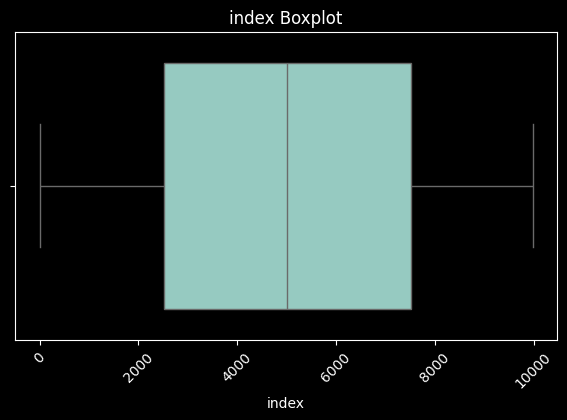

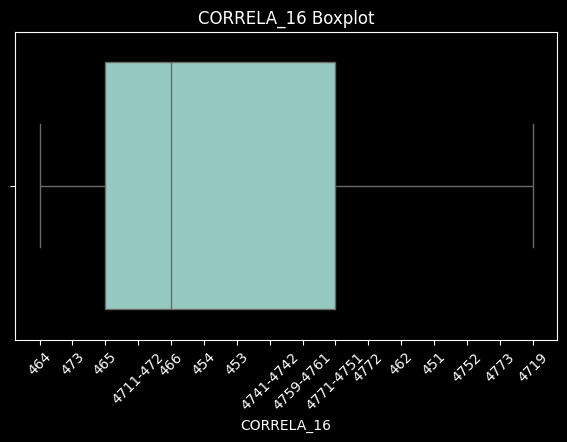

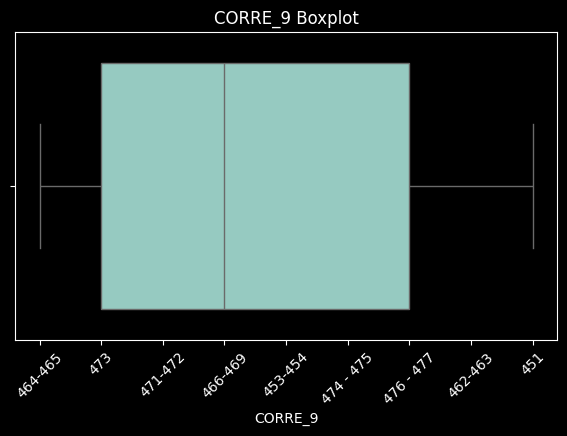

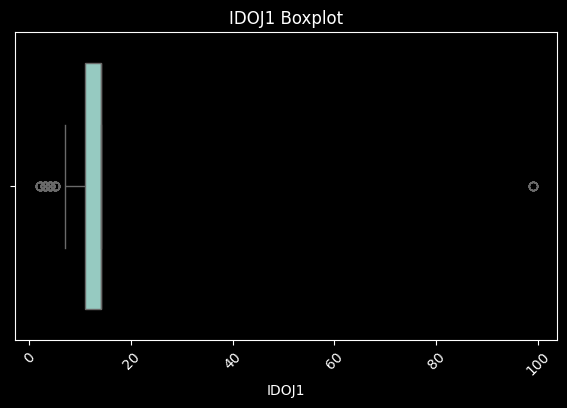

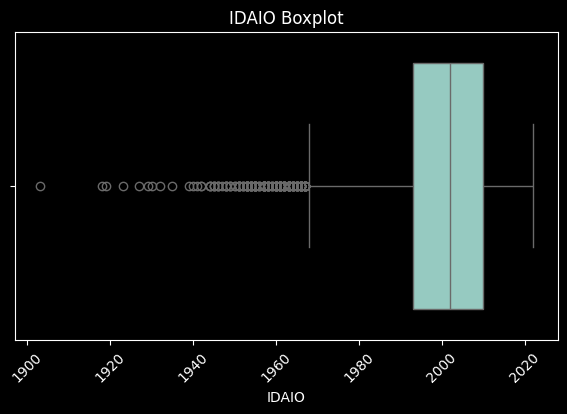

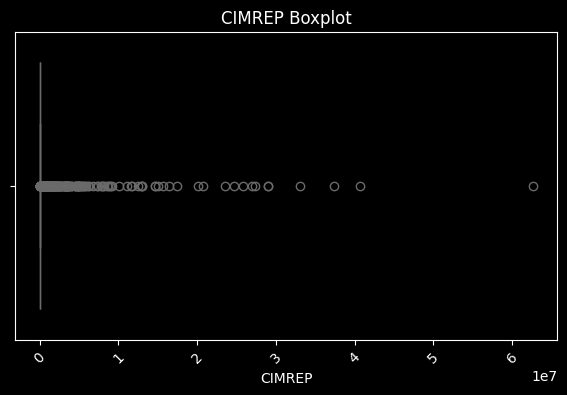

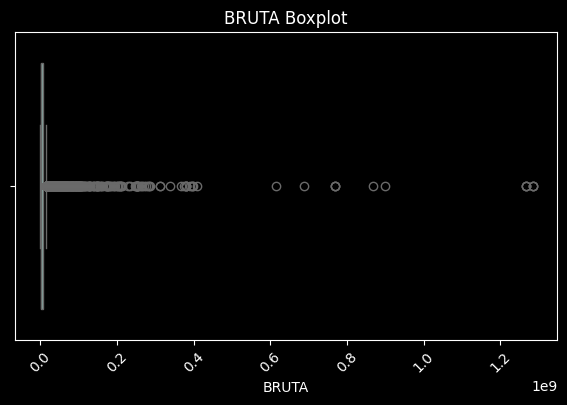

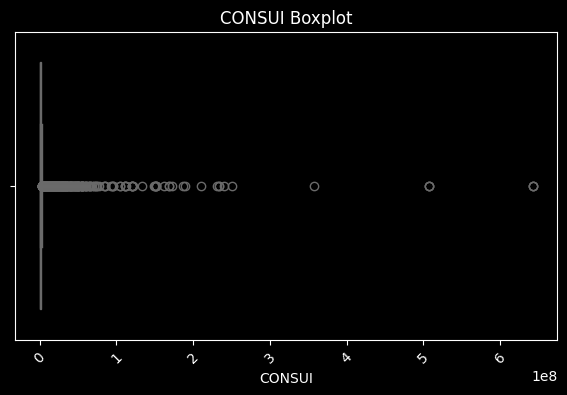

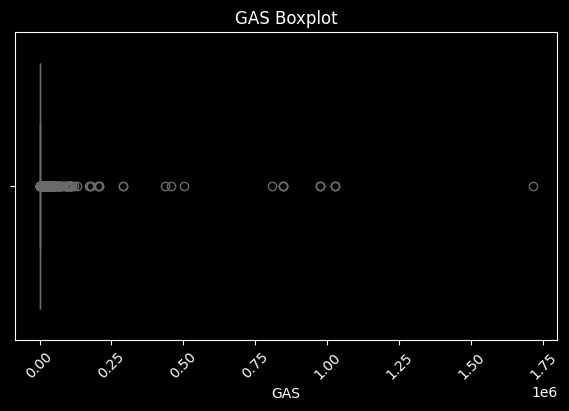

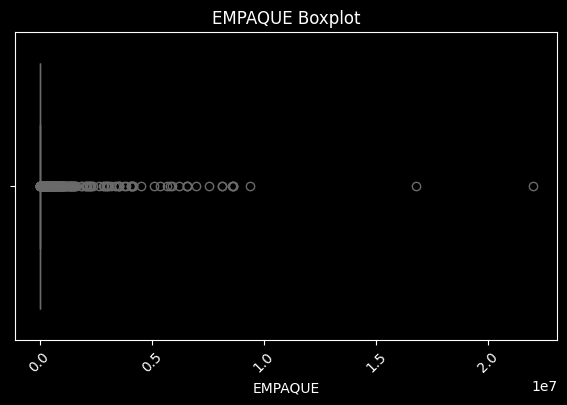

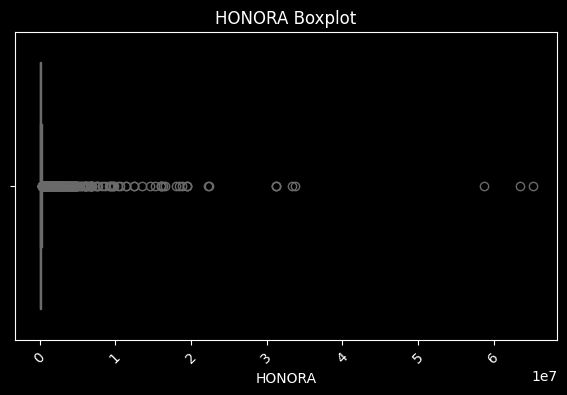

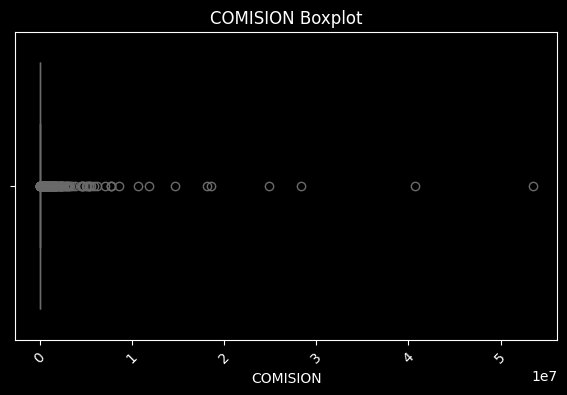

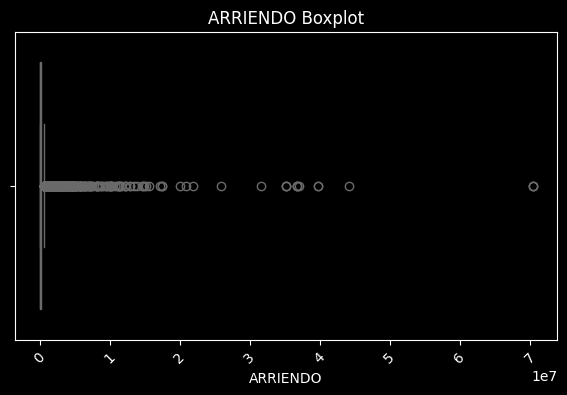

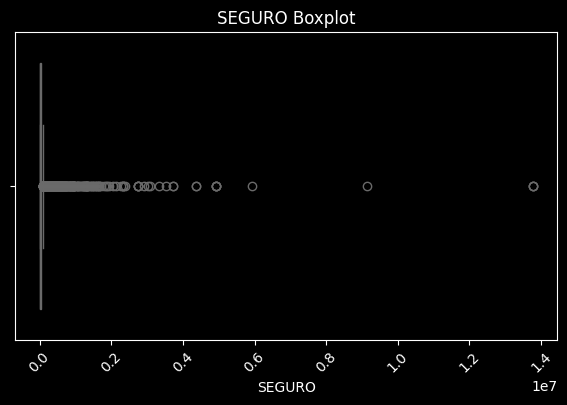

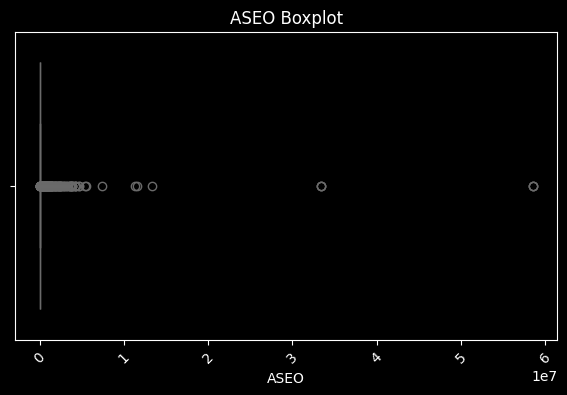

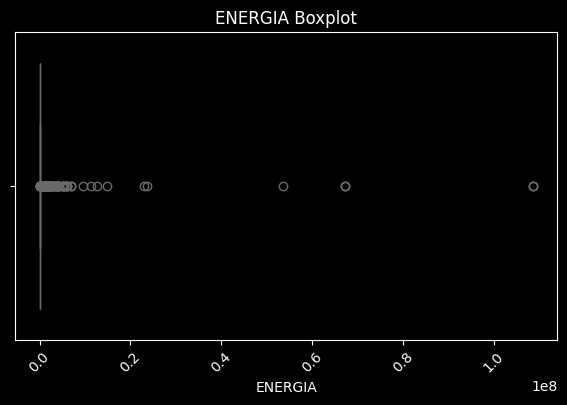

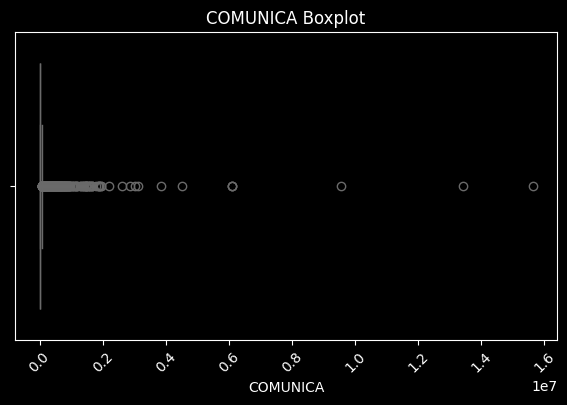

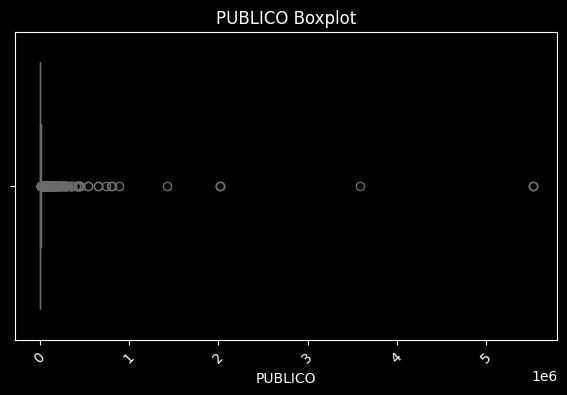

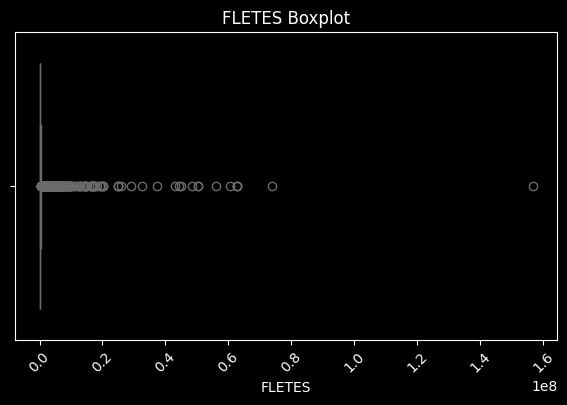

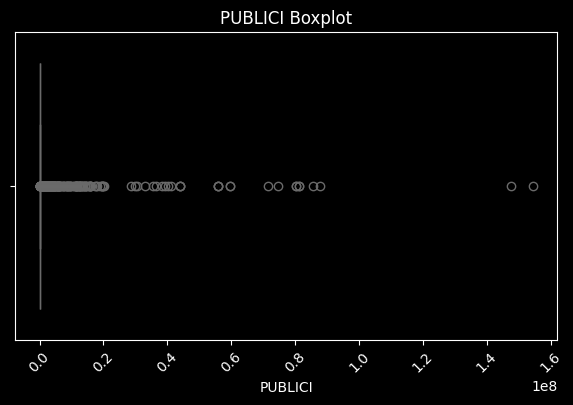

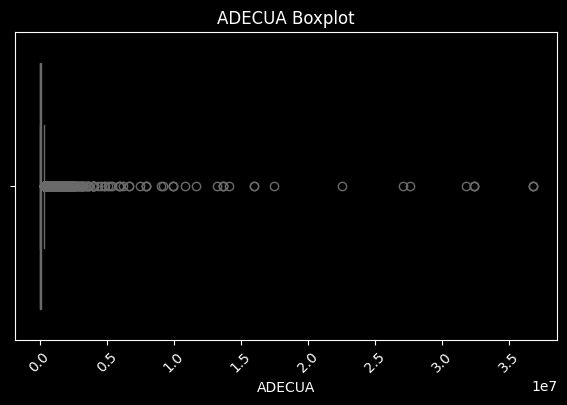

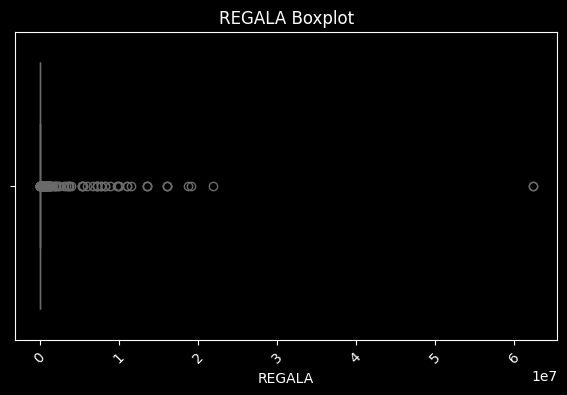

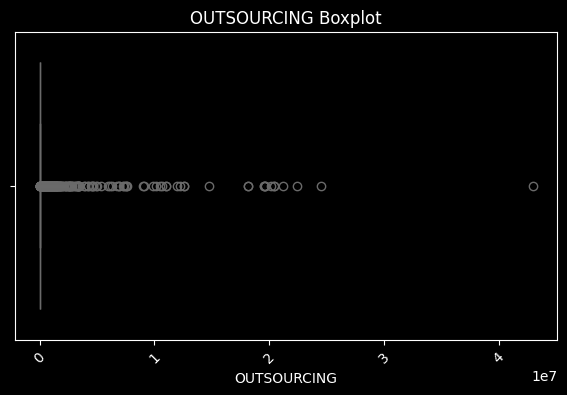

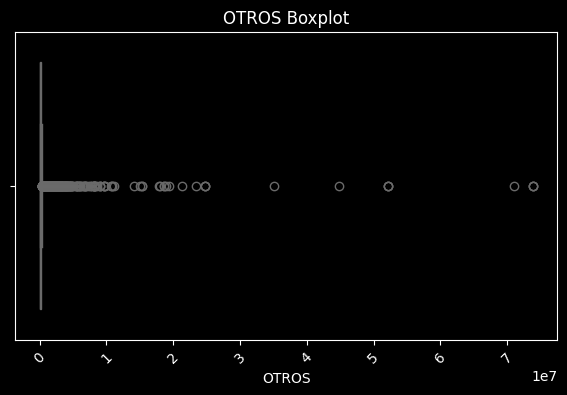

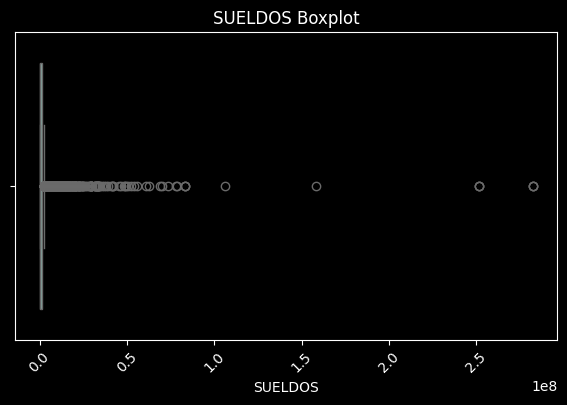

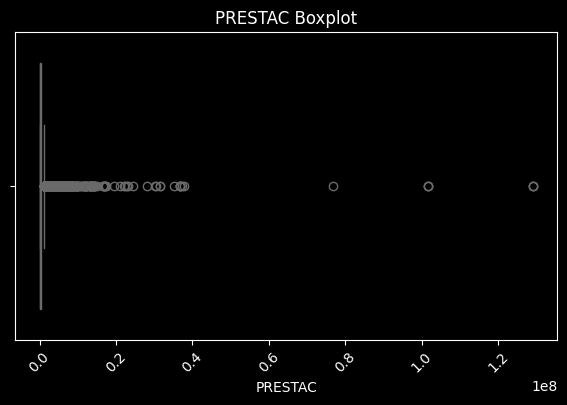

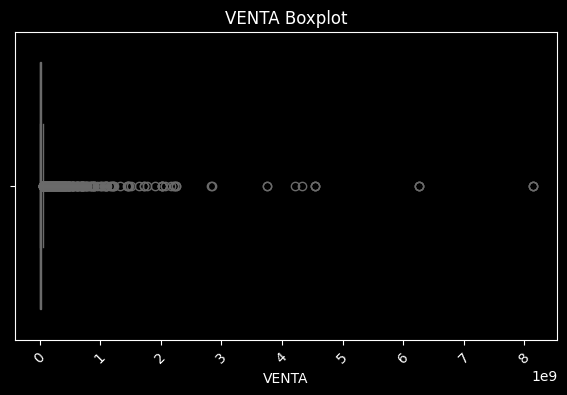

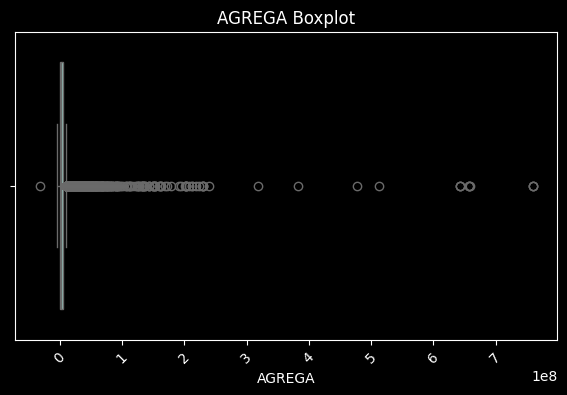

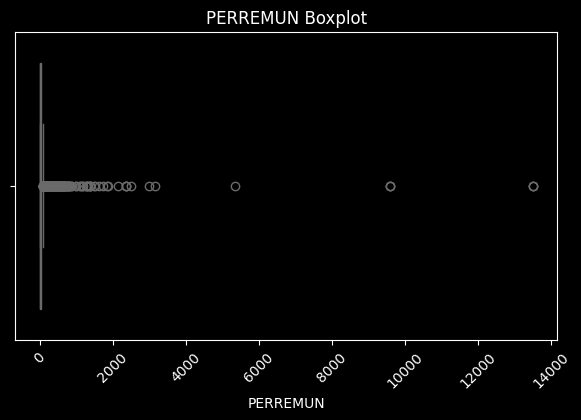

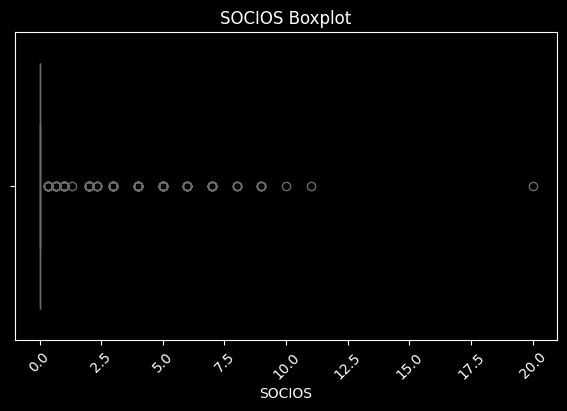

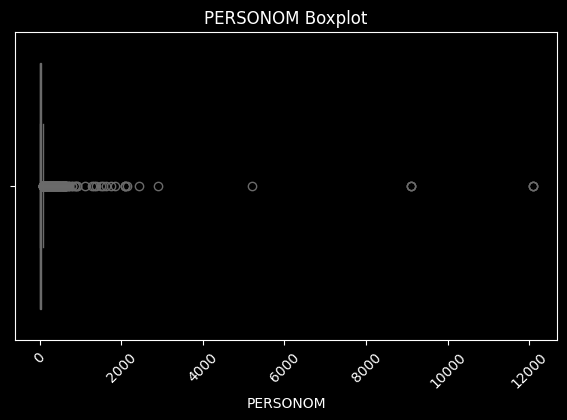

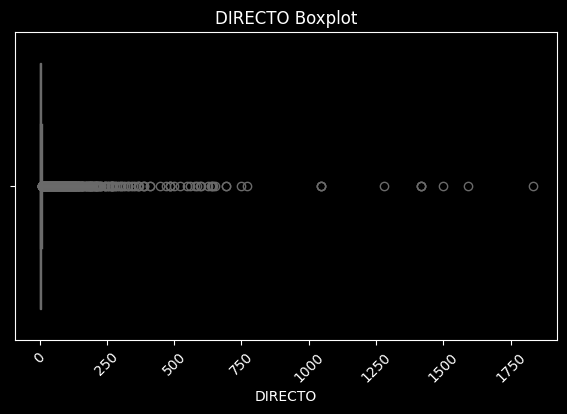

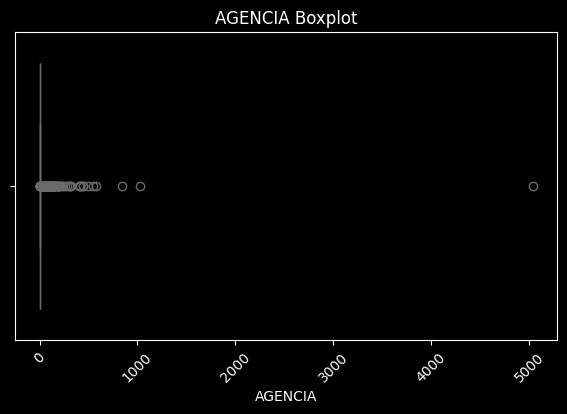

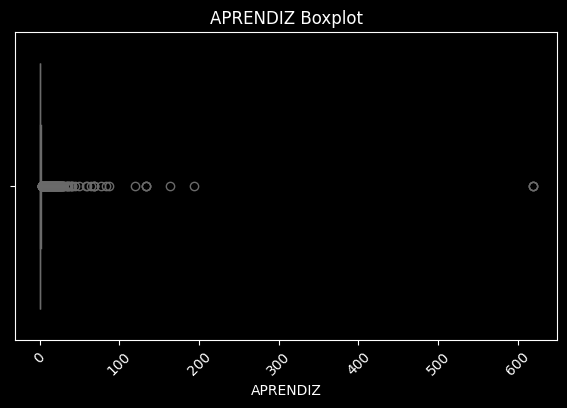

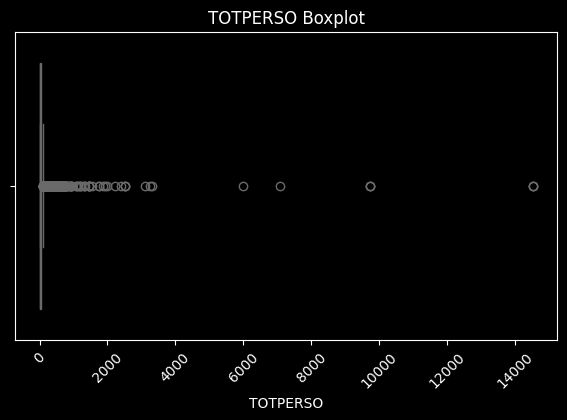

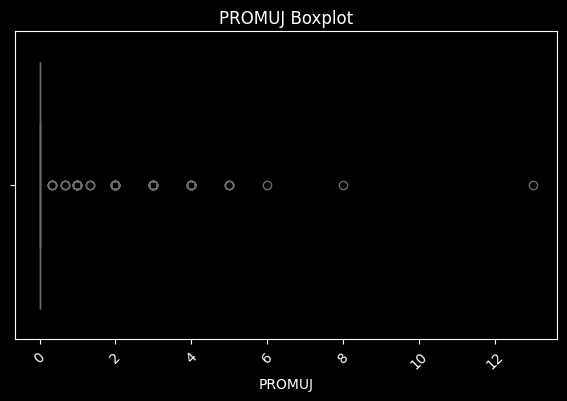

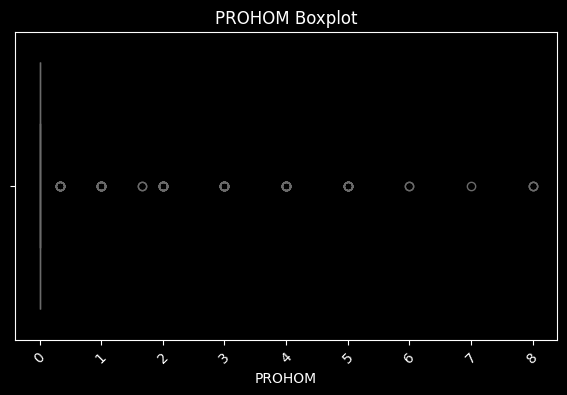

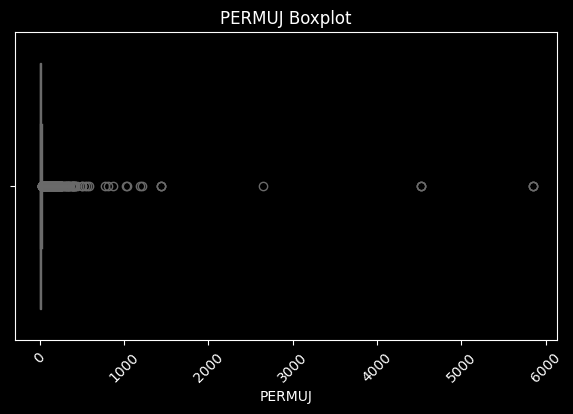

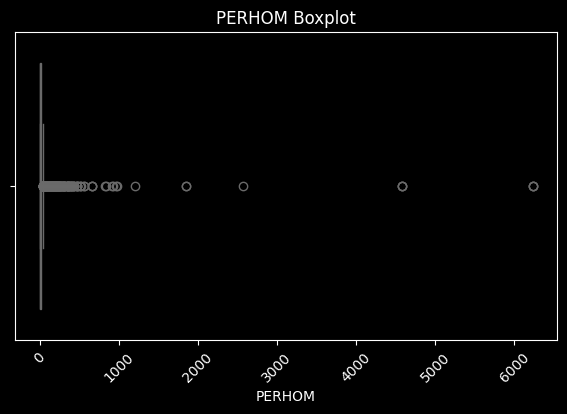

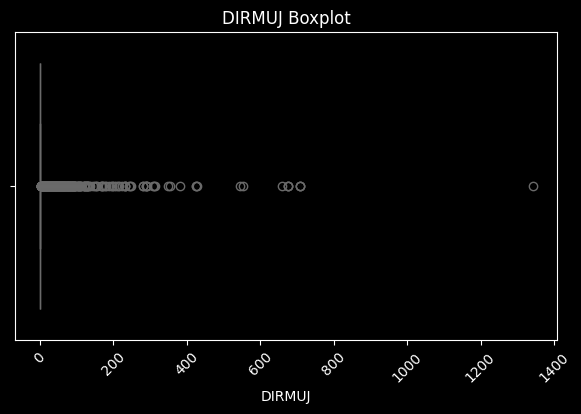

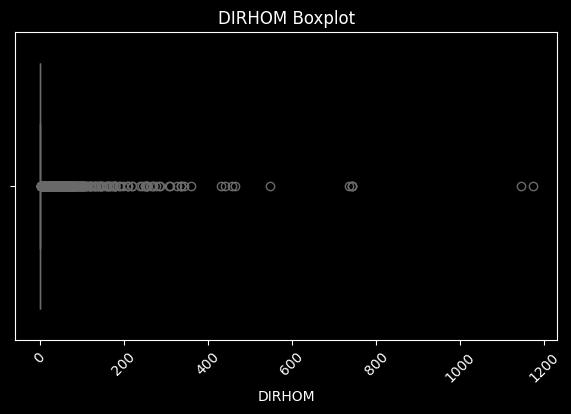

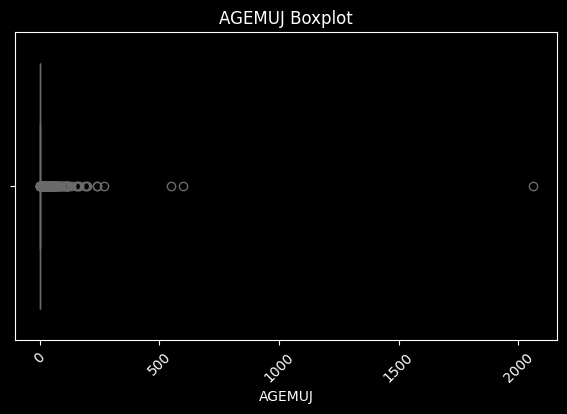

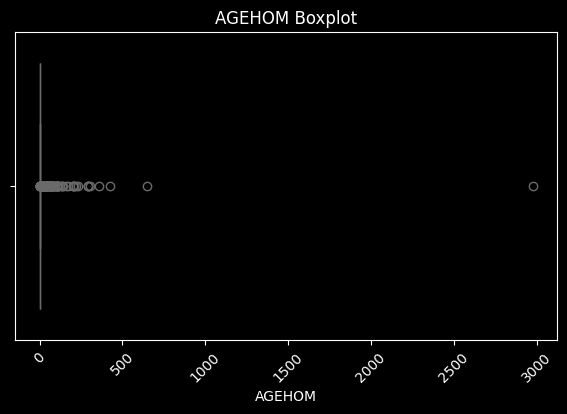

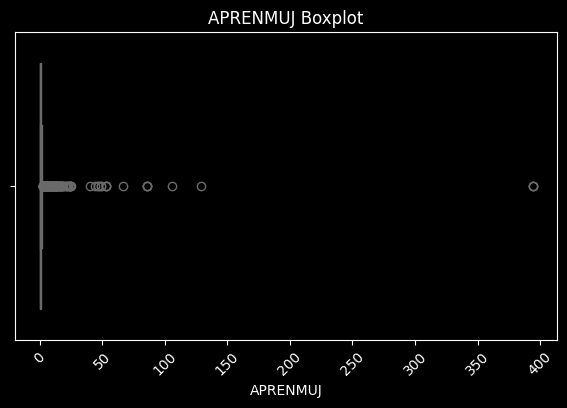

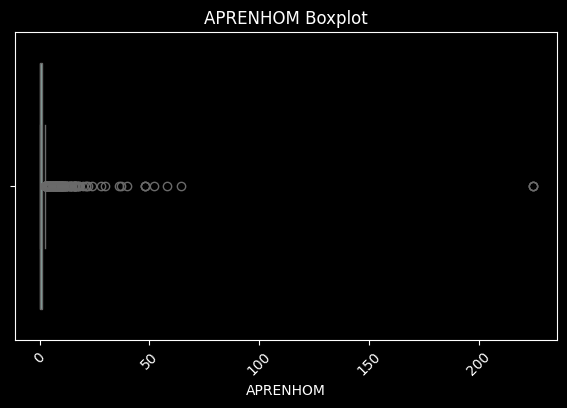

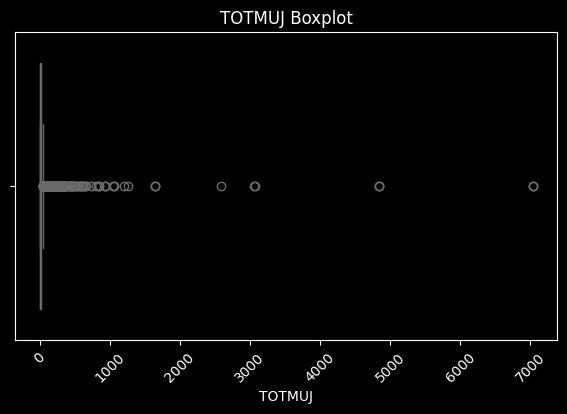

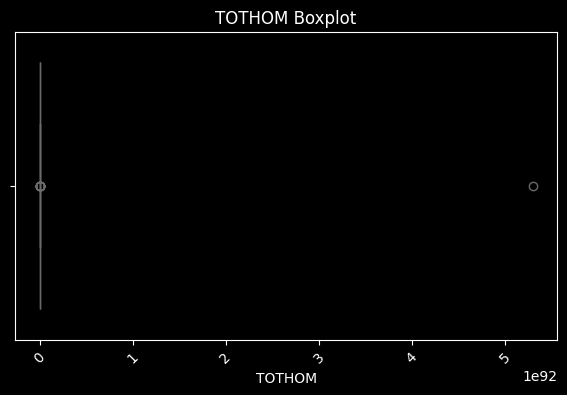

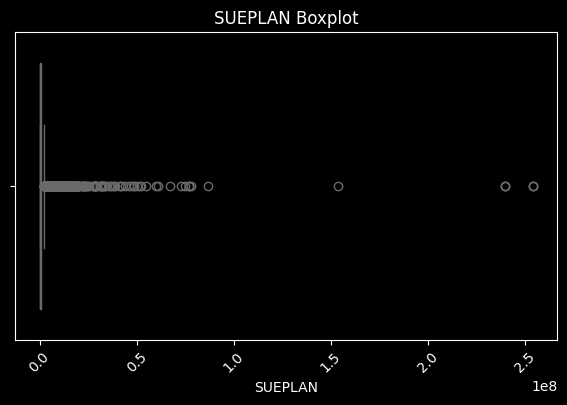

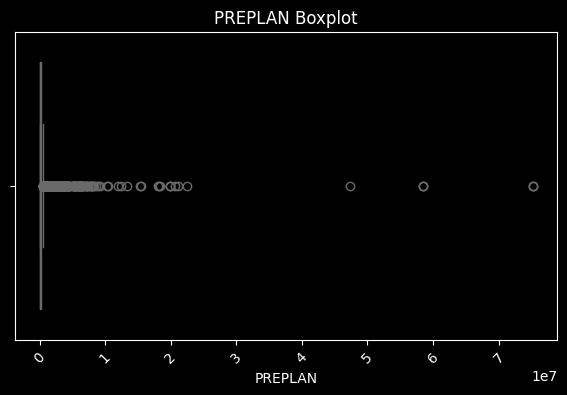

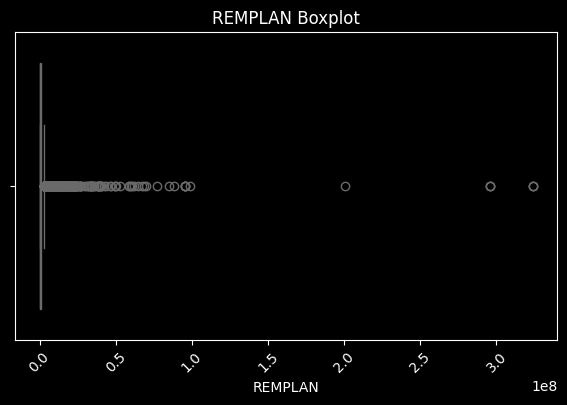

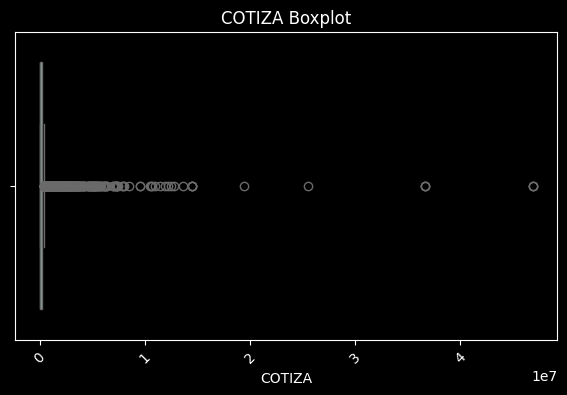

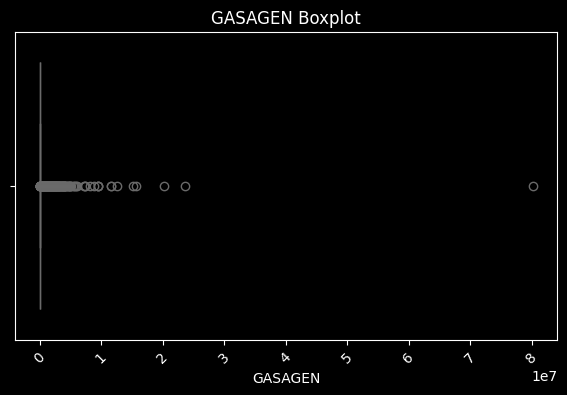

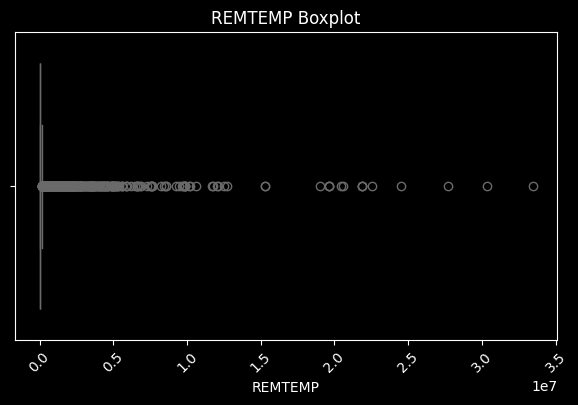

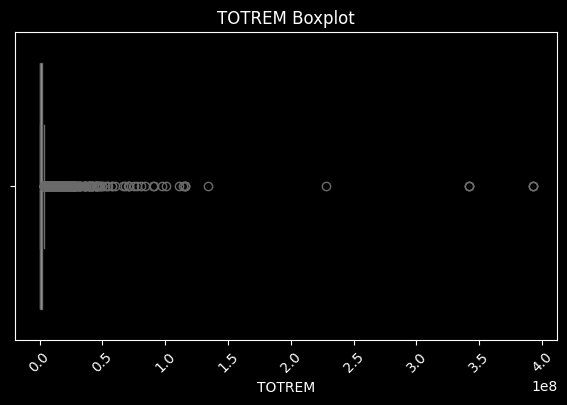

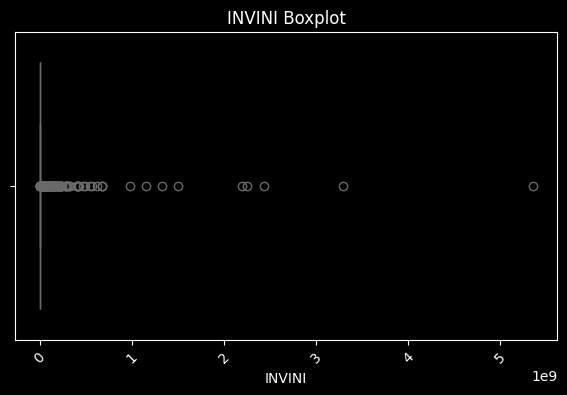

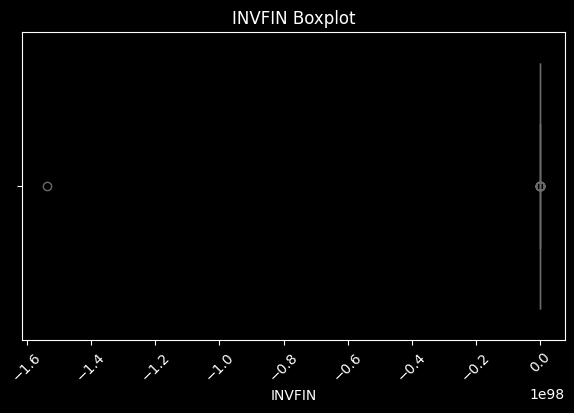

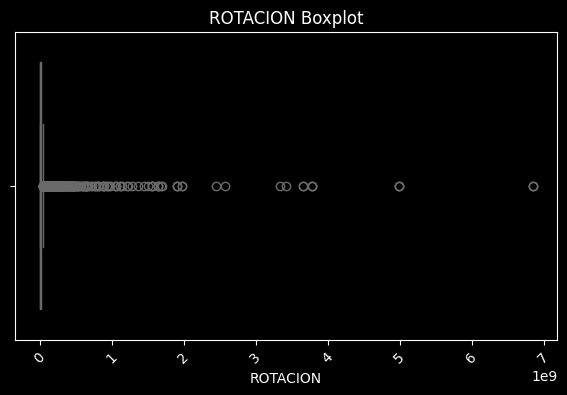

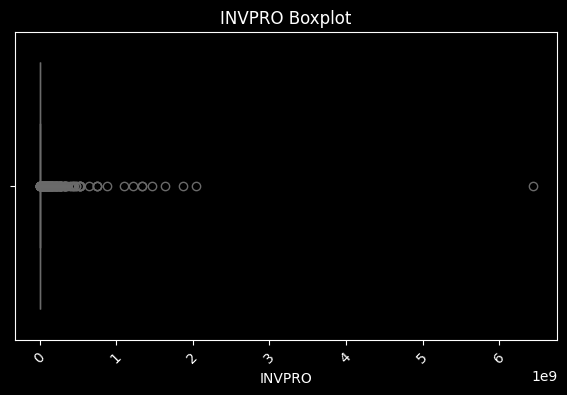

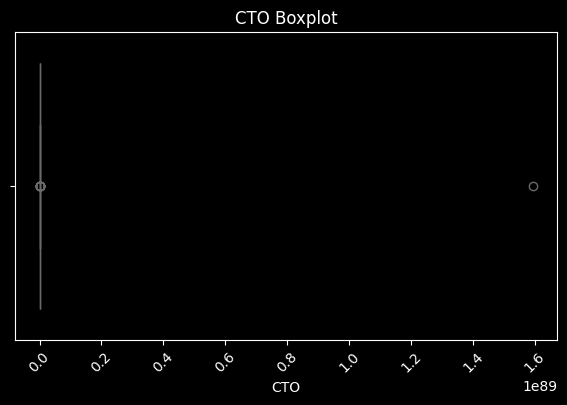

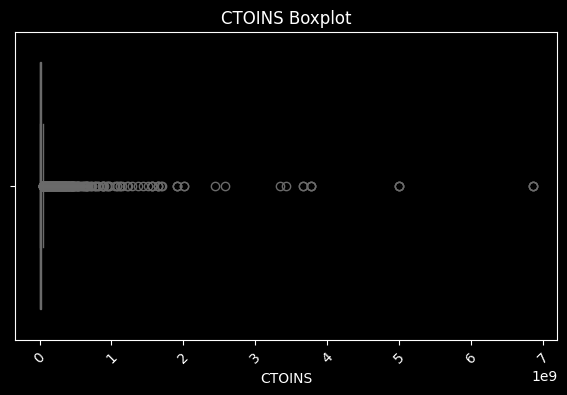

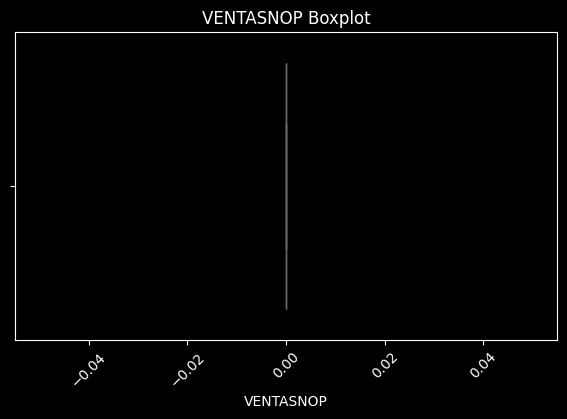

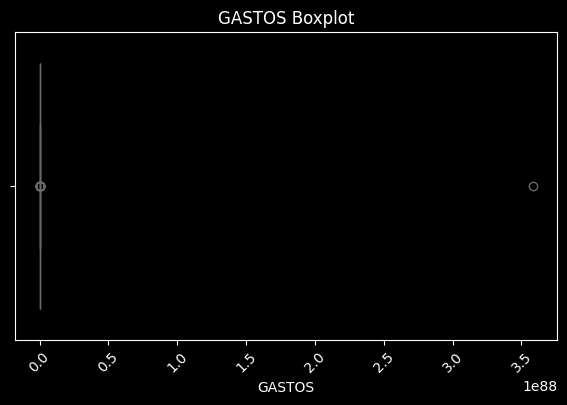

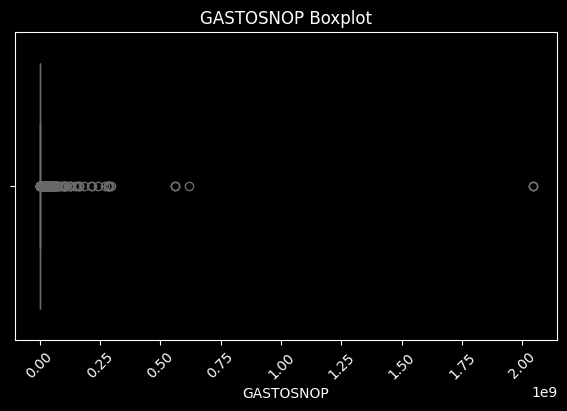

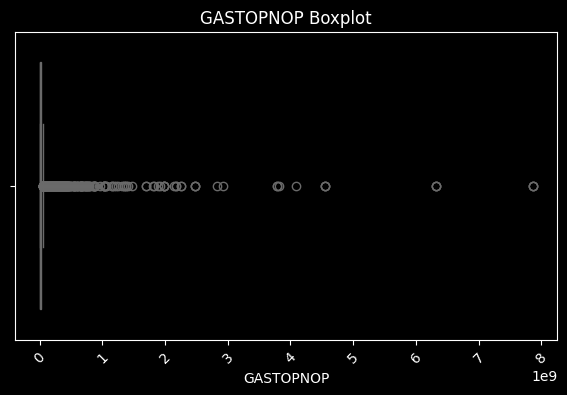

In [ ]:
sum_attr = list()

for i in df_tr_nn.columns:
  plt.figure(figsize=(7,4))
  sns.boxplot(x=str(i), data=df_tr_nn).set(title=f'{i} Boxplot', xlabel=f'{i}')
  plt.xticks(rotation=45)
  plt.show()

--> Based in the previous graphs, it can be seen that the outliers are present in most of the attributes of the DataFrame, and as it is so repetitive, removing those rows is not convenient as the data lost would be quite dramatic; in these order of ideas several methods to deal with the outliers will be performed to determine the best option to proceed according with the data.

### Replacement with the Mean and Median of the attribute

In this situation both replacements will be tested, but some additional considerations will be taken into account, the limit to determine the outliers.
That way, the first analysis will be made with the IQR to reference the limits, and then an alternative with 3 standard deviations or Z-Score.

#### IQR -- Z-Score Analysis

In [ ]:
def replace_outliers(column, limit='iqr', method='mean', threshold=3):
    '''
    The 'method' parameter must be either 'mean' or 'median'.

    The 'limit' parameter must be either 'iqr' or 'zscore'.
    '''

    ### IQR
    ##
    # Calculating the IQR (Q3 - Q1)
    Q1 = column.quantile(0.25)
    Q3 = column.quantile(0.75)
    IQR = Q3 - Q1

    # Determining limits
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR


    ### Z_Scores
    ##
    # Setting the z_scores
    z_scores = (column - column.mean()) / column.std()


    # Replacement of the outliers according with the statistic measure
    if method == 'mean':
        replacement_value = column.mean()
    elif method == 'median':
        replacement_value = column.median()
    else:
        raise ValueError("The 'method' parameter must be either 'mean' or 'median'")


    if limit == 'iqr':
        column = column.apply(lambda x: replacement_value if x < lower_bound or x > upper_bound else x)

    elif limit == 'zscore':
        column = column.where(abs(z_scores) <= threshold, replacement_value)

    else:
        raise ValueError("The 'limit' parameter must be either 'iqr' or 'zscore'")

    return column

The previous function will be used for the replacement of the values in the attributes of the Dataframe; and as for the model to test, the best determined option will be used, so, the Ridge one.

In [ ]:
X_otlrs = df_tr_nn.drop(columns=["CORRELA_16", "CORRE_9","VENTA","VENTASNOP"])
y_otlrs = df_tr_nn['VENTA']

# Replacing outliers for each case
X_2_mn = pd.DataFrame()
X_2_md = pd.DataFrame()

X_3_mn = pd.DataFrame()
X_3_md = pd.DataFrame()

for i in X_otlrs.columns:
    X_2_mn[i] = replace_outliers(column=X_otlrs[i], limit='iqr', method='mean')
    X_2_md[i] = replace_outliers(column=X_otlrs[i], limit='iqr', method='median')

for i in X_otlrs.columns:
    X_3_mn[i] = replace_outliers(column=X_otlrs[i], limit='zscore', method='mean')
    X_3_md[i] = replace_outliers(column=X_otlrs[i], limit='zscore', method='median')


# Spliting each DataFrame
X_train_2_mn, X_test_2_mn, y_train_2_mn, y_test_2_mn = train_test_split(X_2_mn, y_otlrs, test_size=0.2, random_state=42)

X_train_2_md, X_test_2_md, y_train_2_md, y_test_2_md = train_test_split(X_2_md, y_otlrs, test_size=0.2, random_state=42)

X_train_3_mn, X_test_3_mn, y_train_3_mn, y_test_3_mn = train_test_split(X_3_mn, y_otlrs, test_size=0.2, random_state=42)

X_train_3_md, X_test_3_md, y_train_3_md, y_test_3_md = train_test_split(X_3_md, y_otlrs, test_size=0.2, random_state=42)


# Scaling each DataFrame
X_train_2_mn_ = scaler.fit_transform(X_train_2_mn)
X_test_2_mn_ = scaler.transform(X_test_2_mn)

X_train_2_md_ = scaler.fit_transform(X_train_2_md)
X_test_2_md_ = scaler.transform(X_test_2_md)

X_train_3_mn_ = scaler.fit_transform(X_train_3_mn)
X_test_3_mn_ = scaler.transform(X_test_3_mn)

X_train_3_md_ = scaler.fit_transform(X_train_3_md)
X_test_3_md_ = scaler.transform(X_test_3_md)

In [ ]:
# mean - IQR
## Sub 55 = 54645867323958096(modifying tester), 24566597518520800
bst_mdl_iqr_mn = Ridge(alpha=0.000000001, solver='lbfgs', positive=True)
bst_mdl_iqr_mn.fit(X_train_2_mn_, y_train_2_mn)
bst_mdl_iqr_mn_pred = bst_mdl_iqr_mn.predict(X_test_2_mn_)
bst_mdl_iqr_mn_mse = mean_squared_error(y_test_2_mn, bst_mdl_iqr_mn_pred)
print('Mean Squared Error:', bst_mdl_iqr_mn_mse)

# Tester
tester_iqr_mn = pd.DataFrame()
for i in df_tst_nn.columns:
    tester_iqr_mn[i] = replace_outliers(column=df_tst_nn[i], limit='iqr', method='mean')
tester_iqr_mn = scaler.fit_transform(tester_iqr_mn)

Mean Squared Error: 1.3463232062072411e+17


--> According with this result, replacing all the ouliers just with the mean value of each attribute does not help the model as a lot of data is lost in the process.

In [ ]:
# median - IQR
## Sub 56 = 62491409663333504(modifying tester), 57219396892737904
bst_mdl_iqr_md = Ridge(alpha=0.000000001, solver='lbfgs', positive=True)
bst_mdl_iqr_md.fit(X_train_2_md_, y_train_2_md)
bst_mdl_iqr_md_pred = bst_mdl_iqr_md.predict(X_test_2_md_)
bst_mdl_iqr_md_mse = mean_squared_error(y_test_2_md, bst_mdl_iqr_md_pred)
print('Mean Squared Error:', bst_mdl_iqr_md_mse)

# Tester
tester_iqr_md = pd.DataFrame()
for i in df_tst_nn.columns:
    tester_iqr_md[i] = replace_outliers(column=df_tst_nn[i], limit='iqr', method='mean')
tester_iqr_md = scaler.fit_transform(tester_iqr_md)

Mean Squared Error: 1.5868679853668598e+17


--> Using the median seems to elevate the error drastically.

In [ ]:
# mean - zscore
## Sub 57 = 39545066139635600(modifying tester), 36678889435297104
bst_mdl_zscore_mn = Ridge(alpha=0.000000001, solver='lbfgs', positive=True)
bst_mdl_zscore_mn.fit(X_train_3_mn_, y_train_3_mn)
bst_mdl_zscore_mn_pred = bst_mdl_zscore_mn.predict(X_test_3_mn_)
bst_mdl_zscore_mn_mse = mean_squared_error(y_test_3_mn, bst_mdl_zscore_mn_pred)
print('Mean Squared Error:', bst_mdl_zscore_mn_mse)

# Tester
tester_zscore_mn = pd.DataFrame()
for i in df_tst_nn.columns:
    tester_zscore_mn[i] = replace_outliers(column=df_tst_nn[i], limit='zscore', method='mean')
tester_zscore_mn = scaler.fit_transform(tester_zscore_mn)

Mean Squared Error: 1.3168937262423557e+17


--> Using the Z-Score limits replacing the outliers with the mean value is not really helping to decrease the error.

In [ ]:
# median - zscore
## Sub 58 = 85195940583363296(modifying tester), 465718272093996
bst_mdl_zscore_md = Ridge(alpha=0.000000001, solver='lbfgs', positive=True)
bst_mdl_zscore_md.fit(X_train_3_md_, y_train_3_md)
bst_mdl_zscore_md_pred = bst_mdl_zscore_md.predict(X_test_3_md_)
bst_mdl_zscore_md_mse = mean_squared_error(y_test_3_md, bst_mdl_zscore_md_pred)
print('Mean Squared Error:', bst_mdl_zscore_md_mse)

# Tester
tester_zscore_md = pd.DataFrame()
for i in df_tst_nn.columns:
    tester_zscore_md[i] = replace_outliers(column=df_tst_nn[i], limit='zscore', method='mean')
tester_zscore_md = scaler.fit_transform(tester_zscore_md)

Mean Squared Error: 498854468706613.56


--> As can be seen, there is a significant improvement in the error using the median, but it is still not better than the previous result without any modifications.

#### Winsorization

In [ ]:
from scipy.stats.mstats import winsorize

In [ ]:
# Sub 59 = 82042487029053296(Transforming),23934255469829900
lower_limit = 0.05  # 5%
upper_limit = 0.95  # 95%

X_4_1 = pd.DataFrame()

for i in X_otlrs.columns:
    X_4_1[i] = winsorize(X_otlrs[i], limits=(lower_limit, 1 - upper_limit))

X_train_4_1, X_test_4_1, y_train_4_1, y_test_4_1 = train_test_split(X_4_1, y_otlrs, test_size=0.2, random_state=42)

X_train_4_1_ = scaler.fit_transform(X_train_4_1)
X_test_4_1_ = scaler.transform(X_test_4_1)

bst_mdl_4_1 = Ridge(alpha=0.000000001, solver='lbfgs', positive=True)
bst_mdl_4_1.fit(X_train_4_1_, y_train_4_1)
bst_mdl_4_1_pred = bst_mdl_4_1.predict(X_test_4_1_)
print('Mean Squared Error:', mean_squared_error(y_test_4_1, bst_mdl_4_1_pred))

# Tester
tester_4_1 = pd.DataFrame()
for i in df_tst_nn.columns:
    tester_4_1[i] = winsorize(df_tst_nn[i], limits=(lower_limit, 1 - upper_limit))
tester_4_1 = scaler.fit_transform(tester_4_1)

Mean Squared Error: 1.2745829724430723e+17


--> For what can be seen, the limits chosen do not seem to help to decrease the error of the model.

In [ ]:
# Sub 60 = 60507421975516000(Transforming),39445303865182496
lower_limit = 0.05
upper_limit = 0.70

X_4_2 = pd.DataFrame()

for i in X_otlrs.columns:
    X_4_2[i] = winsorize(X_otlrs[i], limits=(lower_limit, 1 - upper_limit))

X_train_4_2, X_test_4_2, y_train_4_2, y_test_4_2 = train_test_split(X_4_2, y_otlrs, test_size=0.2, random_state=42)

X_train_4_2_ = scaler.fit_transform(X_train_4_2)
X_test_4_2_ = scaler.transform(X_test_4_2)

bst_mdl_4_2 = Ridge(alpha=0.000000001, solver='lbfgs', positive=True)
bst_mdl_4_2.fit(X_train_4_2_, y_train_4_2)
bst_mdl_4_2_pred = bst_mdl_4_2.predict(X_test_4_2_)
print('Mean Squared Error:', mean_squared_error(y_test_4_2, bst_mdl_4_2_pred))

# Tester
tester_4_2 = pd.DataFrame()
for i in df_tst_nn.columns:
    tester_4_2[i] = winsorize(df_tst_nn[i], limits=(lower_limit, 1 - upper_limit))
tester_4_2 = scaler.fit_transform(tester_4_2)

Mean Squared Error: 1.5112129086563837e+17


--> Decreasing just the upper_limit seems to worsen the error.

In [ ]:
# Sub 61 = 60221395239718400(Transforming),38817878177569600
lower_limit = 0.30
upper_limit = 0.70

X_4_3 = pd.DataFrame()

for i in X_otlrs.columns:
    X_4_3[i] = winsorize(X_otlrs[i], limits=(lower_limit, 1 - upper_limit))

X_train_4_3, X_test_4_3, y_train_4_3, y_test_4_3 = train_test_split(X_4_3, y_otlrs, test_size=0.2, random_state=42)

X_train_4_3_ = scaler.fit_transform(X_train_4_3)
X_test_4_3_ = scaler.transform(X_test_4_3)

bst_mdl_4_3 = Ridge(alpha=0.000000001, solver='lbfgs', positive=True)
bst_mdl_4_3.fit(X_train_4_3_, y_train_4_3)
bst_mdl_4_3_pred = bst_mdl_4_3.predict(X_test_4_3_)
print('Mean Squared Error:', mean_squared_error(y_test_4_3, bst_mdl_4_3_pred))

# Tester
tester_4_3 = pd.DataFrame()
for i in df_tst_nn.columns:
    tester_4_3[i] = winsorize(df_tst_nn[i], limits=(lower_limit, 1 - upper_limit))
tester_4_3 = scaler.fit_transform(tester_4_3)

Mean Squared Error: 1.5069658101080032e+17


In [ ]:
# Sub 62 = 22099725211676100(Transforming),17579705070259700
lower_limit = 0.01
upper_limit = 0.99

X_4_4 = pd.DataFrame()

for i in X_otlrs.columns:
    X_4_4[i] = winsorize(X_otlrs[i], limits=(lower_limit, 1 - upper_limit))

X_train_4_4, X_test_4_4, y_train_4_4, y_test_4_4 = train_test_split(X_4_4, y_otlrs, test_size=0.2, random_state=42)

X_train_4_4_ = scaler.fit_transform(X_train_4_4)
X_test_4_4_ = scaler.transform(X_test_4_4)

bst_mdl_4_4 = Ridge(alpha=0.000000001, solver='lbfgs', positive=True)
bst_mdl_4_4.fit(X_train_4_4_, y_train_4_4)
bst_mdl_4_4_pred = bst_mdl_4_4.predict(X_test_4_4_)
print('Mean Squared Error:', mean_squared_error(y_test_4_4, bst_mdl_4_4_pred))

# Tester
tester_4_4 = pd.DataFrame()
for i in df_tst_nn.columns:
    tester_4_4[i] = winsorize(df_tst_nn[i], limits=(lower_limit, 1 - upper_limit))
tester_4_4 = scaler.fit_transform(tester_4_4)

Mean Squared Error: 8.535885482107162e+16


In [ ]:
# Sub 63 = 1368287076234370
lower_limit = 0.001
upper_limit = 0.999

X_4_5 = pd.DataFrame()

for i in X_otlrs.columns:
    X_4_5[i] = winsorize(X_otlrs[i], limits=(lower_limit, 1 - upper_limit))

X_train_4_5, X_test_4_5, y_train_4_5, y_test_4_5 = train_test_split(X_4_5, y_otlrs, test_size=0.2, random_state=42)

X_train_4_5_ = scaler.fit_transform(X_train_4_5)
X_test_4_5_ = scaler.transform(X_test_4_5)

bst_mdl_4_5 = Ridge(alpha=0.000000001, solver='lbfgs', positive=True)
bst_mdl_4_5.fit(X_train_4_5_, y_train_4_5)
bst_mdl_4_5_pred = bst_mdl_4_5.predict(X_test_4_5_)
print('Mean Squared Error:', mean_squared_error(y_test_4_5, bst_mdl_4_5_pred))

Mean Squared Error: 7107854032783136.0


--> It seems as lowerin the limits is decreasing the error as needed.

In [ ]:
# Sub 64 = 286151729440138
lower_limit = 0.00001
upper_limit = 0.99999

X_4_6 = pd.DataFrame()

for i in X_otlrs.columns:
    X_4_6[i] = winsorize(X_otlrs[i], limits=(lower_limit, 1 - upper_limit))

X_train_4_6, X_test_4_6, y_train_4_6, y_test_4_6 = train_test_split(X_4_6, y_otlrs, test_size=0.2, random_state=42)

X_train_4_6_ = scaler.fit_transform(X_train_4_6)
X_test_4_6_ = scaler.transform(X_test_4_6)

bst_mdl_4_6 = Ridge(alpha=0.000000001, solver='lbfgs', positive=True)
bst_mdl_4_6.fit(X_train_4_6_, y_train_4_6)
bst_mdl_4_6_pred = bst_mdl_4_6.predict(X_test_4_6_)
print('Mean Squared Error:', mean_squared_error(y_test_4_6, bst_mdl_4_6_pred))

Mean Squared Error: 1187999769453.3777


--> By this point the error is almost as low as without any modification of the outliers

In [ ]:
# Sub 65 = 286151729440138
lower_limit = 0.0000000001
upper_limit = 0.9999999999

X_4_7 = pd.DataFrame()

for i in X_otlrs.columns:
    X_4_7[i] = winsorize(X_otlrs[i], limits=(lower_limit, 1 - upper_limit))

X_train_4_7, X_test_4_7, y_train_4_7, y_test_4_7 = train_test_split(X_4_7, y_otlrs, test_size=0.2, random_state=42)

X_train_4_7_ = scaler.fit_transform(X_train_4_7)
X_test_4_7_ = scaler.transform(X_test_4_7)

bst_mdl_4_7 = Ridge(alpha=0.000000001, solver='lbfgs', positive=True)
bst_mdl_4_7.fit(X_train_4_7_, y_train_4_7)
bst_mdl_4_7_pred = bst_mdl_4_7.predict(X_test_4_7_)
print('Mean Squared Error:', mean_squared_error(y_test_4_7, bst_mdl_4_7_pred))

Mean Squared Error: 1187999769453.3777


--> The score will not move any further with that modification.

In [ ]:
# Sub 66 = 286151729440138
# lower_limit = 0.0000000001
# upper_limit = 0.9999999999

X_4_8 = pd.DataFrame()

for i in X_otlrs.columns:
    X_4_8[i] = winsorize(X_otlrs[i])

X_train_4_8, X_test_4_8, y_train_4_8, y_test_4_8 = train_test_split(X_4_8, y_otlrs, test_size=0.2, random_state=42)

X_train_4_8_ = scaler.fit_transform(X_train_4_8)
X_test_4_8_ = scaler.transform(X_test_4_8)

bst_mdl_4_8 = Ridge(alpha=0.000000001, solver='lbfgs', positive=True)
bst_mdl_4_8.fit(X_train_4_8_, y_train_4_8)
bst_mdl_4_8_pred = bst_mdl_4_8.predict(X_test_4_8_)
print('Mean Squared Error:', mean_squared_error(y_test_4_8, bst_mdl_4_8_pred))

Mean Squared Error: 1187999769453.3777


In [ ]:
# Sub 66 = 286151729440138
lower_limit = 0.01
upper_limit = 1

X_4_9 = pd.DataFrame()

for i in X_otlrs.columns:
    X_4_9[i] = winsorize(X_otlrs[i])

X_train_4_9, X_test_4_9, y_train_4_9, y_test_4_9 = train_test_split(X_4_9, y_otlrs, test_size=0.2, random_state=42)

X_train_4_9_ = scaler.fit_transform(X_train_4_9)
X_test_4_9_ = scaler.transform(X_test_4_9)

bst_mdl_4_9 = Ridge(alpha=0.000000001, solver='lbfgs', positive=True)
bst_mdl_4_9.fit(X_train_4_9_, y_train_4_9)
bst_mdl_4_9_pred = bst_mdl_4_9.predict(X_test_4_9_)
print('Mean Squared Error:', mean_squared_error(y_test_4_9, bst_mdl_4_9_pred))

Mean Squared Error: 1187999769453.3777


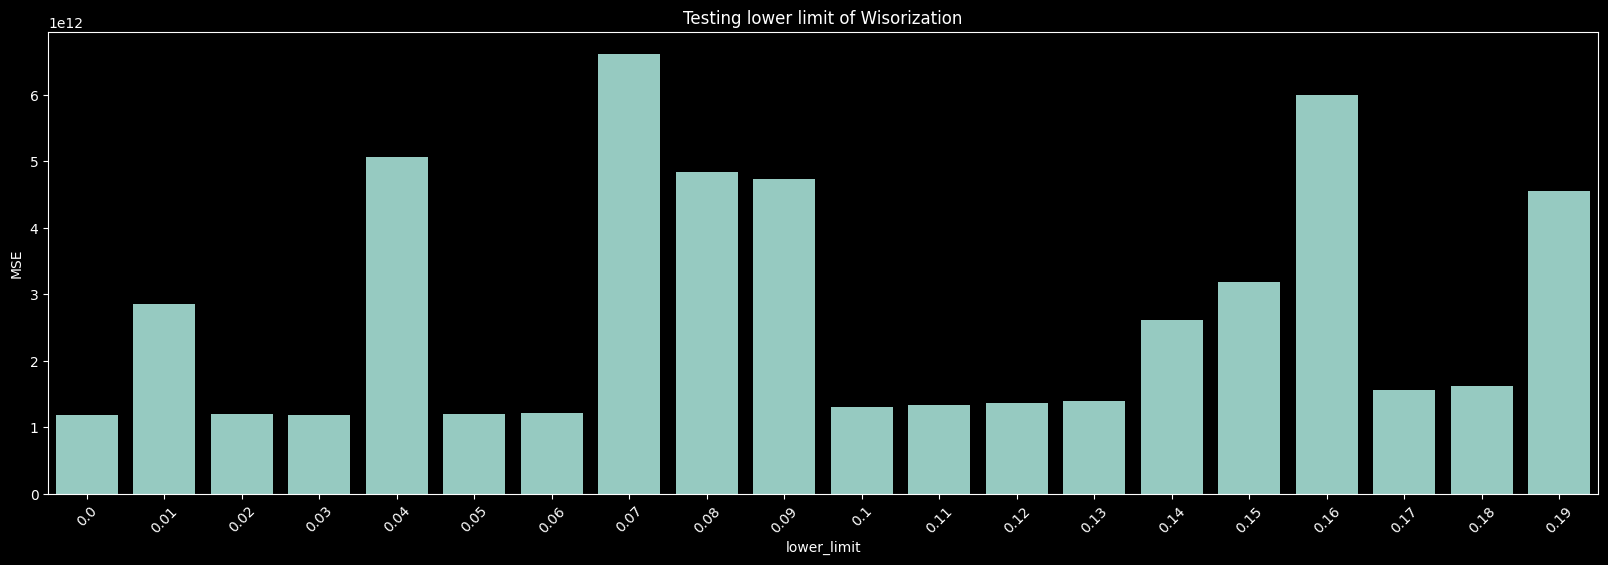

,lower_limit,MSEs
0,0.00,1.188000e+12
1,0.01,2.852121e+12
2,0.02,1.203392e+12
3,0.03,1.188210e+12
4,0.04,5.072394e+12
5,0.05,1.199176e+12
6,0.06,1.221950e+12
7,0.07,6.618828e+12
8,0.08,4.838578e+12
9,0.09,4.739399e+12


1187999769453.3777


In [ ]:
# Sub 67 =

iss = np.linspace(0,0.19,20)
mses = list()

for i in iss:
    lower_limit = i
    upper_limit = 1

    X_4_9 = pd.DataFrame()

    for i in X_otlrs.columns:
        X_4_9[i] = winsorize(X_otlrs[i], limits=(lower_limit, 1 - upper_limit))

    X_train_4_9, X_test_4_9, y_train_4_9, y_test_4_9 = train_test_split(X_4_9, y_otlrs, test_size=0.2, random_state=42)

    X_train_4_9_ = scaler.fit_transform(X_train_4_9)
    X_test_4_9_ = scaler.transform(X_test_4_9)

    bst_mdl_4_9 = Ridge(alpha=0.000000001, solver='lbfgs', positive=True)
    bst_mdl_4_9.fit(X_train_4_9_, y_train_4_9)
    bst_mdl_4_9_pred = bst_mdl_4_9.predict(X_test_4_9_)
    # print('Mean Squared Error:', mean_squared_error(y_test_4_9, bst_mdl_4_9_pred))
    mses.append(mean_squared_error(y_test_4_9, bst_mdl_4_9_pred))

plt.figure(figsize=(20,6))
sns.barplot(x=iss, y=mses).set(title='Testing lower limit of Wisorization', xlabel='lower_limit', ylabel='MSE')
plt.xticks(rotation=45)
plt.show()

display(pd.DataFrame({
    'lower_limit' : iss,
    'MSEs' : mses
}))

print(min(mses))

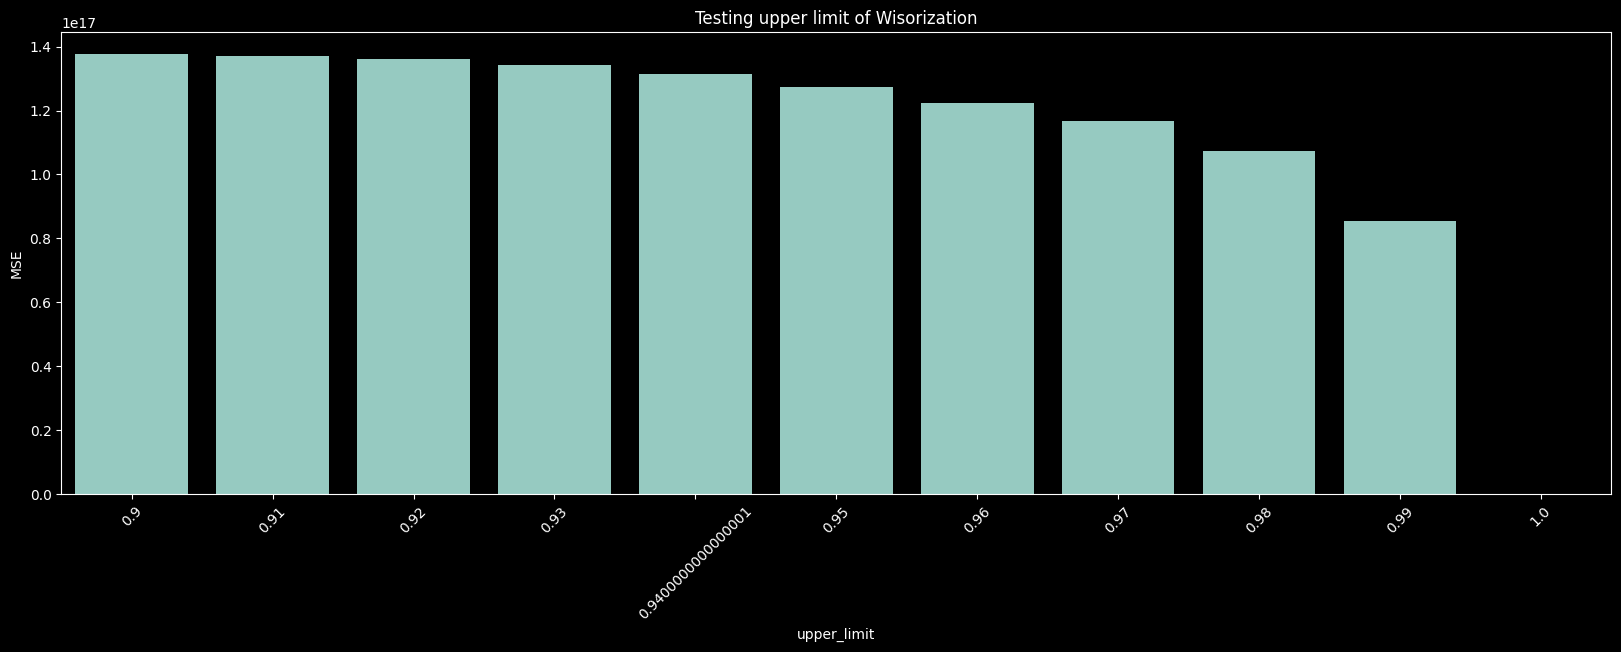

,upper_limit,MSEs
0,0.90,1.376161e+17
1,0.91,1.371123e+17
2,0.92,1.359788e+17
3,0.93,1.342668e+17
4,0.94,1.314690e+17
5,0.95,1.273952e+17
6,0.96,1.224732e+17
7,0.97,1.168671e+17
8,0.98,1.072889e+17
9,0.99,8.533352e+16


1187999769453.3777


In [ ]:
# Sub 67 =

iss = np.linspace(0.9,1,11)
mses = list()

for i in iss:
    lower_limit = 0
    upper_limit = i

    X_4_9 = pd.DataFrame()

    for i in X_otlrs.columns:
        X_4_9[i] = winsorize(X_otlrs[i], limits=(lower_limit, 1 - upper_limit))

    X_train_4_9, X_test_4_9, y_train_4_9, y_test_4_9 = train_test_split(X_4_9, y_otlrs, test_size=0.2, random_state=42)

    X_train_4_9_ = scaler.fit_transform(X_train_4_9)
    X_test_4_9_ = scaler.transform(X_test_4_9)

    bst_mdl_4_9 = Ridge(alpha=0.000000001, solver='lbfgs', positive=True)
    bst_mdl_4_9.fit(X_train_4_9_, y_train_4_9)
    bst_mdl_4_9_pred = bst_mdl_4_9.predict(X_test_4_9_)
    # print('Mean Squared Error:', mean_squared_error(y_test_4_9, bst_mdl_4_9_pred))
    mses.append(mean_squared_error(y_test_4_9, bst_mdl_4_9_pred))

plt.figure(figsize=(20,6))
sns.barplot(x=iss, y=mses).set(title='Testing upper limit of Wisorization', xlabel='upper_limit', ylabel='MSE')
plt.xticks(rotation=45)
plt.show()

display(pd.DataFrame({
    'upper_limit' : iss,
    'MSEs' : mses
}))

print(min(mses))

--> Given the previous analysis, the Winsorization will not improve the score of the model as its limit has even a higher error.

In [ ]:
min(1187999769453.3777,6430972625598.019)

1187999769453.3777

#### Other Methods 1

In [ ]:
# Sub 67 = 15212425573209300
X_5_1 = pd.DataFrame()

dev_num = 3

for i in X_otlrs.columns:
    column = list()
    for n in X_otlrs[i]:
        z_sc = (n - X_otlrs[i].mean()) / X_otlrs[i].std()
        if abs(z_sc) > dev_num:
            if z_sc > 0:
                n = (X_otlrs[i].std() * dev_num) + X_otlrs[i].mean()
                column.append(n)
            else:
                n = (X_otlrs[i].std() * dev_num) - X_otlrs[i].mean()
                column.append(n)

        else:
            column.append(n)

    X_5_1[i] = column



X_train_5_1, X_test_5_1, y_train_5_1, y_test_5_1 = train_test_split(X_5_1, y_otlrs, test_size=0.2, random_state=42)

X_train_5_1_ = scaler.fit_transform(X_train_5_1)
X_test_5_1_ = scaler.transform(X_test_5_1)

bst_mdl_5_1 = Ridge(alpha=0.000000001, solver='lbfgs', positive=True)
bst_mdl_5_1.fit(X_train_5_1_, y_train_5_1)
bst_mdl_5_1_pred = bst_mdl_5_1.predict(X_test_5_1_)
print('Mean Squared Error:', mean_squared_error(y_test_5_1, bst_mdl_5_1_pred))

Mean Squared Error: 5.393997741303849e+16


--> According with the tests of this section, every attempt to modify the outliers seem to worsen the error, so the best option is to leave them as they are.

## 3.3. PCA Aplication

In [ ]:
X_otlrs.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7488 entries, 0 to 7487
Data columns (total 60 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   index        7488 non-null   int64  
 1   IDOJ1        7488 non-null   float64
 2   IDAIO        7488 non-null   float64
 3   CIMREP       7488 non-null   float64
 4   BRUTA        7488 non-null   float64
 5   CONSUI       7488 non-null   float64
 6   GAS          7488 non-null   float64
 7   EMPAQUE      7488 non-null   float64
 8   HONORA       7488 non-null   float64
 9   COMISION     7488 non-null   float64
 10  ARRIENDO     7488 non-null   float64
 11  SEGURO       7488 non-null   float64
 12  ASEO         7488 non-null   float64
 13  ENERGIA      7488 non-null   float64
 14  COMUNICA     7488 non-null   float64
 15  PUBLICO      7488 non-null   float64
 16  FLETES       7488 non-null   float64
 17  PUBLICI      7488 non-null   float64
 18  ADECUA       7488 non-null   float64
 19  REGALA

--> Since the DataFrame has 60 attributes, the PCA will be evaluated in several cases to check the best option.

In [ ]:
len(mses)

59

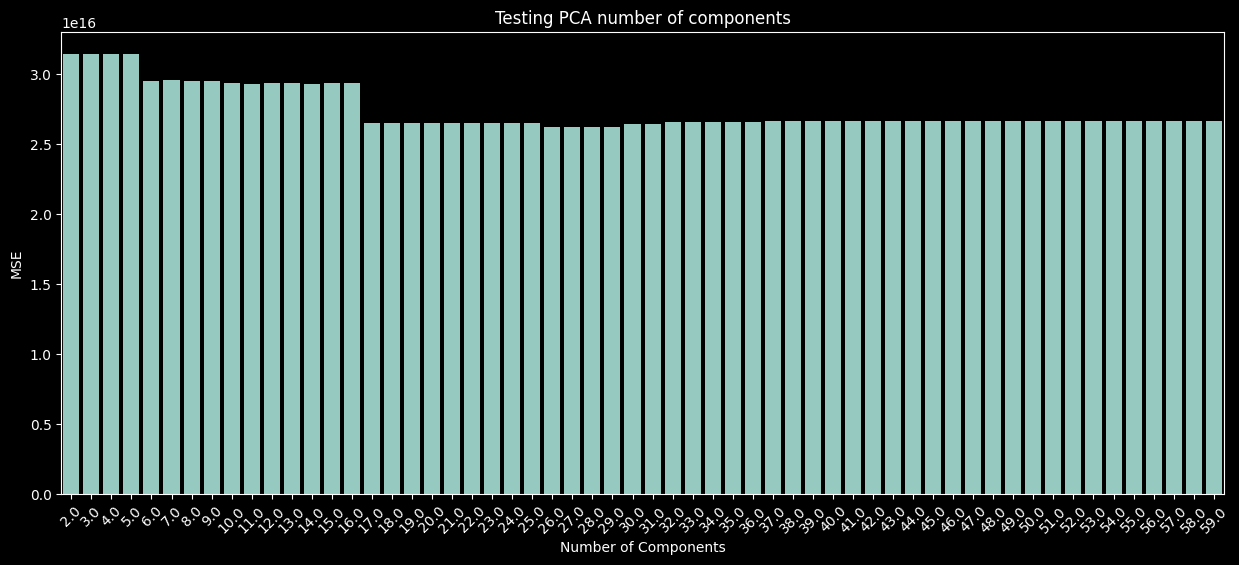

,upper_limit,MSEs
0,2.0,3.142026e+16
1,3.0,3.142026e+16
2,4.0,3.142026e+16
3,5.0,3.142026e+16
4,6.0,2.951924e+16
5,7.0,2.953035e+16
6,8.0,2.952221e+16
7,9.0,2.952717e+16
8,10.0,2.933495e+16
9,11.0,2.925747e+16


2.6222372573567456e+16


In [ ]:
X_pca_6 = scaler.fit_transform(X_otlrs)

pca_components = np.linspace(2, X_otlrs.shape[1]-1, 58)
mses = list()

for i in pca_components:

    pca = PCA(n_components=int(i), svd_solver='randomized', power_iteration_normalizer='LU')
    X_pca = pca.fit_transform(X_pca_6)

    X_train_6, X_test_6, y_train_6, y_test_6 = train_test_split(X_pca, y_otlrs, test_size=0.2, random_state=42)

    bst_mdl_pca = Ridge(alpha=0.000000001, solver='lbfgs', positive=True)
    bst_mdl_pca.fit(X_train_6, y_train_6)
    bst_mdl_pca_pred = bst_mdl_pca.predict(X_test_6)
    mses.append(mean_squared_error(y_test_6, bst_mdl_pca_pred))

plt.figure(figsize=(15,6))
sns.barplot(x=pca_components, y=mses).set(title='Testing PCA number of components', xlabel='Number of Components', ylabel='MSE')
plt.xticks(rotation=45)
plt.show()

display(pd.DataFrame({
    'upper_limit' : pca_components,
    'MSEs' : mses
}))

print(min(mses))


--> As could be seen, applying PCA does not seem to better the score at all but only worsen it.

In [ ]:
# Sub 68 =  18506012824239300
pca_1 = PCA(n_components=5, svd_solver='randomized', power_iteration_normalizer='LU')
X_pca_1_ = pca_1.fit_transform(X_pca_6)

X_train_6_1, X_test_6_1, y_train_6_1, y_test_6_1 = train_test_split(X_pca_1_, y_otlrs, test_size=0.2, random_state=42)

bst_mdl_pca_1 = Ridge(alpha=0.000000001, solver='lbfgs', positive=True)
bst_mdl_pca_1.fit(X_train_6_1, y_train_6_1)
bst_mdl_pca_1_pred = bst_mdl_pca_1.predict(X_test_6_1)
print("MSE: ",mean_squared_error(y_test_6_1, bst_mdl_pca_1_pred))

tester = scaler.fit_transform(df_tst_nn)
pca_tester = pca_1.fit_transform(tester)

MSE:  3.142025666212865e+16


In [ ]:
# Sub 69 =  20858929796721700
pca_2 = PCA(n_components=12, svd_solver='randomized', power_iteration_normalizer='LU')
X_pca_2_ = pca_2.fit_transform(X_pca_6)

X_train_6_2, X_test_6_2, y_train_6_2, y_test_6_2 = train_test_split(X_pca_2_, y_otlrs, test_size=0.2, random_state=42)

bst_mdl_pca_2 = Ridge(alpha=0.000000001, solver='lbfgs', positive=True)
bst_mdl_pca_2.fit(X_train_6_2, y_train_6_2)
bst_mdl_pca_2_pred = bst_mdl_pca_2.predict(X_test_6_2)
print("MSE: ",mean_squared_error(y_test_6_2, bst_mdl_pca_2_pred))

tester = scaler.fit_transform(df_tst_nn)
pca_tester = pca_2.fit_transform(tester)

MSE:  2.9322348667185444e+16


In [ ]:
# Sub 70 =  20491944943263500
pca_3 = PCA(n_components=21, svd_solver='randomized', power_iteration_normalizer='LU')
X_pca_3_ = pca_3.fit_transform(X_pca_6)

X_train_6_3, X_test_6_3, y_train_6_3, y_test_6_3 = train_test_split(X_pca_3_, y_otlrs, test_size=0.2, random_state=42)

bst_mdl_pca_3 = Ridge(alpha=0.000000001, solver='lbfgs', positive=True)
bst_mdl_pca_3.fit(X_train_6_3, y_train_6_3)
bst_mdl_pca_3_pred = bst_mdl_pca_3.predict(X_test_6_3)
print("MSE: ",mean_squared_error(y_test_6_3, bst_mdl_pca_3_pred))

tester = scaler.fit_transform(df_tst_nn)
pca_tester = pca_3.fit_transform(tester)

MSE:  2.6494792955796092e+16


In [ ]:
# Sub 71 =  20440427531646900
pca_4 = PCA(n_components=30, svd_solver='randomized', power_iteration_normalizer='LU')
X_pca_4_ = pca_4.fit_transform(X_pca_6)

X_train_6_4, X_test_6_4, y_train_6_4, y_test_6_4 = train_test_split(X_pca_4_, y_otlrs, test_size=0.2, random_state=42)

bst_mdl_pca_4 = Ridge(alpha=0.000000001, solver='lbfgs', positive=True)
bst_mdl_pca_4.fit(X_train_6_4, y_train_6_4)
bst_mdl_pca_4_pred = bst_mdl_pca_4.predict(X_test_6_4)
print("MSE: ",mean_squared_error(y_test_6_4, bst_mdl_pca_4_pred))

tester = scaler.fit_transform(df_tst_nn)
pca_tester = pca_4.fit_transform(tester)

MSE:  2.6413353368918148e+16


In [ ]:
# Sub 72 =  20451090271234200
pca_5 = PCA(n_components=40, svd_solver='randomized', power_iteration_normalizer='LU')
X_pca_5_ = pca_5.fit_transform(X_pca_6)

X_train_6_5, X_test_6_5, y_train_6_5, y_test_6_5 = train_test_split(X_pca_5_, y_otlrs, test_size=0.2, random_state=42)

bst_mdl_pca_5 = Ridge(alpha=0.000000001, solver='lbfgs', positive=True)
bst_mdl_pca_5.fit(X_train_6_5, y_train_6_5)
bst_mdl_pca_5_pred = bst_mdl_pca_5.predict(X_test_6_5)
print("MSE: ",mean_squared_error(y_test_6_5, bst_mdl_pca_5_pred))

tester = scaler.fit_transform(df_tst_nn)
pca_tester = pca_5.fit_transform(tester)

MSE:  2.662822288861141e+16


In [ ]:
# Sub 73 =  20450121015213900
pca_6 = PCA(n_components=50, svd_solver='randomized', power_iteration_normalizer='LU')
X_pca_6_ = pca_6.fit_transform(X_pca_6)

X_train_6_6, X_test_6_6, y_train_6_6, y_test_6_6 = train_test_split(X_pca_6_, y_otlrs, test_size=0.2, random_state=42)

bst_mdl_pca_6 = Ridge(alpha=0.000000001, solver='lbfgs', positive=True)
bst_mdl_pca_6.fit(X_train_6_6, y_train_6_6)
bst_mdl_pca_6_pred = bst_mdl_pca_6.predict(X_test_6_6)
print("MSE: ",mean_squared_error(y_test_6_6, bst_mdl_pca_6_pred))

tester = scaler.fit_transform(df_tst_nn)
pca_tester = pca_6.fit_transform(tester)

MSE:  2.6626672272375916e+16


In [ ]:
# Sub 74 =  18506012824267600
pca_7 = PCA(n_components=3, svd_solver='randomized', power_iteration_normalizer='LU')
X_pca_7_ = pca_7.fit_transform(X_pca_6)

X_train_7_7, X_test_7_7, y_train_7_7, y_test_7_7 = train_test_split(X_pca_7_, y_otlrs, test_size=0.2, random_state=42)

bst_mdl_pca_7 = Ridge(alpha=0.000000001, solver='lbfgs', positive=True)
bst_mdl_pca_7.fit(X_train_7_7, y_train_7_7)
bst_mdl_pca_7_pred = bst_mdl_pca_7.predict(X_test_7_7)
print("MSE: ",mean_squared_error(y_test_7_7, bst_mdl_pca_7_pred))

tester = scaler.fit_transform(df_tst_nn)
pca_tester = pca_7.fit_transform(tester)

MSE:  3.1420256662157172e+16


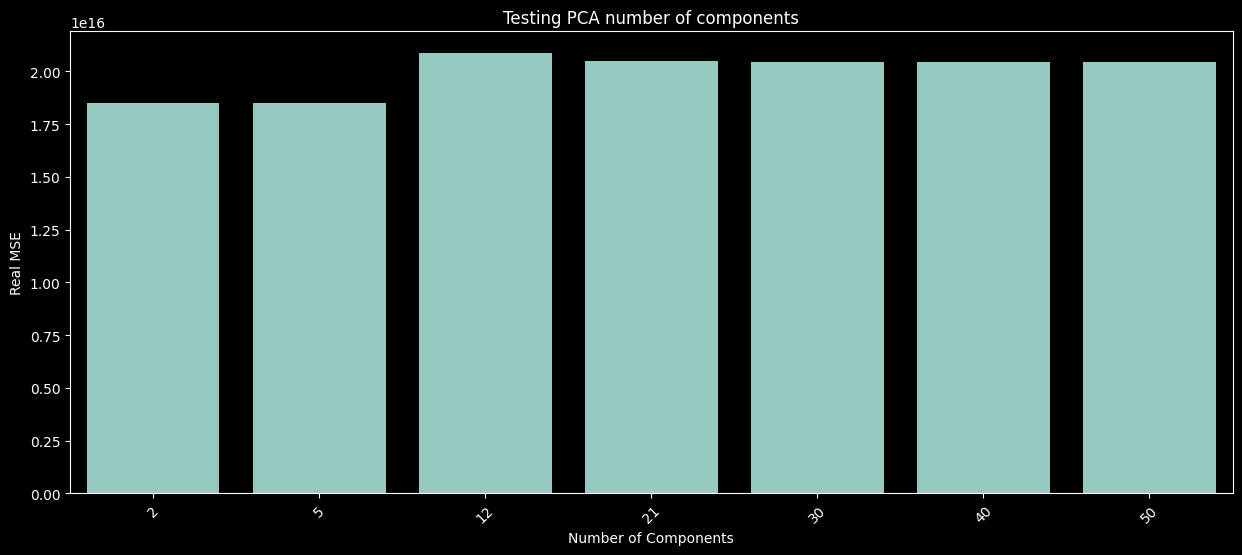

In [ ]:
n_comp_pca = [2,5,12,21,30,40,50]
mse_pca = [18506012824267600,18506012824239300,20858929796721700,20491944943263500,20440427531646900,20451090271234200,20450121015213900]

plt.figure(figsize=(15,6))
sns.barplot(x=n_comp_pca, y=mse_pca).set(title='Testing PCA number of components', xlabel='Number of Components', ylabel='Real MSE')
plt.xticks(rotation=45)
plt.show()


--> The previous grapg proves what was stated before as the MSE values there are the actual ones, applying PCA will not help to get a lower error.

## 3.4. Correlation Analysis

,index,IDOJ1,IDAIO,CIMREP,BRUTA,CONSUI,GAS,EMPAQUE,HONORA,COMISION,...,TOTREM,INVINI,INVFIN,ROTACION,INVPRO,CTO,CTOINS,GASTOS,GASTOSNOP,GASTOPNOP
index,1.000000,0.013826,0.027638,0.001799,0.028362,0.027674,0.021305,0.041857,0.024910,0.000618,...,0.031009,0.031945,-0.012358,0.027881,0.027113,0.012358,0.027920,0.012358,0.007543,0.028612
IDOJ1,0.013826,1.000000,0.171584,-0.014268,-0.053671,-0.042527,-0.013990,-0.009843,-0.036578,-0.022351,...,-0.044782,-0.009710,-0.005064,-0.036853,-0.007093,0.005064,-0.037143,0.005064,-0.043765,-0.044538
IDAIO,0.027638,0.171584,1.000000,-0.050683,-0.084828,-0.066324,-0.020558,-0.007807,-0.090188,-0.021547,...,-0.097517,-0.010421,-0.008488,-0.054996,-0.013258,0.008488,-0.054966,0.008488,-0.048319,-0.065409
CIMREP,0.001799,-0.014268,-0.050683,1.000000,0.121832,0.092158,0.029197,0.013837,0.074538,0.033680,...,0.118254,0.028373,0.001095,0.130849,0.043346,-0.001095,0.137368,-0.001095,0.029581,0.133198
BRUTA,0.028362,-0.053671,-0.084828,0.121832,1.000000,0.944259,0.522591,0.471124,0.615955,0.165291,...,0.905703,0.226538,0.002004,0.894136,0.266642,-0.002004,0.894092,-0.002004,0.263235,0.909691
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
CTO,0.012358,0.005064,0.008488,-0.001095,-0.002004,-0.001925,-0.000857,-0.001460,-0.001972,-0.000997,...,-0.002196,-0.000603,-0.000000,-0.002016,-0.000984,0.000000,-0.002029,0.000000,-0.000819,-0.002111
CTOINS,0.027920,-0.037143,-0.054966,0.137368,0.894092,0.858614,0.536109,0.430261,0.463246,0.104737,...,0.819233,0.214659,0.002029,0.999670,0.252979,-0.002029,1.000000,-0.002029,0.268354,0.986084
GASTOS,0.012358,0.005064,0.008488,-0.001095,-0.002004,-0.001925,-0.000857,-0.001460,-0.001972,-0.000997,...,-0.002196,-0.000603,-0.000000,-0.002016,-0.000984,0.000000,-0.002029,0.000000,-0.000819,-0.002111
GASTOSNOP,0.007543,-0.043765,-0.048319,0.029581,0.263235,0.194416,0.143513,0.080800,0.125886,0.019957,...,0.190530,0.060636,0.000819,0.268419,0.070242,-0.000819,0.268354,-0.000819,1.000000,0.411744


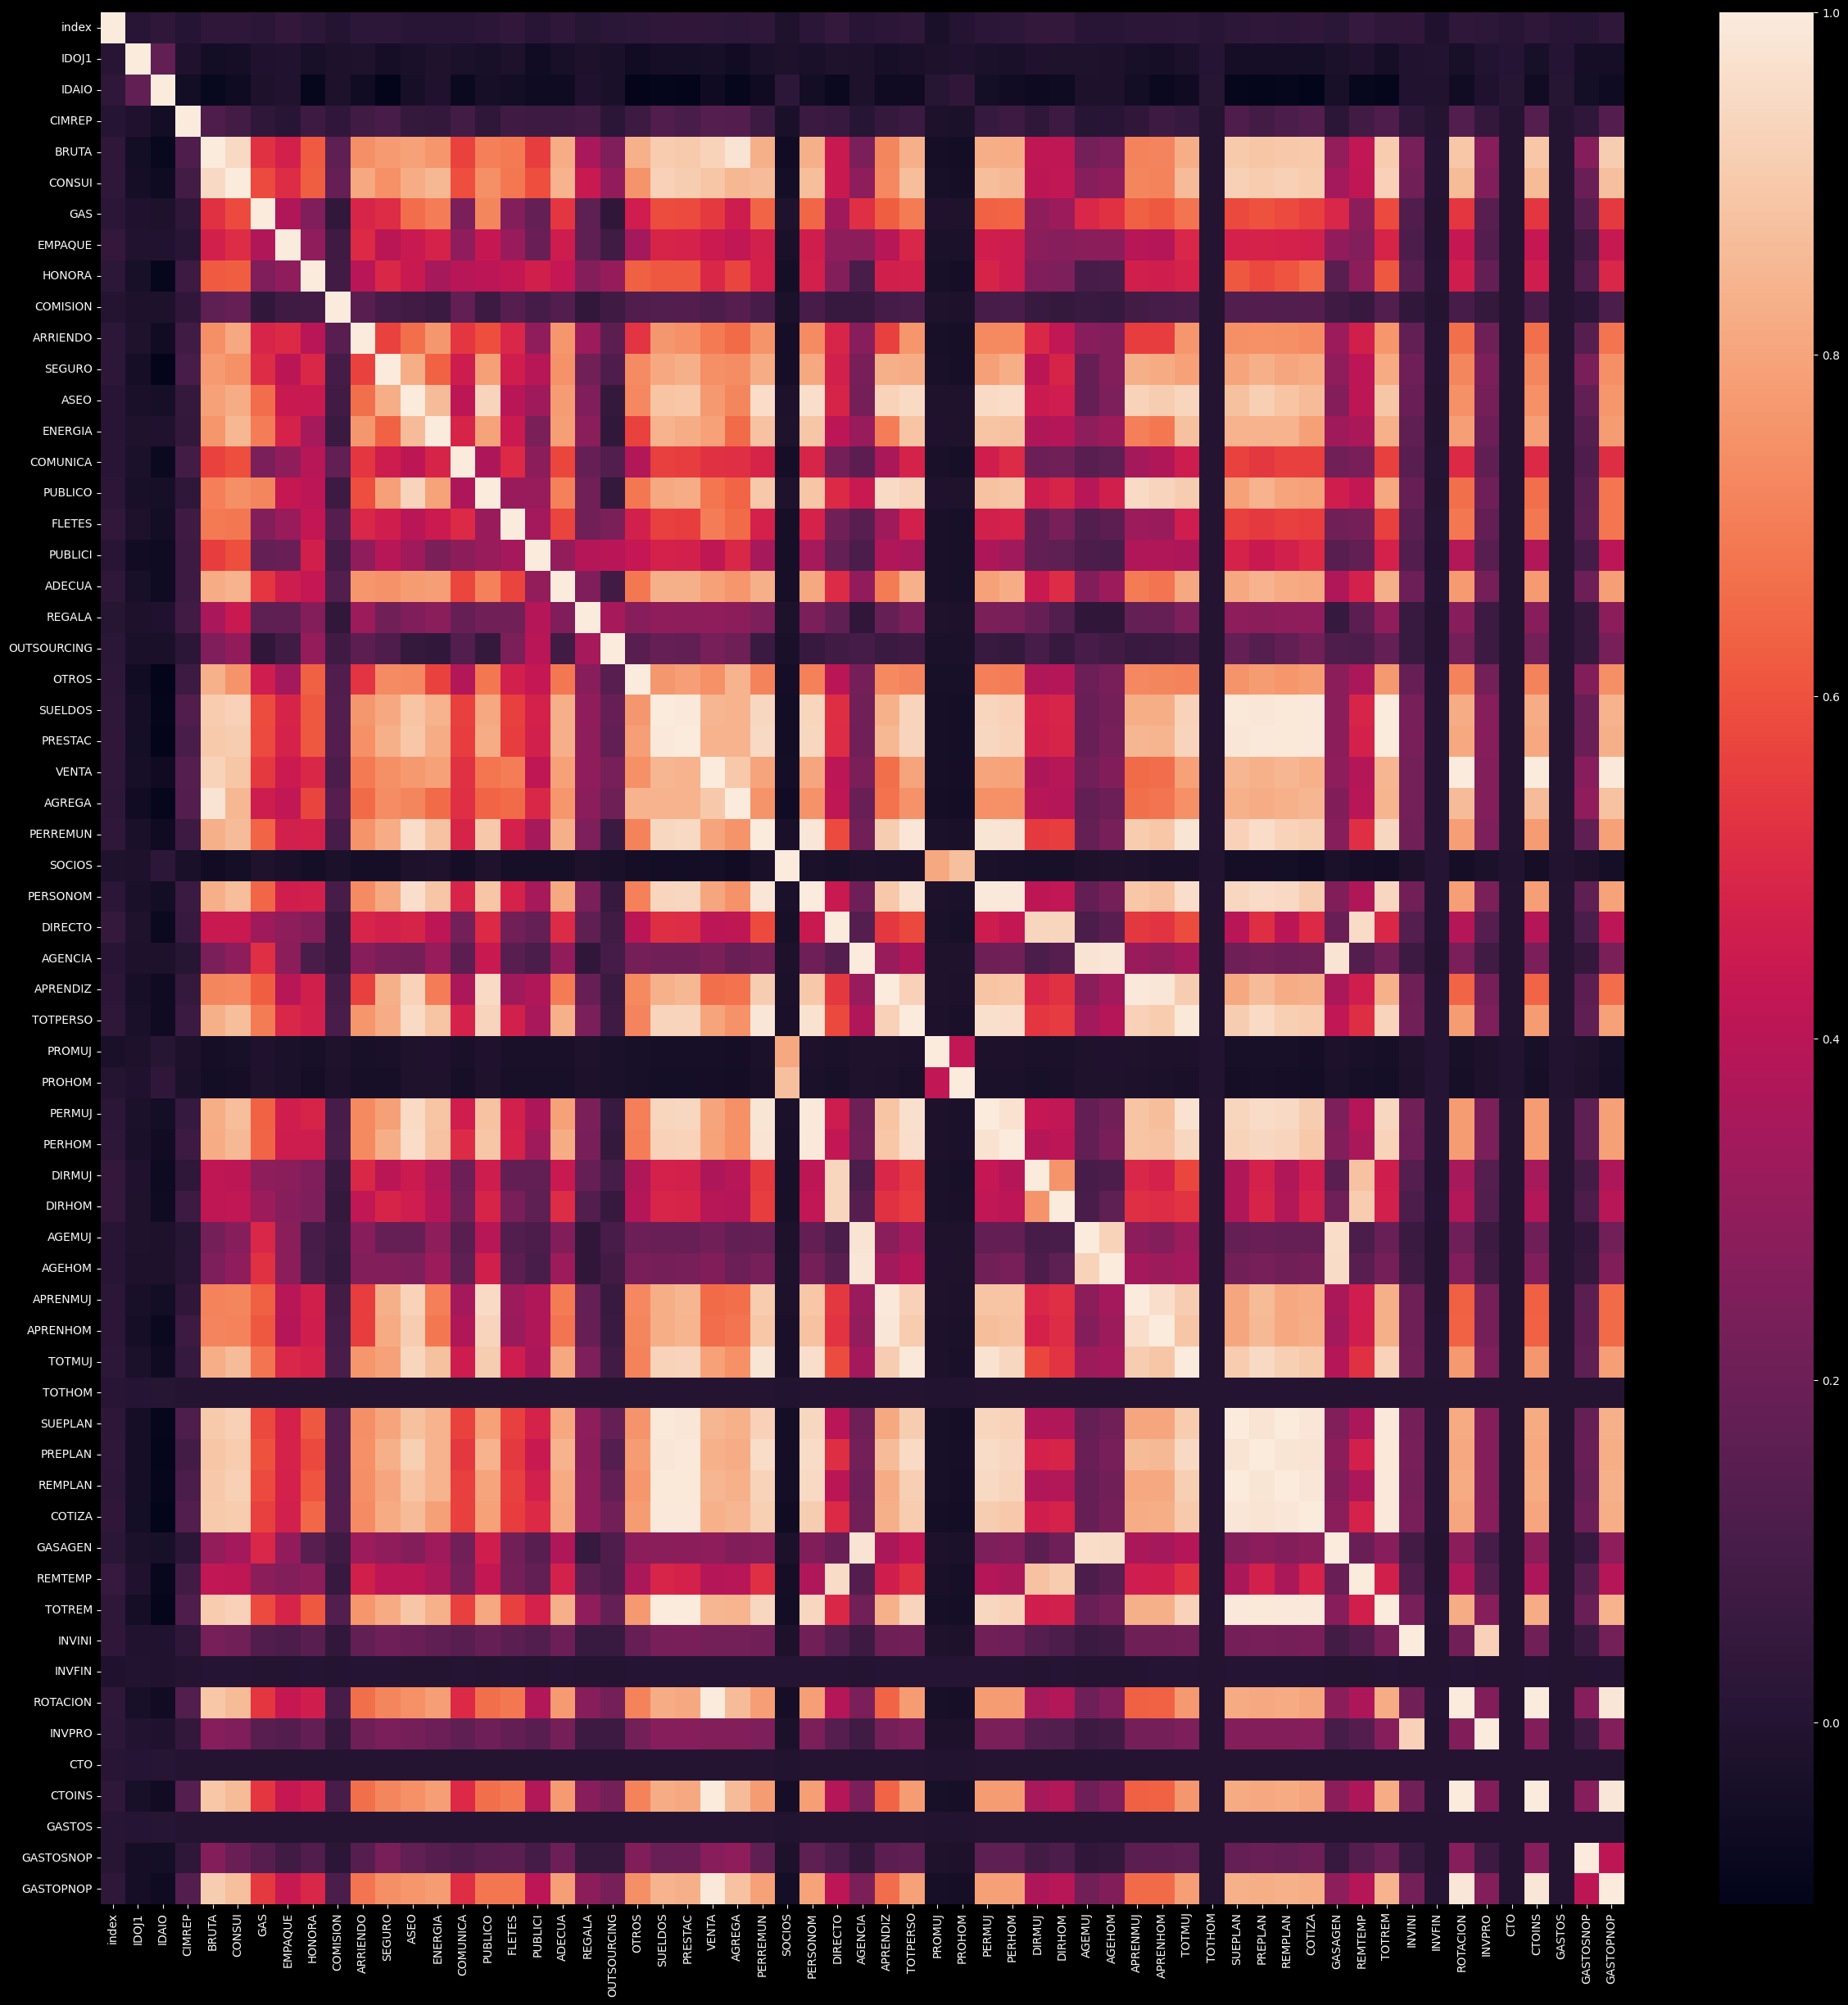

In [ ]:
corr_with_target = df_tr_nn.drop(columns=["CORRELA_16", "CORRE_9","VENTASNOP"]).corr()
display(corr_with_target)

plt.figure(figsize=(30,30))
sns.heatmap(corr_with_target)
plt.show()

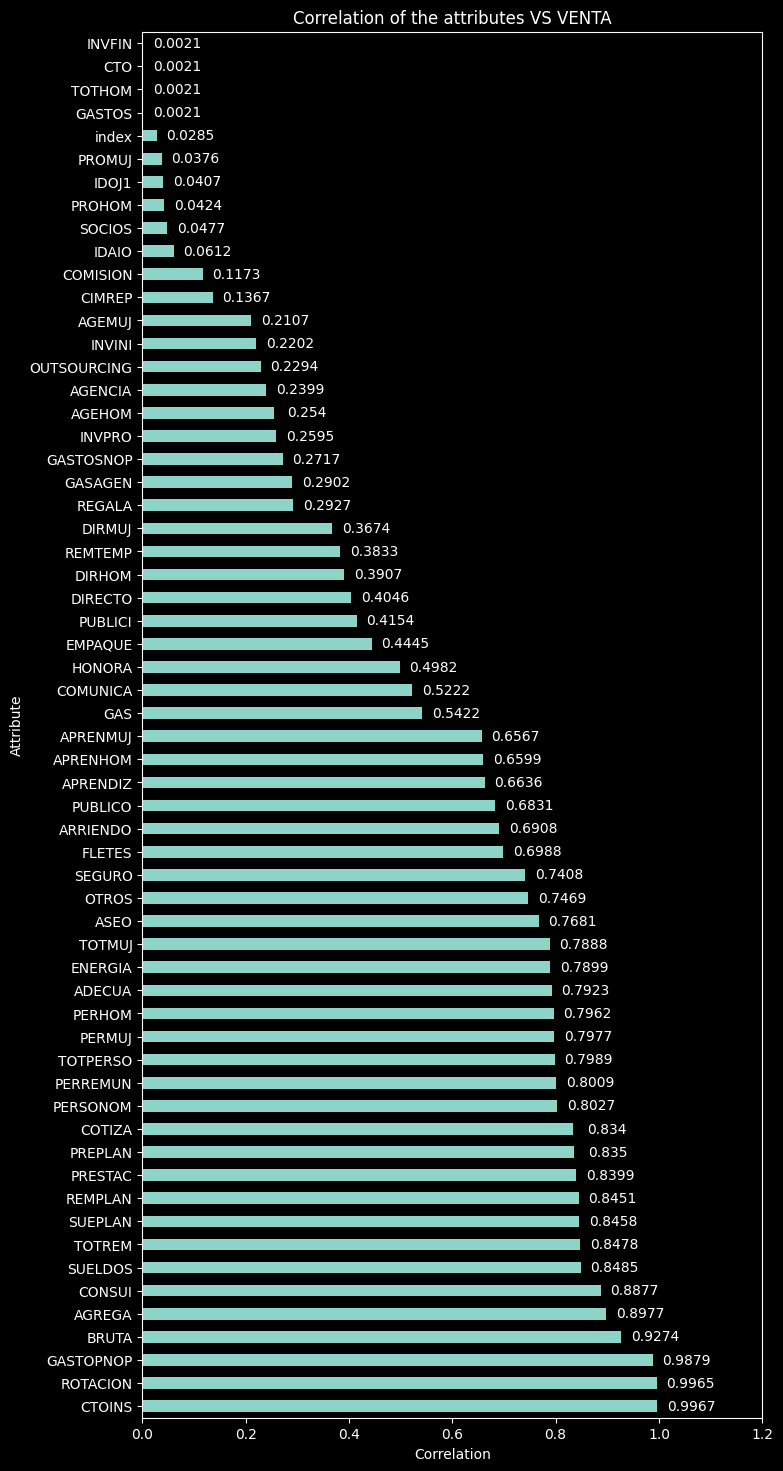

In [ ]:
correlation_with_target = df_tr_nn.drop(columns=["CORRELA_16", "CORRE_9","VENTASNOP"]).corr()['VENTA'].drop('VENTA')
correlation_with_target = correlation_with_target.abs().sort_values(ascending=False)

plt.figure(figsize=(8, 18))
corr_plot = correlation_with_target.plot(kind='barh', title='Correlation of the attributes VS VENTA', xlabel='Correlation', ylabel='Attribute')
for i in corr_plot.patches:
    if i.get_width() > 0:
        corr_plot.annotate(np.round(i.get_width(), 4), (i.get_width()+0.025, i.get_y()+i.get_height()/2), ha='center', va='center', xytext=(15, 0), textcoords='offset points')
    else:
        corr_plot.annotate(np.round(i.get_width(), 4), (i.get_width()-(0.087), i.get_y()+i.get_height()/2), ha='center', va='center', xytext=(15, 0), textcoords='offset points')
plt.xlim(0,1.2)
plt.show()

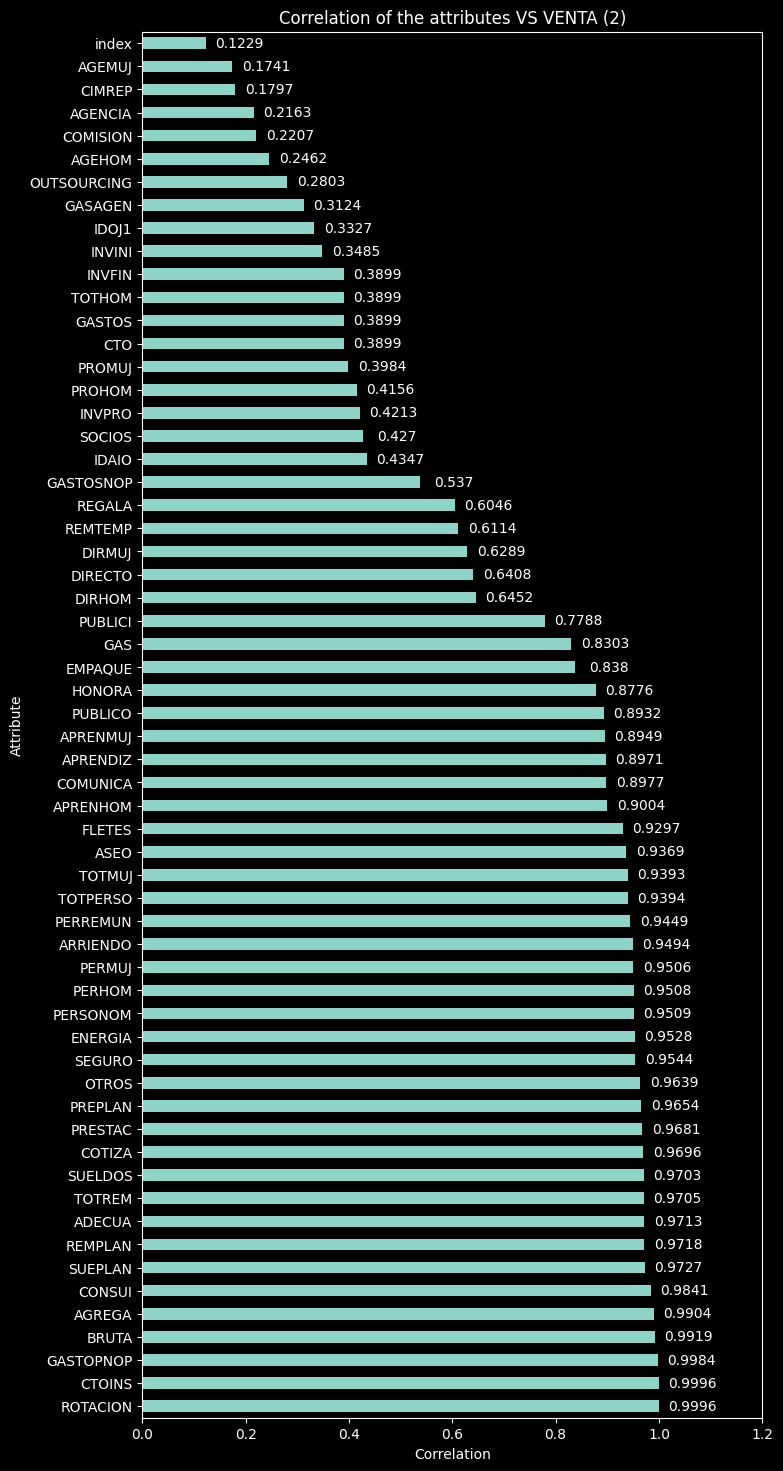

In [ ]:
correlation_with_target_2 = df_tr_nn.drop(columns=["CORRELA_16", "CORRE_9","VENTASNOP"]).corr().corr()['VENTA'].drop('VENTA')
correlation_with_target_2 = correlation_with_target_2.abs().sort_values(ascending=False)

plt.figure(figsize=(8, 18))
corr_plot = correlation_with_target_2.plot(kind='barh', title='Correlation of the attributes VS VENTA (2)', xlabel='Correlation', ylabel='Attribute')
for i in corr_plot.patches:
    if i.get_width() > 0:
        corr_plot.annotate(np.round(i.get_width(), 4), (i.get_width()+0.025, i.get_y()+i.get_height()/2), ha='center', va='center', xytext=(15, 0), textcoords='offset points')
    else:
        corr_plot.annotate(np.round(i.get_width(), 4), (i.get_width()-(0.087), i.get_y()+i.get_height()/2), ha='center', va='center', xytext=(15, 0), textcoords='offset points')
plt.xlim(0,1.2)
plt.show()

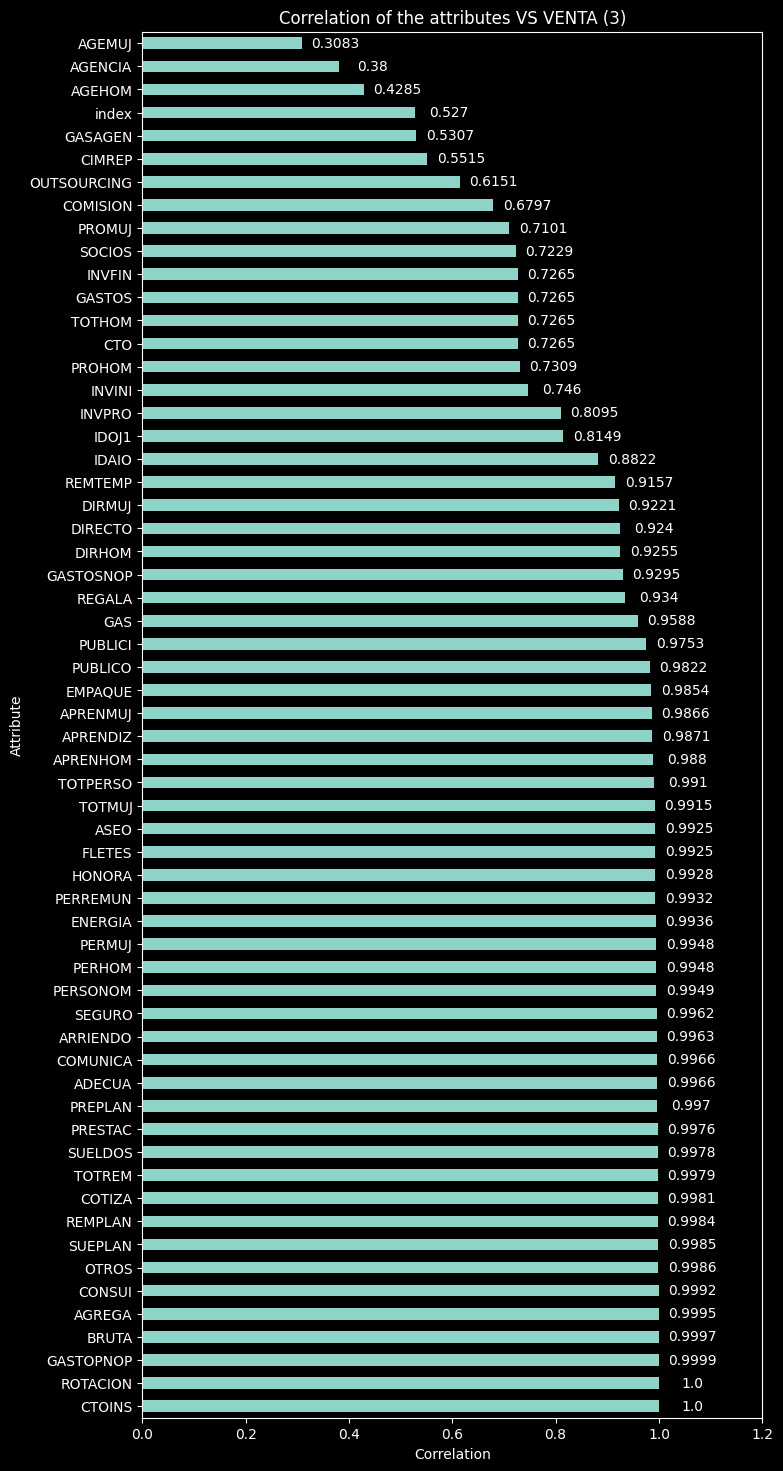

In [ ]:
correlation_with_target_3 = df_tr_nn.drop(columns=["CORRELA_16", "CORRE_9","VENTASNOP"]).corr().corr().corr()['VENTA'].drop('VENTA')
correlation_with_target_3 = correlation_with_target_3.abs().sort_values(ascending=False)

plt.figure(figsize=(8, 18))
corr_plot = correlation_with_target_3.plot(kind='barh', title='Correlation of the attributes VS VENTA (3)', xlabel='Correlation', ylabel='Attribute')
for i in corr_plot.patches:
    if i.get_width() > 0:
        corr_plot.annotate(np.round(i.get_width(), 4), (i.get_width()+0.025, i.get_y()+i.get_height()/2), ha='center', va='center', xytext=(15, 0), textcoords='offset points')
    else:
        corr_plot.annotate(np.round(i.get_width(), 4), (i.get_width()-(0.087), i.get_y()+i.get_height()/2), ha='center', va='center', xytext=(15, 0), textcoords='offset points')
plt.xlim(0,1.2)
plt.show()

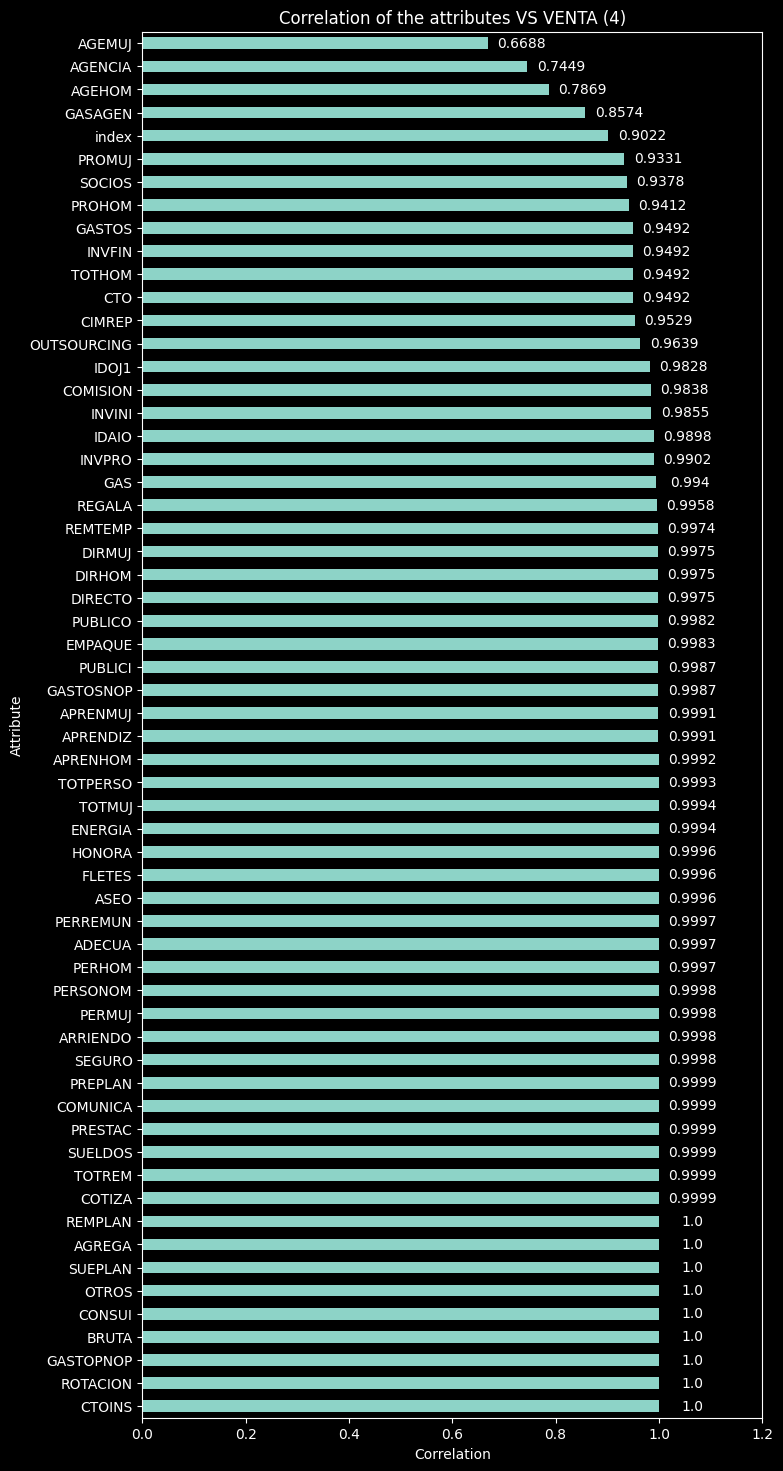

In [ ]:
correlation_with_target_4 = df_tr_nn.drop(columns=["CORRELA_16", "CORRE_9","VENTASNOP"]).corr().corr().corr().corr()['VENTA'].drop('VENTA')
correlation_with_target_4 = correlation_with_target_4.abs().sort_values(ascending=False)

plt.figure(figsize=(8, 18))
corr_plot = correlation_with_target_4.plot(kind='barh', title='Correlation of the attributes VS VENTA (4)', xlabel='Correlation', ylabel='Attribute')
for i in corr_plot.patches:
    if i.get_width() > 0:
        corr_plot.annotate(np.round(i.get_width(), 4), (i.get_width()+0.025, i.get_y()+i.get_height()/2), ha='center', va='center', xytext=(15, 0), textcoords='offset points')
    else:
        corr_plot.annotate(np.round(i.get_width(), 4), (i.get_width()-(0.087), i.get_y()+i.get_height()/2), ha='center', va='center', xytext=(15, 0), textcoords='offset points')
plt.xlim(0,1.2)
plt.show()

In [ ]:
def cols_2_erase(corr_list, min_corr):
    columns_2_erase = list()
    u = 0
    conj = corr_list.sort_values(ascending=True)

    for i in conj:
        if i < min_corr:
            columns_2_erase.append(pd.DataFrame(conj).index[u])
        u += 1

    return columns_2_erase

In [ ]:
def corr_model_test(model, corr_list, min_corr, max_corr, num, X_train, X_test, y_train, y_test):

    corrs = np.linspace(min_corr,max_corr,num)
    mses = list()

    for i in corrs:
        mdl = model

        cols_2_erase_ = cols_2_erase(corr_list,i)
        X_train_ef = np.array(pd.DataFrame(X_train, columns=df_tr_nn.drop(columns=["CORRELA_16", "CORRE_9","VENTA","VENTASNOP"]).columns).drop(columns=cols_2_erase_))
        X_test_ef = np.array(pd.DataFrame(X_test, columns=df_tr_nn.drop(columns=["CORRELA_16", "CORRE_9","VENTA","VENTASNOP"]).columns).drop(columns=cols_2_erase_))

        mdl.fit(X_train_ef,y_train)
        mdl_predict = mdl.predict(X_test_ef)
        mse = mean_squared_error(y_test, mdl_predict)

        mses.append(mse)

        mdl = 0

    plt.figure(figsize=(8,6))
    sns.barplot(x=corrs, y=mses).set(title='Error after attribute reduction', xlabel='Correlation Score with VENTA', ylabel='MSE')
    plt.xticks(rotation=45)
    plt.ylim(1e+12,1.25e+12)
    plt.show()

    corr_dict = {
        'Correlation_limit' : corrs,
        'MSEs' : mses
    }

    return pd.DataFrame(corr_dict)



In [ ]:
bst_mdl = Ridge(alpha=0.000000001, solver='lbfgs', positive=True)

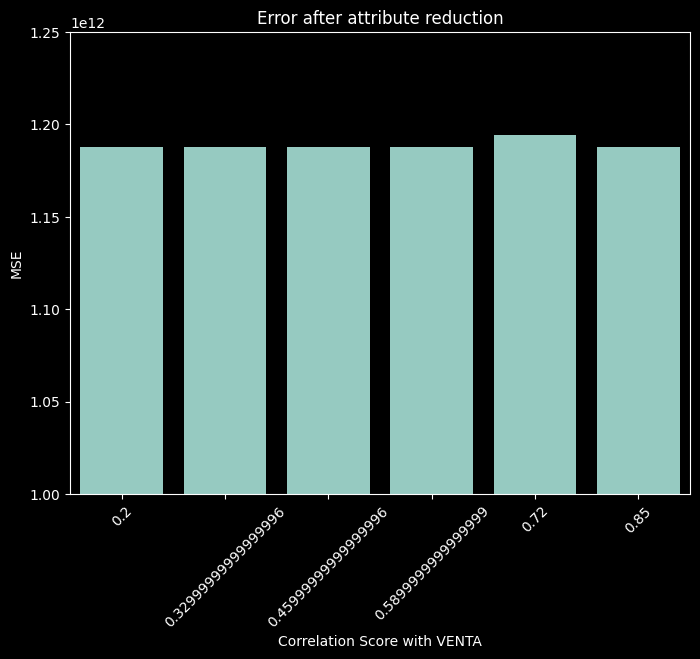

,Correlation_limit,MSEs
0,0.20,1.188007e+12
1,0.33,1.188000e+12
2,0.46,1.187966e+12
3,0.59,1.187961e+12
4,0.72,1.194098e+12
5,0.85,1.187960e+12


In [ ]:
corr_1_test = corr_model_test(
    model=bst_mdl,
    corr_list=correlation_with_target,
    min_corr=0.2,
    max_corr=0.85,
    num=6,
    X_test=X_test_1_svr,
    X_train=X_train_1_svr,
    y_train=y_train_1,
    y_test=y_test_1
    )

display(corr_1_test)

--> For what can be seen in the last chart, this method of erasing the attributes with less correlation seem to do have an impact in the scores, or at least it is not giving a higher error as the other methods did.

In [ ]:
# Sub 75 = 323380175972150
cols_1 = cols_2_erase(correlation_with_target, 0.2)

X_train_ef = np.array(pd.DataFrame(X_train_1_svr, columns=df_tr_nn.drop(columns=["CORRELA_16", "CORRE_9","VENTA","VENTASNOP"]).columns).drop(columns=cols_1))
X_test_ef = np.array(pd.DataFrame(X_test_1_svr, columns=df_tr_nn.drop(columns=["CORRELA_16", "CORRE_9","VENTA","VENTASNOP"]).columns).drop(columns=cols_1))

bst_mdl_corr_1 = Ridge(alpha=0.000000001, solver='lbfgs', positive=True)
bst_mdl_corr_1.fit(X_train_ef,y_train_1)
bst_mdl_corr_1_pred = bst_mdl_corr_1.predict(X_test_ef)
print("MSE: ",mean_squared_error(y_test_1, bst_mdl_corr_1_pred))


tester = scaler.fit_transform(df_tst_nn)
tester_corr = np.array(pd.DataFrame(tester, columns=df_tr_nn.drop(columns=["CORRELA_16", "CORRE_9","VENTA","VENTASNOP"]).columns).drop(columns=cols_1))

MSE:  1188010014768.6665


In [ ]:
# Sub 76 = 323191469364809
cols_2 = cols_2_erase(correlation_with_target, 0.33)

X_train_ef = np.array(pd.DataFrame(X_train_1_svr, columns=df_tr_nn.drop(columns=["CORRELA_16", "CORRE_9","VENTA","VENTASNOP"]).columns).drop(columns=cols_2))
X_test_ef = np.array(pd.DataFrame(X_test_1_svr, columns=df_tr_nn.drop(columns=["CORRELA_16", "CORRE_9","VENTA","VENTASNOP"]).columns).drop(columns=cols_2))

bst_mdl_corr_2 = Ridge(alpha=0.000000001, solver='lbfgs', positive=True)
bst_mdl_corr_2.fit(X_train_ef,y_train_1)
bst_mdl_corr_2_pred = bst_mdl_corr_2.predict(X_test_ef)
print("MSE: ",mean_squared_error(y_test_1, bst_mdl_corr_2_pred))


tester = scaler.fit_transform(df_tst_nn)
tester_corr = np.array(pd.DataFrame(tester, columns=df_tr_nn.drop(columns=["CORRELA_16", "CORRE_9","VENTA","VENTASNOP"]).columns).drop(columns=cols_2))

MSE:  1188000072858.3242


In [ ]:
# Sub 77 = 323750356975704
cols_3 = cols_2_erase(correlation_with_target, 0.46)

X_train_ef = np.array(pd.DataFrame(X_train_1_svr, columns=df_tr_nn.drop(columns=["CORRELA_16", "CORRE_9","VENTA","VENTASNOP"]).columns).drop(columns=cols_3))
X_test_ef = np.array(pd.DataFrame(X_test_1_svr, columns=df_tr_nn.drop(columns=["CORRELA_16", "CORRE_9","VENTA","VENTASNOP"]).columns).drop(columns=cols_3))

bst_mdl_corr_3 = Ridge(alpha=0.000000001, solver='lbfgs', positive=True)
bst_mdl_corr_3.fit(X_train_ef,y_train_1)
bst_mdl_corr_3_pred = bst_mdl_corr_3.predict(X_test_ef)
print("MSE: ",mean_squared_error(y_test_1, bst_mdl_corr_3_pred))


tester = scaler.fit_transform(df_tst_nn)
tester_corr = np.array(pd.DataFrame(tester, columns=df_tr_nn.drop(columns=["CORRELA_16", "CORRE_9","VENTA","VENTASNOP"]).columns).drop(columns=cols_3))

MSE:  1187966175727.9336


In [ ]:
# Sub 78 = 323277989830102
cols_4 = cols_2_erase(correlation_with_target, 0.59)

X_train_ef = np.array(pd.DataFrame(X_train_1_svr, columns=df_tr_nn.drop(columns=["CORRELA_16", "CORRE_9","VENTA","VENTASNOP"]).columns).drop(columns=cols_4))
X_test_ef = np.array(pd.DataFrame(X_test_1_svr, columns=df_tr_nn.drop(columns=["CORRELA_16", "CORRE_9","VENTA","VENTASNOP"]).columns).drop(columns=cols_4))

bst_mdl_corr_4 = Ridge(alpha=0.000000001, solver='lbfgs', positive=True)
bst_mdl_corr_4.fit(X_train_ef,y_train_1)
bst_mdl_corr_4_pred = bst_mdl_corr_4.predict(X_test_ef)
print("MSE: ",mean_squared_error(y_test_1, bst_mdl_corr_4_pred))


tester = scaler.fit_transform(df_tst_nn)
tester_corr = np.array(pd.DataFrame(tester, columns=df_tr_nn.drop(columns=["CORRELA_16", "CORRE_9","VENTA","VENTASNOP"]).columns).drop(columns=cols_4))

MSE:  1187961236205.51


In [ ]:
# Sub 79 = 325312658031601
cols_5 = cols_2_erase(correlation_with_target, 0.72)

X_train_ef = np.array(pd.DataFrame(X_train_1_svr, columns=df_tr_nn.drop(columns=["CORRELA_16", "CORRE_9","VENTA","VENTASNOP"]).columns).drop(columns=cols_5))
X_test_ef = np.array(pd.DataFrame(X_test_1_svr, columns=df_tr_nn.drop(columns=["CORRELA_16", "CORRE_9","VENTA","VENTASNOP"]).columns).drop(columns=cols_5))

bst_mdl_corr_5 = Ridge(alpha=0.000000001, solver='lbfgs', positive=True)
bst_mdl_corr_5.fit(X_train_ef,y_train_1)
bst_mdl_corr_5_pred = bst_mdl_corr_5.predict(X_test_ef)
print("MSE: ",mean_squared_error(y_test_1, bst_mdl_corr_5_pred))


tester = scaler.fit_transform(df_tst_nn)
tester_corr = np.array(pd.DataFrame(tester, columns=df_tr_nn.drop(columns=["CORRELA_16", "CORRE_9","VENTA","VENTASNOP"]).columns).drop(columns=cols_5))

MSE:  1194097629173.6375


In [ ]:
# Sub 80 = 325099964578238
cols_6 = cols_2_erase(correlation_with_target, 0.85)

X_train_ef = np.array(pd.DataFrame(X_train_1_svr, columns=df_tr_nn.drop(columns=["CORRELA_16", "CORRE_9","VENTA","VENTASNOP"]).columns).drop(columns=cols_6))
X_test_ef = np.array(pd.DataFrame(X_test_1_svr, columns=df_tr_nn.drop(columns=["CORRELA_16", "CORRE_9","VENTA","VENTASNOP"]).columns).drop(columns=cols_6))

bst_mdl_corr_6 = Ridge(alpha=0.000000001, solver='lbfgs', positive=True)
bst_mdl_corr_6.fit(X_train_ef,y_train_1)
bst_mdl_corr_6_pred = bst_mdl_corr_6.predict(X_test_ef)
print("MSE: ",mean_squared_error(y_test_1, bst_mdl_corr_6_pred))


tester = scaler.fit_transform(df_tst_nn)
tester_corr = np.array(pd.DataFrame(tester, columns=df_tr_nn.drop(columns=["CORRELA_16", "CORRE_9","VENTA","VENTASNOP"]).columns).drop(columns=cols_6))

MSE:  1187960083734.996


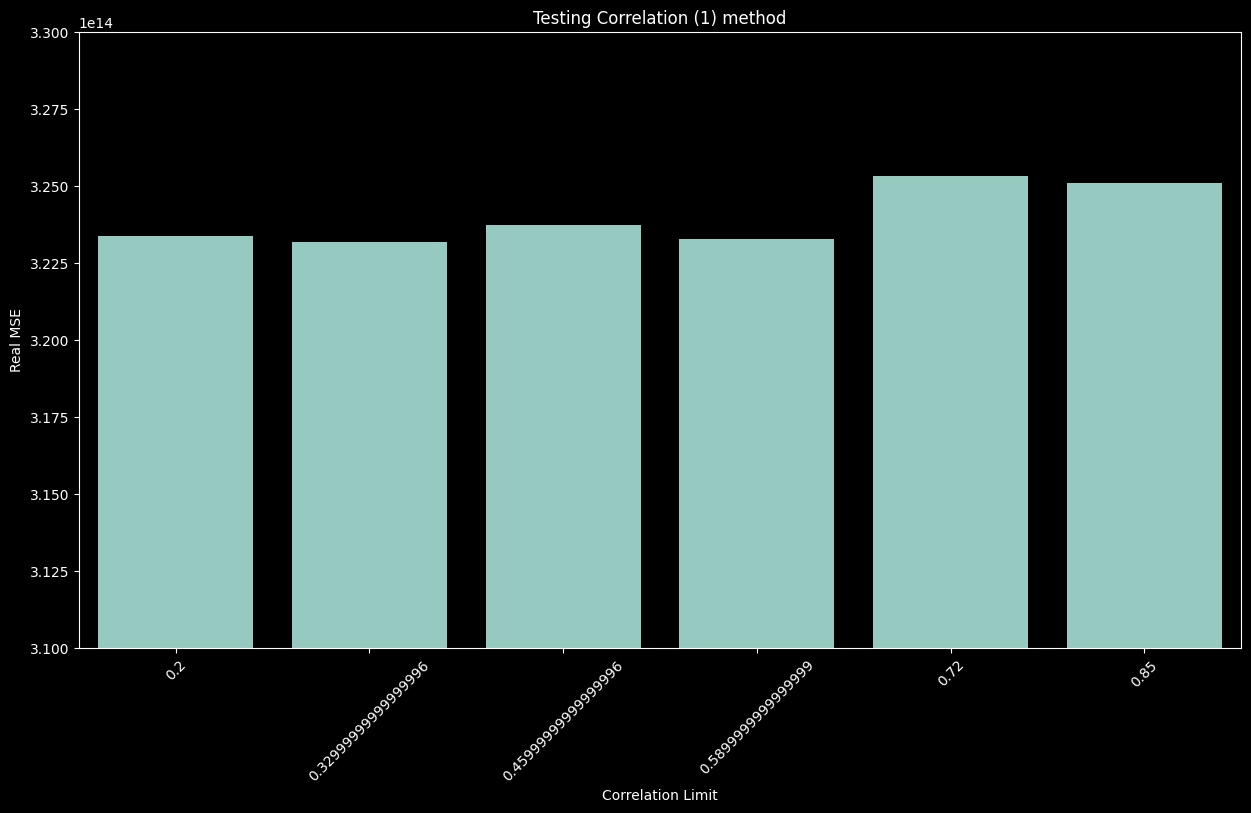

323191469364809


In [ ]:
real_corr_mse_1 = [323380175972150,323191469364809,323750356975704,323277989830102,325312658031601,325099964578238]

plt.figure(figsize=(15,8))
sns.barplot(x=corr_1_test['Correlation_limit'], y=real_corr_mse_1).set(title='Testing Correlation (1) method', xlabel='Correlation Limit', ylabel='Real MSE')
plt.xticks(rotation=45)
plt.ylim(3.1e+14,3.3e+14)
plt.show()
print(min(real_corr_mse_1))


--> For what can be seen in the last graph, eventhough deleting some attributes might not have such a high impact in the error, the scores still do not beat the best one gotten.

In [ ]:
# Sub 81 = 309803310662199
cols_7 = cols_2_erase(correlation_with_target_2, 0.2)

X_train_ef = np.array(pd.DataFrame(X_train_1_svr, columns=df_tr_nn.drop(columns=["CORRELA_16", "CORRE_9","VENTA","VENTASNOP"]).columns).drop(columns=cols_7))
X_test_ef = np.array(pd.DataFrame(X_test_1_svr, columns=df_tr_nn.drop(columns=["CORRELA_16", "CORRE_9","VENTA","VENTASNOP"]).columns).drop(columns=cols_7))

bst_mdl_corr_7 = Ridge(alpha=0.000000001, solver='lbfgs', positive=True)
bst_mdl_corr_7.fit(X_train_ef,y_train_1)
bst_mdl_corr_7_pred = bst_mdl_corr_7.predict(X_test_ef)
print("MSE: ",mean_squared_error(y_test_1, bst_mdl_corr_7_pred))


tester = scaler.fit_transform(df_tst_nn)
tester_corr = np.array(pd.DataFrame(tester, columns=df_tr_nn.drop(columns=["CORRELA_16", "CORRE_9","VENTA","VENTASNOP"]).columns).drop(columns=cols_7))

MSE:  1188014594622.8188


In [ ]:
# Sub 82 = 266936036645534
cols_8 = cols_2_erase(correlation_with_target_2, 0.33)

X_train_ef = np.array(pd.DataFrame(X_train_1_svr, columns=df_tr_nn.drop(columns=["CORRELA_16", "CORRE_9","VENTA","VENTASNOP"]).columns).drop(columns=cols_8))
X_test_ef = np.array(pd.DataFrame(X_test_1_svr, columns=df_tr_nn.drop(columns=["CORRELA_16", "CORRE_9","VENTA","VENTASNOP"]).columns).drop(columns=cols_8))

bst_mdl_corr_8 = Ridge(alpha=0.000000001, solver='lbfgs', positive=True)
bst_mdl_corr_8.fit(X_train_ef,y_train_1)
bst_mdl_corr_8_pred = bst_mdl_corr_8.predict(X_test_ef)
print("MSE: ",mean_squared_error(y_test_1, bst_mdl_corr_8_pred))


tester = scaler.fit_transform(df_tst_nn)
tester_corr = np.array(pd.DataFrame(tester, columns=df_tr_nn.drop(columns=["CORRELA_16", "CORRE_9","VENTA","VENTASNOP"]).columns).drop(columns=cols_8))

MSE:  1187996919752.0286


--> With this attempt the best score was finally beaten.

In [ ]:
# Sub 83 = 323565570090387
cols_9 = cols_2_erase(correlation_with_target_2, 0.46)

X_train_ef = np.array(pd.DataFrame(X_train_1_svr, columns=df_tr_nn.drop(columns=["CORRELA_16", "CORRE_9","VENTA","VENTASNOP"]).columns).drop(columns=cols_9))
X_test_ef = np.array(pd.DataFrame(X_test_1_svr, columns=df_tr_nn.drop(columns=["CORRELA_16", "CORRE_9","VENTA","VENTASNOP"]).columns).drop(columns=cols_9))

bst_mdl_corr_9 = Ridge(alpha=0.000000001, solver='lbfgs', positive=True)
bst_mdl_corr_9.fit(X_train_ef,y_train_1)
bst_mdl_corr_9_pred = bst_mdl_corr_9.predict(X_test_ef)
print("MSE: ",mean_squared_error(y_test_1, bst_mdl_corr_9_pred))


tester = scaler.fit_transform(df_tst_nn)
tester_corr = np.array(pd.DataFrame(tester, columns=df_tr_nn.drop(columns=["CORRELA_16", "CORRE_9","VENTA","VENTASNOP"]).columns).drop(columns=cols_9))

MSE:  1188004037875.1538


In [ ]:
# Sub 84 = 323767223864168
cols_10 = cols_2_erase(correlation_with_target_2, 0.59)

X_train_ef = np.array(pd.DataFrame(X_train_1_svr, columns=df_tr_nn.drop(columns=["CORRELA_16", "CORRE_9","VENTA","VENTASNOP"]).columns).drop(columns=cols_10))
X_test_ef = np.array(pd.DataFrame(X_test_1_svr, columns=df_tr_nn.drop(columns=["CORRELA_16", "CORRE_9","VENTA","VENTASNOP"]).columns).drop(columns=cols_10))

bst_mdl_corr_10 = Ridge(alpha=0.000000001, solver='lbfgs', positive=True)
bst_mdl_corr_10.fit(X_train_ef,y_train_1)
bst_mdl_corr_10_pred = bst_mdl_corr_10.predict(X_test_ef)
print("MSE: ",mean_squared_error(y_test_1, bst_mdl_corr_10_pred))


tester = scaler.fit_transform(df_tst_nn)
tester_corr = np.array(pd.DataFrame(tester, columns=df_tr_nn.drop(columns=["CORRELA_16", "CORRE_9","VENTA","VENTASNOP"]).columns).drop(columns=cols_10))

MSE:  1187955118253.9639


In [ ]:
# Sub 85 = 323039108925104
cols_11 = cols_2_erase(correlation_with_target_2, 0.72)

X_train_ef = np.array(pd.DataFrame(X_train_1_svr, columns=df_tr_nn.drop(columns=["CORRELA_16", "CORRE_9","VENTA","VENTASNOP"]).columns).drop(columns=cols_11))
X_test_ef = np.array(pd.DataFrame(X_test_1_svr, columns=df_tr_nn.drop(columns=["CORRELA_16", "CORRE_9","VENTA","VENTASNOP"]).columns).drop(columns=cols_11))

bst_mdl_corr_11 = Ridge(alpha=0.000000001, solver='lbfgs', positive=True)
bst_mdl_corr_11.fit(X_train_ef,y_train_1)
bst_mdl_corr_11_pred = bst_mdl_corr_11.predict(X_test_ef)
print("MSE: ",mean_squared_error(y_test_1, bst_mdl_corr_11_pred))


tester = scaler.fit_transform(df_tst_nn)
tester_corr = np.array(pd.DataFrame(tester, columns=df_tr_nn.drop(columns=["CORRELA_16", "CORRE_9","VENTA","VENTASNOP"]).columns).drop(columns=cols_11))

MSE:  1290643376319.698


In [ ]:
# Sub 86 = 323673596309984
cols_12 = cols_2_erase(correlation_with_target_2, 0.85)

X_train_ef = np.array(pd.DataFrame(X_train_1_svr, columns=df_tr_nn.drop(columns=["CORRELA_16", "CORRE_9","VENTA","VENTASNOP"]).columns).drop(columns=cols_12))
X_test_ef = np.array(pd.DataFrame(X_test_1_svr, columns=df_tr_nn.drop(columns=["CORRELA_16", "CORRE_9","VENTA","VENTASNOP"]).columns).drop(columns=cols_12))

bst_mdl_corr_12 = Ridge(alpha=0.000000001, solver='lbfgs', positive=True)
bst_mdl_corr_12.fit(X_train_ef,y_train_1)
bst_mdl_corr_12_pred = bst_mdl_corr_12.predict(X_test_ef)
print("MSE: ",mean_squared_error(y_test_1, bst_mdl_corr_12_pred))


tester = scaler.fit_transform(df_tst_nn)
tester_corr = np.array(pd.DataFrame(tester, columns=df_tr_nn.drop(columns=["CORRELA_16", "CORRE_9","VENTA","VENTASNOP"]).columns).drop(columns=cols_12))

MSE:  1187983783184.564


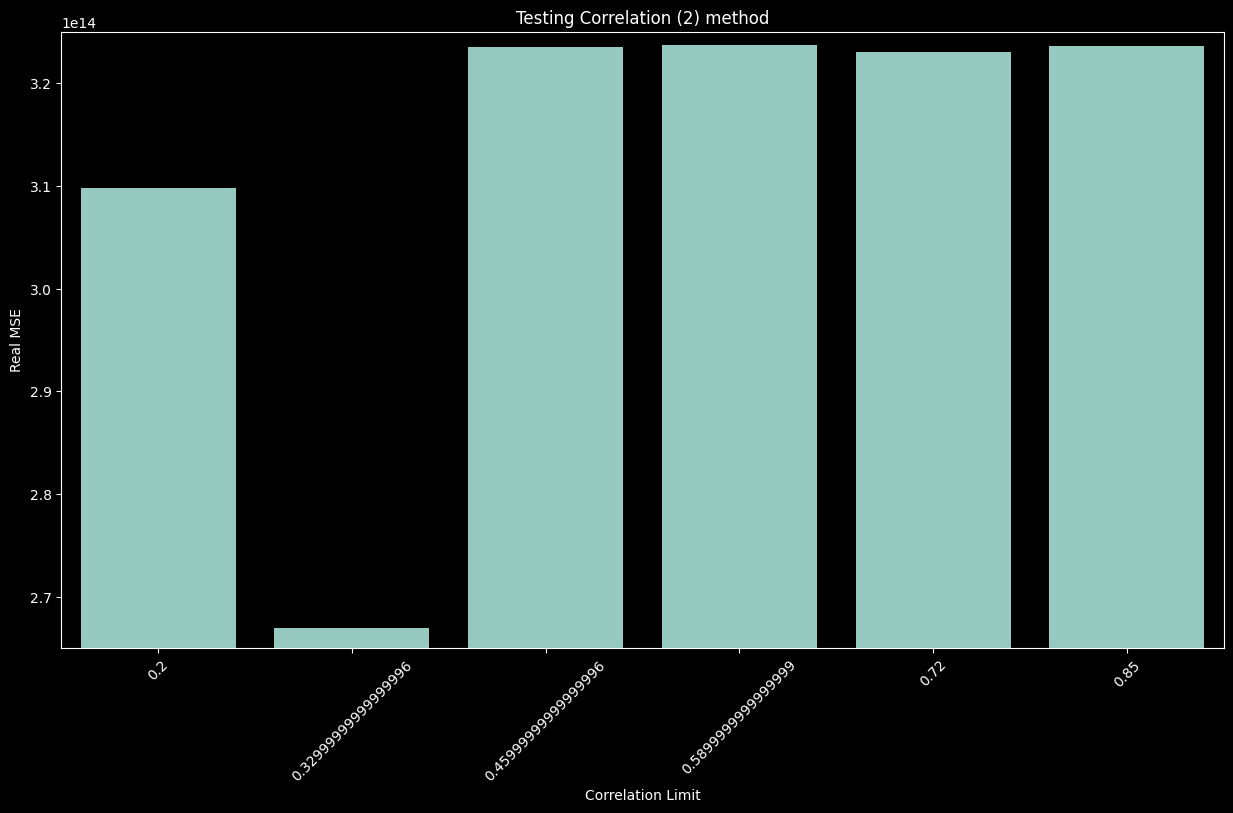

323191469364809


In [ ]:
real_corr_mse_2 = [309803310662199,266936036645534,323565570090387,323767223864168,323039108925104,323673596309984]

plt.figure(figsize=(15,8))
sns.barplot(x=corr_1_test['Correlation_limit'], y=real_corr_mse_2).set(title='Testing Correlation (2) method', xlabel='Correlation Limit', ylabel='Real MSE')
plt.xticks(rotation=45)
plt.ylim(2.65e+14,3.25e+14)
plt.show()
print(min(real_corr_mse_1))


For the tests of the third correlation set, as the values start in 0.3083, some new correlation values will be taken into account. The criterion for this new selection will be made according with a visual analysis of the 'Correlation of the attributes VS VENTA (3)' graph.

In [ ]:
corr_values_3 = [0.5,0.67,0.7,0.8,0.88,0.95]

In [ ]:
# Sub 87 = 262813531657241
cols_13 = cols_2_erase(correlation_with_target_3, corr_values_3[0])

X_train_ef = np.array(pd.DataFrame(X_train_1_svr, columns=df_tr_nn.drop(columns=["CORRELA_16", "CORRE_9","VENTA","VENTASNOP"]).columns).drop(columns=cols_13))
X_test_ef = np.array(pd.DataFrame(X_test_1_svr, columns=df_tr_nn.drop(columns=["CORRELA_16", "CORRE_9","VENTA","VENTASNOP"]).columns).drop(columns=cols_13))

bst_mdl_corr_13 = Ridge(alpha=0.000000001, solver='lbfgs', positive=True)
bst_mdl_corr_13.fit(X_train_ef,y_train_1)
bst_mdl_corr_13_pred = bst_mdl_corr_13.predict(X_test_ef)
print("MSE: ",mean_squared_error(y_test_1, bst_mdl_corr_13_pred))


tester = scaler.fit_transform(df_tst_nn)
tester_corr = np.array(pd.DataFrame(tester, columns=df_tr_nn.drop(columns=["CORRELA_16", "CORRE_9","VENTA","VENTASNOP"]).columns).drop(columns=cols_13))

MSE:  1187987430702.4622


--> Once again, testing with a new correlation setting bettered the score of the model.

In [ ]:
# Sub 88 = 290309549095375
cols_14 = cols_2_erase(correlation_with_target_3, corr_values_3[1])

X_train_ef = np.array(pd.DataFrame(X_train_1_svr, columns=df_tr_nn.drop(columns=["CORRELA_16", "CORRE_9","VENTA","VENTASNOP"]).columns).drop(columns=cols_14))
X_test_ef = np.array(pd.DataFrame(X_test_1_svr, columns=df_tr_nn.drop(columns=["CORRELA_16", "CORRE_9","VENTA","VENTASNOP"]).columns).drop(columns=cols_14))

bst_mdl_corr_14 = Ridge(alpha=0.000000001, solver='lbfgs', positive=True)
bst_mdl_corr_14.fit(X_train_ef,y_train_1)
bst_mdl_corr_14_pred = bst_mdl_corr_14.predict(X_test_ef)
print("MSE: ",mean_squared_error(y_test_1, bst_mdl_corr_14_pred))


tester = scaler.fit_transform(df_tst_nn)
tester_corr = np.array(pd.DataFrame(tester, columns=df_tr_nn.drop(columns=["CORRELA_16", "CORRE_9","VENTA","VENTASNOP"]).columns).drop(columns=cols_14))

MSE:  3993641832524.569


In [ ]:
# Sub 89 = 266936036645534
cols_15 = cols_2_erase(correlation_with_target_3, corr_values_3[2])

X_train_ef = np.array(pd.DataFrame(X_train_1_svr, columns=df_tr_nn.drop(columns=["CORRELA_16", "CORRE_9","VENTA","VENTASNOP"]).columns).drop(columns=cols_15))
X_test_ef = np.array(pd.DataFrame(X_test_1_svr, columns=df_tr_nn.drop(columns=["CORRELA_16", "CORRE_9","VENTA","VENTASNOP"]).columns).drop(columns=cols_15))

bst_mdl_corr_15 = Ridge(alpha=0.000000001, solver='lbfgs', positive=True)
bst_mdl_corr_15.fit(X_train_ef,y_train_1)
bst_mdl_corr_15_pred = bst_mdl_corr_15.predict(X_test_ef)
print("MSE: ",mean_squared_error(y_test_1, bst_mdl_corr_15_pred))


tester = scaler.fit_transform(df_tst_nn)
tester_corr = np.array(pd.DataFrame(tester, columns=df_tr_nn.drop(columns=["CORRELA_16", "CORRE_9","VENTA","VENTASNOP"]).columns).drop(columns=cols_15))

MSE:  1187996919752.0286


--> This score is the same that was obtained with the best combination in the last correlation setting.

In [ ]:
# Sub 90 = 323447827956985
cols_16 = cols_2_erase(correlation_with_target_3, corr_values_3[3])

X_train_ef = np.array(pd.DataFrame(X_train_1_svr, columns=df_tr_nn.drop(columns=["CORRELA_16", "CORRE_9","VENTA","VENTASNOP"]).columns).drop(columns=cols_16))
X_test_ef = np.array(pd.DataFrame(X_test_1_svr, columns=df_tr_nn.drop(columns=["CORRELA_16", "CORRE_9","VENTA","VENTASNOP"]).columns).drop(columns=cols_16))

bst_mdl_corr_16 = Ridge(alpha=0.000000001, solver='lbfgs', positive=True)
bst_mdl_corr_16.fit(X_train_ef,y_train_1)
bst_mdl_corr_16_pred = bst_mdl_corr_16.predict(X_test_ef)
print("MSE: ",mean_squared_error(y_test_1, bst_mdl_corr_16_pred))


tester = scaler.fit_transform(df_tst_nn)
tester_corr = np.array(pd.DataFrame(tester, columns=df_tr_nn.drop(columns=["CORRELA_16", "CORRE_9","VENTA","VENTASNOP"]).columns).drop(columns=cols_16))

MSE:  1188006646106.4827


In [ ]:
# Sub 91 = 322079269076713
cols_17 = cols_2_erase(correlation_with_target_3, corr_values_3[4])

X_train_ef = np.array(pd.DataFrame(X_train_1_svr, columns=df_tr_nn.drop(columns=["CORRELA_16", "CORRE_9","VENTA","VENTASNOP"]).columns).drop(columns=cols_17))
X_test_ef = np.array(pd.DataFrame(X_test_1_svr, columns=df_tr_nn.drop(columns=["CORRELA_16", "CORRE_9","VENTA","VENTASNOP"]).columns).drop(columns=cols_17))

bst_mdl_corr_17 = Ridge(alpha=0.000000001, solver='lbfgs', positive=True)
bst_mdl_corr_17.fit(X_train_ef,y_train_1)
bst_mdl_corr_17_pred = bst_mdl_corr_17.predict(X_test_ef)
print("MSE: ",mean_squared_error(y_test_1, bst_mdl_corr_17_pred))


tester = scaler.fit_transform(df_tst_nn)
tester_corr = np.array(pd.DataFrame(tester, columns=df_tr_nn.drop(columns=["CORRELA_16", "CORRE_9","VENTA","VENTASNOP"]).columns).drop(columns=cols_17))

MSE:  1187980953947.4912


In [ ]:
# Sub 92 = 323039108925104
cols_18 = cols_2_erase(correlation_with_target_3, corr_values_3[5])

X_train_ef = np.array(pd.DataFrame(X_train_1_svr, columns=df_tr_nn.drop(columns=["CORRELA_16", "CORRE_9","VENTA","VENTASNOP"]).columns).drop(columns=cols_18))
X_test_ef = np.array(pd.DataFrame(X_test_1_svr, columns=df_tr_nn.drop(columns=["CORRELA_16", "CORRE_9","VENTA","VENTASNOP"]).columns).drop(columns=cols_18))

bst_mdl_corr_18 = Ridge(alpha=0.000000001, solver='lbfgs', positive=True)
bst_mdl_corr_18.fit(X_train_ef,y_train_1)
bst_mdl_corr_18_pred = bst_mdl_corr_18.predict(X_test_ef)
print("MSE: ",mean_squared_error(y_test_1, bst_mdl_corr_18_pred))


tester = scaler.fit_transform(df_tst_nn)
tester_corr = np.array(pd.DataFrame(tester, columns=df_tr_nn.drop(columns=["CORRELA_16", "CORRE_9","VENTA","VENTASNOP"]).columns).drop(columns=cols_18))

MSE:  1290643376319.698


Since the error seems to just getting higher, the next tests will be made just in the firsts correlation values of the list, the closest of the new best score.

In [ ]:
# Sub 93 = 212094945670057
cols_19 = cols_2_erase(correlation_with_target_3, 0.4)

X_train_ef = np.array(pd.DataFrame(X_train_1_svr, columns=df_tr_nn.drop(columns=["CORRELA_16", "CORRE_9","VENTA","VENTASNOP"]).columns).drop(columns=cols_19))
X_test_ef = np.array(pd.DataFrame(X_test_1_svr, columns=df_tr_nn.drop(columns=["CORRELA_16", "CORRE_9","VENTA","VENTASNOP"]).columns).drop(columns=cols_19))

bst_mdl_corr_19 = Ridge(alpha=0.000000001, solver='lbfgs', positive=True)
bst_mdl_corr_19.fit(X_train_ef,y_train_1)
bst_mdl_corr_19_pred = bst_mdl_corr_19.predict(X_test_ef)
print("MSE: ",mean_squared_error(y_test_1, bst_mdl_corr_19_pred))


tester = scaler.fit_transform(df_tst_nn)
tester_corr = np.array(pd.DataFrame(tester, columns=df_tr_nn.drop(columns=["CORRELA_16", "CORRE_9","VENTA","VENTASNOP"]).columns).drop(columns=cols_19))

MSE:  1187982334898.4622


In [ ]:
# Sub 93 = 212094945670057
cols_222 = cols_2_erase(correlation_with_target_3, 0.4)

X_train_ef = np.array(pd.DataFrame(X_train_1_svr, columns=df_tr_nn.drop(columns=["CORRELA_16", "CORRE_9","VENTA","VENTASNOP"]).columns).drop(columns=cols_222+['index']))
X_test_ef = np.array(pd.DataFrame(X_test_1_svr, columns=df_tr_nn.drop(columns=["CORRELA_16", "CORRE_9","VENTA","VENTASNOP"]).columns).drop(columns=cols_222+['index']))

bst_mdl_corr_22 = Ridge(alpha=0.000000001, solver='lbfgs', positive=True)
bst_mdl_corr_22.fit(X_train_ef,y_train_1)
bst_mdl_corr_22_pred = bst_mdl_corr_22.predict(X_test_ef)
print("MSE: ",mean_squared_error(y_test_1, bst_mdl_corr_22_pred))


tester = scaler.fit_transform(df_tst_nn)
tester_corr = np.array(pd.DataFrame(tester, columns=df_tr_nn.drop(columns=["CORRELA_16", "CORRE_9","VENTA","VENTASNOP"]).columns).drop(columns=cols_222+['index']))

MSE:  2865602788090.813


--> There is a new best score.

In [ ]:
# Sub 94 = 328839539196864
cols_20 = cols_2_erase(correlation_with_target_3, 0.35)

X_train_ef = np.array(pd.DataFrame(X_train_1_svr, columns=df_tr_nn.drop(columns=["CORRELA_16", "CORRE_9","VENTA","VENTASNOP"]).columns).drop(columns=cols_20))
X_test_ef = np.array(pd.DataFrame(X_test_1_svr, columns=df_tr_nn.drop(columns=["CORRELA_16", "CORRE_9","VENTA","VENTASNOP"]).columns).drop(columns=cols_20))

bst_mdl_corr_20 = Ridge(alpha=0.000000001, solver='lbfgs', positive=True)
bst_mdl_corr_20.fit(X_train_ef,y_train_1)
bst_mdl_corr_20_pred = bst_mdl_corr_20.predict(X_test_ef)
print("MSE: ",mean_squared_error(y_test_1, bst_mdl_corr_20_pred))


tester = scaler.fit_transform(df_tst_nn)
tester_corr = np.array(pd.DataFrame(tester, columns=df_tr_nn.drop(columns=["CORRELA_16", "CORRE_9","VENTA","VENTASNOP"]).columns).drop(columns=cols_20))

MSE:  3899510711465.1357


In [ ]:
corr_values_3_2 = [0.35,0.4] + corr_values_3
corr_values_3_2

[0.35, 0.4, 0.5, 0.67, 0.7, 0.8, 0.88, 0.95]

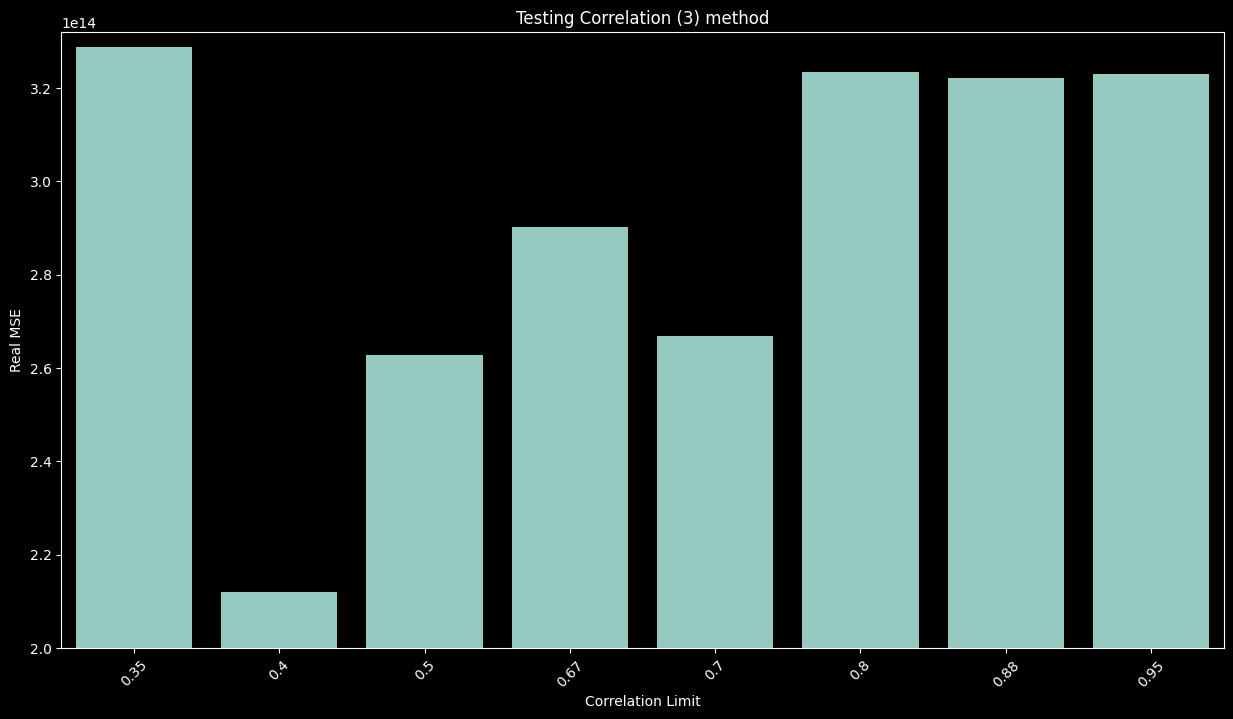

212094945670057


In [ ]:
real_corr_mse_2 = [328839539196864,212094945670057,262813531657241,290309549095375,266936036645534,323447827956985,322079269076713,323039108925104]

plt.figure(figsize=(15,8))
sns.barplot(x=corr_values_3_2, y=real_corr_mse_2).set(title='Testing Correlation (3) method', xlabel='Correlation Limit', ylabel='Real MSE')
plt.xticks(rotation=45)
plt.ylim(2e+14,3.32e+14)
plt.show()
print(min(real_corr_mse_2))


In [ ]:
cols_19

['AGEMUJ', 'AGENCIA']

**Accoridng with the previous analysis, there are two main ways to get the best MSE score possible (212094945670057):**
* **Using a Ridge model with the following parameters:** alpha=0.000000001, solver='lbfgs', positive=True
* **Erasing the following attributes:** 'AGEMUJ', 'AGENCIA'

In [ ]:
tester = scaler.fit_transform(df_tst_nn)

prediction = bst_mdl_corr_22.predict(tester_corr)
predictions = {
    'index' : df_tst['index'],
    'VENTA' : prediction
}
df_predictions = pd.DataFrame(predictions)
solution = df_predictions.to_csv('Attempts\solution_22.csv', index=False)